In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# =========================================================
# ENSANUT 2023 - SOLO: CSVs + CATÁLOGOS + MAP (código→etiqueta)
# - Lee todos los CSV por componente
# - Lee catálogos (Variables/Valores) aunque no empiecen en A1
# - Construye maps: { variable -> { codigo: etiqueta } }
# - NO aplica mapeos ni construye matrices
# =========================================================

import re
import pandas as pd
from pathlib import Path
from openpyxl import load_workbook

# ---------- CONFIG ----------
BASE_DIR = Path("/content/drive/MyDrive/POSTDOCTORADO C3/ENSANUT/2023/ensanut_2023_ALL")
COMPONENTES = ["nutricion", "salud"]  # ajusta si quieres
CSV_SUBDIR = "csv"
CAT_SUBDIR = "catalogos"

# ---------- Utilidad: detectar fila de encabezados ----------
def find_header_row(ws, expected_headers, search_rows=200, search_cols=30, min_hits=2):
    """
    Escanea las primeras 'search_rows' x 'search_cols' celdas
    y retorna el número de fila (1-indexado) donde aparezcan al menos 'min_hits'
    encabezados esperados (texto coincidente exacto).
    """
    for r, row in enumerate(ws.iter_rows(min_row=1, max_row=search_rows, max_col=search_cols), start=1):
        vals = [str(c.value).strip() if c.value is not None else "" for c in row]
        hits = sum(1 for h in expected_headers if h in vals)
        if hits >= min_hits:
            return r
    return None

# ---------- Lectura robusta de catálogo ----------
def read_catalogo(path_xlsx):
    """
    Devuelve:
      - df_variables  (hoja 'Variables' o la primera)
      - df_valores    (hoja 'Valores' si existe, ya normalizada)
      - maps          dict { variable -> {codigo: etiqueta} }
      - has_valores   bool
    """
    wb = load_workbook(path_xlsx, read_only=True, data_only=True)
    names = wb.sheetnames

    # ---- Variables ----
    sheet_vars = "Variables" if "Variables" in names else names[0]
    ws_vars = wb[sheet_vars]
    hdr_vars = find_header_row(
        ws_vars,
        expected_headers=["Variable", "Posición", "Posicion", "Etiqueta", "Nivel", "Ancho"],
        min_hits=2
    )
    if hdr_vars is None:
        raise ValueError(f"No se halló encabezado en hoja '{sheet_vars}' de {path_xlsx}")

    df_variables = pd.read_excel(
        path_xlsx, sheet_name=sheet_vars, engine="openpyxl",
        header=0, skiprows=hdr_vars-1
    )

    # Normalizar nombres de columnas
    renv = {}
    for c in df_variables.columns:
        cl = str(c).strip().lower()
        if cl == "variable":                renv[c] = "variable"
        elif cl in ("posición","posicion"): renv[c] = "posicion"
        elif "tiqueta" in cl:               renv[c] = "etiqueta"
        elif "nivel" in cl:                 renv[c] = "nivel"
        elif "ancho" in cl or "width" in cl:renv[c] = "ancho"
    if renv:
        df_variables = df_variables.rename(columns=renv)

    if "variable" in df_variables.columns:
        df_variables["variable"] = df_variables["variable"].astype(str).str.strip()

    # ---- Valores (opcional) ----
    has_valores = "Valores" in names
    df_valores = pd.DataFrame(columns=["variable","codigo","etiqueta"])
    maps = {}

    if has_valores:
        ws_vals = wb["Valores"]
        hdr_vals = find_header_row(
            ws_vals,
            expected_headers=["Variable","Valor","Código","Codigo","Etiqueta","Descripción","Descripcion","Label"],
            min_hits=2
        )
        if hdr_vals is not None:
            raw_vals = pd.read_excel(
                path_xlsx, sheet_name="Valores", engine="openpyxl",
                header=0, skiprows=hdr_vals-1
            )

            # Normalizar columnas típicas a: variable / codigo / etiqueta
            ren = {}
            for c in raw_vals.columns:
                cl = str(c).strip().lower()
                if cl in ("variable", "valor"):                            ren[c] = "variable"
                elif cl in ("código","codigo","code","valor","unnamed: 1"): ren[c] = "codigo"
                elif ("tiqueta" in cl) or ("label" in cl) or ("descrip" in cl):
                    ren[c] = "etiqueta"

            keep = [k for k in ["variable","codigo","etiqueta"] if k in set(ren.values())]
            if keep:
                df_valores = raw_vals.rename(columns=ren)[keep].copy()

                # Limpiar types
                if "variable" in df_valores:
                    df_valores["variable"] = df_valores["variable"].ffill().astype(str).str.strip()
                if "codigo" in df_valores:
                    # Mantener como string para preservar ceros a la izquierda y consistencia
                    df_valores["codigo"] = df_valores["codigo"].astype(str).str.strip()
                if "etiqueta" in df_valores:
                    df_valores["etiqueta"] = df_valores["etiqueta"].astype(str).str.strip()

                # Construir maps: última ocurrencia gana (evita duplicados desordenados)
                for var, sub in df_valores.groupby("variable", dropna=False):
                    kv = {}
                    for _, r in sub.iterrows():
                        cod = r.get("codigo")
                        lab = r.get("etiqueta")
                        if cod is not None and lab is not None:
                            kv[cod] = lab
                    if kv:
                        maps[var] = kv

    return df_variables, df_valores, maps, has_valores

# ---------- Carga por componente: CSV + CATÁLOGOS + MAP ----------
def cargar_componentes_min(BASE_DIR: Path, componentes, csv_subdir="csv", cat_subdir="catalogos"):
    """
    Retorna un dict:
      dfs = {
        componente: {
          "csv": { nombre_tabla: DataFrame, ... },
          "catalogos": { nombre_catalogo: {"variables": df_vars, "valores": df_vals}, ... },
          "maps": { variable: {codigo: etiqueta}, ... }
        }, ...
      }
    """
    dfs = {c: {"csv": {}, "catalogos": {}, "maps": {}} for c in componentes}

    for comp in componentes:
        comp_dir = BASE_DIR / comp
        print(f"\n===== COMPONENTE: {comp.upper()} =====")
        print(f"Base: {comp_dir}")

        # --- CSVs ---
        csv_dir = comp_dir / csv_subdir
        print(f"CSV dir: {csv_dir} {'(existe)' if csv_dir.exists() else '(NO existe)'}")
        if csv_dir.exists():
            for f in sorted(csv_dir.glob("*.csv")):
                try:
                    df = pd.read_csv(f, sep=None, engine="python", encoding="utf-8-sig")
                    dfs[comp]["csv"][f.stem] = df
                    print(f"  ✅ CSV: {f.name} → {df.shape[0]}×{df.shape[1]}")
                except Exception as e:
                    print(f"  ⚠️  CSV fallo {f.name}: {e}")

        # --- Catálogos ---
        cat_dir = comp_dir / cat_subdir
        print(f"CAT dir: {cat_dir} {'(existe)' if cat_dir.exists() else '(NO existe)'}")
        if cat_dir.exists():
            for f in sorted(cat_dir.glob("*.xlsx")):
                try:
                    dv, dval, m, has_vals = read_catalogo(f)
                    dfs[comp]["catalogos"][f.stem] = {"variables": dv, "valores": dval}
                    # fusionar maps por variable (si hay múltiples archivos)
                    for var, kv in m.items():
                        dfs[comp]["maps"].setdefault(var, {}).update(kv)
                    print(f"  📘 CAT: {f.name} | maps añadidos: {len(m)} | valores: {'sí' if has_vals else 'no'}")
                except Exception as e:
                    print(f"  ⚠️  CAT fallo {f.name}: {e}")

        print(f"Resumen {comp}: {len(dfs[comp]['csv'])} CSV | {len(dfs[comp]['catalogos'])} catálogos | {len(dfs[comp]['maps'])} variables con map")

    return dfs

# ---------- EJECUCIÓN MÍNIMA ----------
dfs = cargar_componentes_min(BASE_DIR, COMPONENTES, csv_subdir=CSV_SUBDIR, cat_subdir=CAT_SUBDIR)

# Ejemplos de acceso:
# - Un DataFrame CSV:
#   dfs["nutricion"]["csv"]["rec24h_w"].head()
# - Catálogo (Variables):
#   dfs["salud"]["catalogos"]["adultos_ensanut2023_w_n"]["variables"].head()
# - MAP (código→etiqueta) para una variable:
#   dfs["salud"]["maps"]["resultado_1"]   # dict { '1': 'Completa', '2': 'Incompleta', ... } (ejemplo)


===== COMPONENTE: NUTRICION =====
Base: /content/drive/MyDrive/POSTDOCTORADO C3/ENSANUT/2023/ensanut_2023_ALL/nutricion
CSV dir: /content/drive/MyDrive/POSTDOCTORADO C3/ENSANUT/2023/ensanut_2023_ALL/nutricion/csv (existe)
  ✅ CSV: Antropometria_HTA_4mar24.csv → 3509×97
  ✅ CSV: actividad_fisica_w_adultos.csv → 3977×125
  ✅ CSV: actividad_fisica_w_niños.csv → 568×125
  ✅ CSV: etiquetado_w.csv → 4282×130
  ✅ CSV: frec_ad_rec_w.csv → 311488×20
  ✅ CSV: frec_ad_sup_w.csv → 5952×21
  ✅ CSV: frec_ad_tor_w.csv → 7936×16
  ✅ CSV: frec_adul_w.csv → 1984×54
  ✅ CSV: frec_es_rec_w.csv → 128112×20
  ✅ CSV: frec_es_sup_w.csv → 2448×21
  ✅ CSV: frec_es_tor_w.csv → 3264×16
  ✅ CSV: frec_es_w.csv → 816×52
  ✅ CSV: frec_pr_rec_w.csv → 87848×20
  ✅ CSV: frec_pr_sup_w.csv → 1668×21
  ✅ CSV: frec_pr_tor_w.csv → 2224×16
  ✅ CSV: frec_pr_w.csv → 556×52
  ✅ CSV: lactancia_w.csv → 544×224
  ✅ CSV: plomo_w.csv → 688×91
  ✅ CSV: rec24h_alim_w.csv → 20662×35
  ✅ CSV: rec24h_desc_w.csv → 26714×42
  ✅ CSV: rec24

In [14]:
import re
import numpy as np
import pandas as pd

# --- Diccionario de mapeo esp_alim -> tipo de leche ---
otras_leches_dict = {
    443: "Leche en polvo entera",
    445: "Leche evaporada entera",
    447: "Leche semidescremada",
    452: "Fórmula láctea para bebés de soya",
    1110: "Leche sin lactosa descremada",
    1192: "Leche de soya",
    7000: "Leche entera",
    7001: "Leche descremada",
    7002: "Leche en polvo descremada",
    7003: "Leche evaporada descremada",
    7047: "Atole de maíz con leche entera",
    7048: "Atole de maíz con fórmula láctea para bebés en polvo",
    7049: "Atole de maíz con leche bronca",
    7050: "Atole de maíz con leche light",
    7051: "Atole de maíz con leche en polvo descremada",
    7052: "Atole de maíz con leche entera en polvo",
    7054: "Atole de maíz con leche evaporada entera",
    7055: "Atole de maíz con leche semidescremada",
    7056: "Atole de maíz con leche sin lactosa",
    7057: "Atole de maíz con leche sin lactosa entera",
    7102: "Leche sin lactosa entera",
    7103: "Leche bronca",
    7133: "Atole de maíz con leche evaporada descremada"
}


In [15]:
import pandas as pd

df_total = pd.concat([
    dfs['nutricion']['csv']['frec_es_rec_w'],
    dfs['nutricion']['csv']['frec_pr_rec_w'],
    dfs['nutricion']['csv']['frec_ad_rec_w'],], axis=0)
df_total

,FOLIO_INT,FOLIO_I,entidad,desc_ent,municipio,desc_mun,id_alim,alimento,por_est,pa1,esp_alim,pa2,pa3,pa4,maquina1,ponde_f,estrato,est_sel,upm,x_region
0,2023_01001003_06,2023_01001003,1,01 AGUASCALIENTES,1,001 AGUASCALIENTES,1,Leche Liconsa,1 vaso (240 ml),7,,2,ES,1.00,MQ650,"78918,4780768386",3,1000,0100100013312,1
1,2023_01001003_06,2023_01001003,1,01 AGUASCALIENTES,1,001 AGUASCALIENTES,2,Otra Leche A,1 vaso (240 ml),0,,,,,MQ650,"78918,4780768386",3,1000,0100100013312,1
2,2023_01001003_06,2023_01001003,1,01 AGUASCALIENTES,1,001 AGUASCALIENTES,3,Otra Leche B,1 vaso (240 ml),0,,,,,MQ650,"78918,4780768386",3,1000,0100100013312,1
3,2023_01001003_06,2023_01001003,1,01 AGUASCALIENTES,1,001 AGUASCALIENTES,4,Otra Leche C,1 vaso (240 ml),0,,,,,MQ650,"78918,4780768386",3,1000,0100100013312,1
4,2023_01001003_06,2023_01001003,1,01 AGUASCALIENTES,1,001 AGUASCALIENTES,5,Leche preparada de sabor (chocolate u otro sabor),1 vaso (240 ml),0,,,,,MQ650,"78918,4780768386",3,1000,0100100013312,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311483,2023_32024028_01,2023_32024028,32,32 ZACATECAS,24,024 LORETO,153,Manteca animal (cerdo o pollo),1 cucharada sopera (10g),0,,,,,MQ663,"136518,077199171",2,32000,3202400010322,1
311484,2023_32024028_01,2023_32024028,32,32 ZACATECAS,24,024 LORETO,154,Sal o condimento con sal agregada a sus alimentos,"(sal de mesa, sal con ajo, sal con cebolla)",0,,,,,MQ663,"136518,077199171",2,32000,3202400010322,1
311485,2023_32024028_01,2023_32024028,32,32 ZACATECAS,24,024 LORETO,155,Salsas y aderezos agregados a sus alimentos: a...,,0,,,,,MQ663,"136518,077199171",2,32000,3202400010322,1
311486,2023_32024028_01,2023_32024028,32,32 ZACATECAS,24,024 LORETO,156,Salsas y aderezos agregados a sus alimentos: b...,,0,,,,,MQ663,"136518,077199171",2,32000,3202400010322,1


In [16]:
import re
import numpy as np
import pandas as pd
from typing import Dict

def aplicar_transformacion_leches(
    df: pd.DataFrame,
    otras_leches_dict: Dict[int, str],
    *,
    col_alimento: str = "alimento",
    col_por_est: str = "por_est",
    col_esp_alim: str = "esp_alim"
) -> None:
    """
    Modifica EN SITIO el DataFrame:
      - Normaliza 'Otra leche opción A/B/C' usando el mapeo de 'esp_alim'.
      - Reemplaza '(especificar tipo de leche)' en 'por_est' con el mapeo.
      - Elimina filas donde se requiere tipo de leche y no hay mapeo.
      - Crea la columna 'descripcion'.
    """
    esp_int = pd.to_numeric(df[col_esp_alim], errors="coerce").astype("Int64")
    tipo_map = esp_int.map(otras_leches_dict)

    pat_otra = re.compile(r"^\s*otra\s+leche\s+opci[oó]n\s+[abc]\s*$", flags=re.IGNORECASE)
    placeholder_pat = r"\(\s*especificar\s+tipo\s+de\s+leche\s*\)"

    es_otra = df[col_alimento].astype(str).str.match(pat_otra, na=False)
    tiene_placeholder = df[col_por_est].astype(str).str.contains(
        placeholder_pat, case=False, regex=True, na=False
    )
    necesita_mapeo = es_otra | tiene_placeholder

    sin_mapeo = necesita_mapeo & tipo_map.isna()
    if sin_mapeo.any():
        df.drop(index=df.index[sin_mapeo], inplace=True)
        esp_int = pd.to_numeric(df[col_esp_alim], errors="coerce").astype("Int64")
        tipo_map = esp_int.map(otras_leches_dict)
        es_otra = df[col_alimento].astype(str).str.match(pat_otra, na=False)

    alimento_norm = df[col_alimento].where(~es_otra, other=tipo_map.astype(str))

    def _resolver(por, tl):
        if pd.isna(por):
            return np.nan
        s = str(por)
        if re.search(placeholder_pat, s, flags=re.IGNORECASE):
            return re.sub(placeholder_pat, f"({tl})", s, flags=re.IGNORECASE)
        return s

    por_est_res = [
        _resolver(p, tl) for p, tl in zip(df[col_por_est].tolist(), tipo_map.tolist())
    ]
    por_est_res = pd.Series(por_est_res, index=df.index)

    df["descripcion"] = np.where(
        por_est_res.notna(),
        alimento_norm.astype(str).str.strip() + " - " + por_est_res.astype(str).str.strip(),
        alimento_norm.astype(str).str.strip()
    )

# === Wrapper que NO muta el df original y devuelve solo las columnas de interés ===
def aplicar_transformacion_y_retornar(
    df: pd.DataFrame,
    otras_leches_dict: Dict[int, str]
) -> pd.DataFrame:
    df_copia = df.copy()  # no tocar el original
    aplicar_transformacion_leches(df_copia, otras_leches_dict)  # modifica la copia
    cols_interes = [
        'FOLIO_INT','FOLIO_I','alimento','por_est','esp_alim',
        'pa1','pa2','pa3','pa4','descripcion'
    ]
    return df_copia[cols_interes].copy()

# Uso (devuelve un DF nuevo con solo tus variables):
nuevo_df = aplicar_transformacion_y_retornar(
    df_total,
    otras_leches_dict)
nuevo_df

,FOLIO_INT,FOLIO_I,alimento,por_est,esp_alim,pa1,pa2,pa3,pa4,descripcion
0,2023_01001003_06,2023_01001003,Leche Liconsa,1 vaso (240 ml),,7,2,ES,1.00,Leche Liconsa - 1 vaso (240 ml)
1,2023_01001003_06,2023_01001003,Otra Leche A,1 vaso (240 ml),,0,,,,Otra Leche A - 1 vaso (240 ml)
5,2023_01001003_06,2023_01001003,Agreagado a la leche: Azúcar,1 cucharada cafetera copeteada (10g),,0,,,,Agreagado a la leche: Azúcar - 1 cucharada caf...
6,2023_01001003_06,2023_01001003,Agreagado a la leche: Chocolate u otro saboriz...,1 cucharada cafetera copeteada (10g),,0,,,,Agreagado a la leche: Chocolate u otro saboriz...
7,2023_01001003_06,2023_01001003,Queso panela o fresco o cottage,1 rebanada o 2 cucharadas soperas (30 g),,2,1,ES,2.00,Queso panela o fresco o cottage - 1 rebanada o...
...,...,...,...,...,...,...,...,...,...,...
311483,2023_32024028_01,2023_32024028,Manteca animal (cerdo o pollo),1 cucharada sopera (10g),,0,,,,Manteca animal (cerdo o pollo) - 1 cucharada s...
311484,2023_32024028_01,2023_32024028,Sal o condimento con sal agregada a sus alimentos,"(sal de mesa, sal con ajo, sal con cebolla)",,0,,,,Sal o condimento con sal agregada a sus alimen...
311485,2023_32024028_01,2023_32024028,Salsas y aderezos agregados a sus alimentos: a...,,,0,,,,Salsas y aderezos agregados a sus alimentos: a...
311486,2023_32024028_01,2023_32024028,Salsas y aderezos agregados a sus alimentos: b...,,,0,,,,Salsas y aderezos agregados a sus alimentos: b...


In [17]:
nuevo_df[['FOLIO_INT','FOLIO_I','descripcion','pa1','pa2','pa3','pa4']]

,FOLIO_INT,FOLIO_I,descripcion,pa1,pa2,pa3,pa4
0,2023_01001003_06,2023_01001003,Leche Liconsa - 1 vaso (240 ml),7,2,ES,1.00
1,2023_01001003_06,2023_01001003,Otra Leche A - 1 vaso (240 ml),0,,,
5,2023_01001003_06,2023_01001003,Agreagado a la leche: Azúcar - 1 cucharada caf...,0,,,
6,2023_01001003_06,2023_01001003,Agreagado a la leche: Chocolate u otro saboriz...,0,,,
7,2023_01001003_06,2023_01001003,Queso panela o fresco o cottage - 1 rebanada o...,2,1,ES,2.00
...,...,...,...,...,...,...,...
311483,2023_32024028_01,2023_32024028,Manteca animal (cerdo o pollo) - 1 cucharada s...,0,,,
311484,2023_32024028_01,2023_32024028,Sal o condimento con sal agregada a sus alimen...,0,,,
311485,2023_32024028_01,2023_32024028,Salsas y aderezos agregados a sus alimentos: a...,0,,,
311486,2023_32024028_01,2023_32024028,Salsas y aderezos agregados a sus alimentos: b...,0,,,


In [18]:
import re
import unicodedata
import pandas as pd

# ---------- Utilidades ----------
def _normalize(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip().lower()
    # quitar acentos
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    return s

def _compile_patterns(pattern_seq):
    """
    Acepta lista de (categoria, patron) o dict (se respeta el orden de insercion).
    Devuelve lista de (categoria, regex compilado).
    """
    iterable = pattern_seq.items() if isinstance(pattern_seq, dict) else pattern_seq
    return [(cat, re.compile(pat, flags=re.IGNORECASE)) for cat, pat in iterable]

# ---------- OVERRIDES de altísima prioridad ----------
# Fuerzan coincidencias específicas ANTES de evaluar los patrones generales.
OVERRIDES = [

    # acepta: "b) atole con leche", "atole de maiz ... atole con leche", etc.
("Productos de maíz", r"(?:^[\s\S]*?)\b(?:[abc]\)\s*)?atole\s+con\s+leche\b"),

# --- Leguminosas usadas como BOTANA -> Botanas/Dulces/Postres ---
    ("Botanas/Dulces/Postres",
    r"^\s*(?:habas?|garbanzos?|lentejas?)"
    r"(?:\s+(?:tostad(?:as?)?|hornead(?:as?)?|enchilad(?:as?)?|frit(?:as?)?))?"
    r"(?:\s*(?:,|y|/|o)\s*(?:habas?|garbanzos?|lentejas?))*"
    r"(?:\s+(?:como\s+)?)?(?:botan(?:a|as)|snacks?|colacion(?:es)?)\b.*"),


                # --- Forzar: Salchichas/Jamón/Mortadela -> Carnes/Embutidos/Huevo ---
    ("Carnes/Embutidos/Huevo",
    r"^\s*(?:salchichas?\s+de\s+(?:puerco|pavo|combinad[oa])|jamon\s+de\s+(?:puerco|pavo)|mortadela)\b.*$"),


    # --- ¡PRIMERO! -> Barras/Barritas de cereal SIEMPRE en Botanas ---
    ("Botanas/Dulces/Postres", r"\bbarras?\s+de\s+cereal(?:es)?\b"),
    ("Botanas/Dulces/Postres", r"\bbarritas?\s+de\s+cereal(?:es)?\b"),

    # Variante amplia (otras barras dulces comunes)
    ("Botanas/Dulces/Postres", r"\bbarritas?\s+de\s+(?:granola|avena|proteina|energetica)s?\b"),

    # Galletas dulces (todos tipos)
    ("Botanas/Dulces/Postres", r"\bgalletas?\s+dulces\b(?:\s*\(todos?\s+tipos?\))?"),

    # Pastelillos y donas industrializadas
    ("Botanas/Dulces/Postres", r"\bpastelill(?:os?)?\s*(?:y|/|,)\s*donas?\s+industrializadas?\b"),

    # --- Antojitos (van en Productos de maiz, NO en Carnes) ---
    ("Productos de maíz", r"\bantojitos\s+con\s+(?:res|cerdo|pollo|visceras).*?:\s*a\)\s*sin\s+freir\b"),
    ("Productos de maíz", r"\bantojitos\s+con\s+(?:res|cerdo|pollo|visceras).*?:\s*b\)\s*fritos?\b"),
    ("Productos de maíz", r"\bantojitos\s+con\s+(?:res|cerdo|pollo|visceras).*?\b(?:tacos?|quesadillas?|tlacoyos?|enchiladas?|gorditas?)\b.*?(?:sin\s+freir|fritos?)\b"),

    # Frase larga (misceláneos)
    ("Misceláneos", r"\bsal\s+o\s+condimento\s+con\s+sal\s+agregada\s+a\s+sus\s+alimentos\b"),

    # --- Bebidas problemáticas: NO caigan en Misceláneos por 'crema/azucar' ---
    ("Bebidas", r"\bcafe\s*:?\s*a\)\s*cafe\s+sin\s+azucar\b"),
    ("Bebidas", r"\bcafe\s*:?\s*b\)\s*azucar\s+agregada\s+al\s+cafe\b"),
    ("Bebidas", r"\bcafe\s*:?\s*d\)\s*sustituto\s+de\s+crema\s+agregada\s+al\s+cafe\b"),
    ("Bebidas", r"\bte\s+o\s+infusion\s*:?\s*a\)\s*te\s+sin\s+azucar\b"),
    ("Bebidas", r"\bte\s+o\s+infusion\s*:?\s*b\)\s*azucar\s+agregada\s+al\s+te\b"),
    ("Bebidas", r"\bagregado\s+a\s+la\s+leche\s*:\s*azucar\b"),
    ("Bebidas", r"\bjugos?\s+naturales?\s+(?:con|sin)\s+azucar\b"),
    ("Bebidas", r"\baguas?\s+de\s+fruta\s+naturales?\s+(?:con|sin)\s+azucar\b"),
    ("Bebidas", r"\bbebidas?\s+o\s+aguas?\s+de\s+sabor\s+industrializadas?\s+(?:con|sin)\s+azucar\b"),
    ("Bebidas", r"\bn[eé]ctares?\s+de\s+frutas?.*?\b(?:con|sin)\s+azucar\b"),

    # --- Sopas/Cremas ---
    ("Sopas/Cremas/Pastas", r"\bcrema\s+de\s+verduras?\b"),
    ("Sopas/Cremas/Pastas", r"\bcaldo\s+de\s+pollo,\s*res\s+o\s+verduras\s*\(solo\s+caldo\)\b"),
    ("Sopas/Cremas/Pastas", r"\bcaldo\s+de\s+(?:pollo|res|verduras)(?:\s*,?\s*(?:pollo|res|verduras))*?(?:\s*\(?\s*solo\s+caldo\s*\)?)?\b"),
]
_COMPILED_OVERRIDES = _compile_patterns(OVERRIDES)

# ---------- Patrones SOLO 1 a 13 (con ortografía y variantes) ----------
# IMPORTANTE: ordenado por prioridad general.
PATTERNS_1_13 = [
    # 10) Bebidas
    ("Bebidas", r"\b("
                 r"refrescos?|caf[eé](?!\s* con leche)|t[eé]\b|infusiones?"
                 r"|jugos?\b|jugos?\s+naturales?"
                 r"|aguas?\s+de\s+fruta(?:\s+naturales?)?"
                 r"|bebidas?\s+de\s+sabor"
                 r"|n[eé]ctares?"
                 r"|agua\s+(?:sola|natural|simple)"
                 r"|bebidas?\s+alcoholicas?|cervezas?|vinos?|pulque|tequila|mezcal|cubas?"
                 r")(?:\s+(?:con|sin)\s+az[uú]car)?\b"),

    # 13) Misceláneos
    ("Misceláneos", r"\b(?:"
        r"lim[oó]n(?:es)?"
        r"|margarina|mantequilla|mayonesa"
        r"|manteca(?:\s+(?:vegetal|animal))?"
        r"|sal(?:\s+de\s+mesa|\s+con\s+ajo|\s+con\s+cebolla)?"
        r"|(?:catsup|k(?:e|é)tchup|ketchup)"
        r"|salsas?(?:\s+picantes?)?|aderezos?"
        r"|salsa\s+de\s+(?:soya|soja)|salsa\s+inglesa|sazonadores?"
        r"|az[uú]car(?:es)?(?!\s+agregada?\s+(?:al|a\s+la)\s+(?:cafe|te|jugo|agua|leche))"
        r"|crema(?!\s+de\s+verduras)(?!\s+agregada?\s+al\s+cafe)"
        r"|chiles?\s+(?:envasad(?:o|a)s?|enlatad(?:o|a)s?)"
        r"|chile\s+seco"
        r"|sal\s+o\s+condimento\s+con\s+sal\s+agregada\s+a\s+sus\s+alimentos\s*-\s*\(sal\s+de\s+mesa,\s*sal\s+con\s+ajo,\s*sal\s+con\s+cebolla\)"
    r")\b"),

    # 1) Productos lácteos
    ("Productos lácteos",
    r"\b(quesos?|leche|yogur|danonino|yakult|crema\b(?!\s+de\s+verduras)"
    r"|lactosa|liconsa|bronca|f[oó]rmula\s+l[aá]ctea\s+para\s+beb[eé]s\s+de\s+soya)\b"),


    # 2) Frutas
    ("Frutas", r"\b(platano(s)?|naranja(s)?|mandarina(s)?|manzana(s)?|pera(s)?|melon(es)?|sandia(s)?|guayaba(s)?|mango(s)?|papaya(s)?|pi?na(s)?|toronja(s)?|fresa(s)?|uva(s)?|durazno(s)?|jicama(s)?|frutas?\s+(en\s+almibar|cristalizadas?|secas?))\b"),

    # 3) Verduras
    ("Verduras", r"\b(verduras?\s+congeladas?|jitomate(s)?|tomate\s+verde(s)?|hojas\s+verdes|acelga(s)?|espinaca(s)?|quelite(s)?|chayote(s)?|zanahoria(s)?|calabacita(s)?|brocoli|coliflor(es)?|col\b|ejote(s)?|elote(s)?|lechuga(s)?|nopal(es)?|pepino(s)?|aguacate(s)?|chiles?\b(?!\s*(envasad|sec|enlatad))|cebolla(s)?|ch[ií]charo(s)?|tortitas?\s+de\s+verduras?(\s+capeadas?)?)\b"),

    # 4) Comida rápida
    ("Comida rápida", r"\b(torta(s)?|s[aá]ndwich(es)?|sandwich(es)?|hamburguesa(s)?|pizza(s)?|hot\s*dog(s)?)\b"),

    # 5) Carnes/Embutidos/Huevo
    ("Carnes/Embutidos/Huevo", r"\b(puerco|res\b|machaca|longaniza|chorizo|salchicha(s)?|jam[oó]n|mortadela|pollo|higadito|molleja|huevo(s)?)\b"),

    # 6) Pescados y mariscos
    ("Pescados y mariscos", r"\b(pescado(s)?|at[uú]n|sardina(s)?|mariscos?|camar[oó]n(es)?|osti[oó]n(es)?)\b"),

    # 7) Leguminosas
    ("Leguminosas", r"\b(frijol(es)?|lenteja(s)?|garbanzo(s)?|haba(s)?|alubia(s)?|caldo\s+de\s+frijol)\b"),

    # 8) Cereales y tubérculos  (excluir barras/barritas de cereal)
    ("Cereales y tubérculos",
     r"^(?!.*\bbarrit?a?s?\s+de\s+cereal(?:es)?\b).*?\b("
     r"arroz|avena|amaranto|pan(?!\s*de\s*ma[ii]z)|pan\s+blanco|pan\s+integral|pan\s+dulce|"
     r"donas?|churros|galletas?\s+(integrales?|saladas?|dulces?)|papas?\b|cereal(?:es)?\b|"
     r"zucaritas|chocokrispis|corn\s*flakes|arroz\s*inflado|all\s*bran|crusli"
     r")\b"),

    # 9) Productos de maíz
    ("Productos de maíz", r"\b(antojitos?|sopes?|quesadillas?|tlacoyos?|gorditas?|enchiladas?|pozole|tamal(es)?|atole\s+de\s+ma[ií]z|atole\b)\b"),

    # 11) Botanas/Dulces/Postres (lista general; de todos modos ya hay override arriba)
    ("Botanas/Dulces/Postres", r"\b(chocolate|dulces?\b(?!\s*de\s*fruta)|frituras|malvaviscos?|gelatina|flan|pastel(illos)?|palomitas|galletas?\s+dulces|barras?\s+de\s+cereal|helados?|nieves?|paletas?|nuez|nueces|almendra(s)?|avellana(s)?|cacahuates?|pistache(s)?|pi[nñ]on(es)?|pepita(s)?|semillas?\s+de\s+(girasol|calabaza))\b"),

    # 12) Sopas/Cremas/Pastas
    ("Sopas/Cremas/Pastas", r"\b(caldo(?!\s*de\s*frijol)|sopas?\b|cremas?\s+de\s+verduras|sopas?\s+instant[aá]neas?)\b"),
]
_COMPILED_1_13 = _compile_patterns(PATTERNS_1_13)

# ---------- Clasificación ----------
def clasificar_descripcion_1_13(texto: str) -> str:
    """Devuelve la categoría ENSANUT (1–13) para una descripción; 'No clasificado' si no hay match."""
    t = _normalize(texto)
    if not t:
        return "No clasificado"

    # 1) Overrides de alta prioridad
    for categoria, pat in _COMPILED_OVERRIDES:
        if pat.search(t):
            return categoria

    # 2) Patrones generales (en orden)
    for categoria, pat in _COMPILED_1_13:
        if pat.search(t):
            return categoria
    return "No clasificado"


def asignar_categoria_1_13(
    df: pd.DataFrame,
    *,
    col_descripcion: str = "descripcion",
    devolver_subconjunto: bool = True
) -> pd.DataFrame:
    """Agrega 'categoria' (solo 1–13) y retorna un DF NUEVO; por defecto devuelve solo tus columnas de interés."""
    out = df.copy()
    out["categoria"] = out[col_descripcion].apply(clasificar_descripcion_1_13)

    if devolver_subconjunto:
        cols = [
            'FOLIO_INT','FOLIO_I','alimento','por_est','esp_alim',
            'pa1','pa2','pa3','pa4','descripcion','categoria'
        ]
        cols = [c for c in cols if c in out.columns]
        return out[cols].copy()
    return out


In [19]:
nuevo_df

,FOLIO_INT,FOLIO_I,alimento,por_est,esp_alim,pa1,pa2,pa3,pa4,descripcion
0,2023_01001003_06,2023_01001003,Leche Liconsa,1 vaso (240 ml),,7,2,ES,1.00,Leche Liconsa - 1 vaso (240 ml)
1,2023_01001003_06,2023_01001003,Otra Leche A,1 vaso (240 ml),,0,,,,Otra Leche A - 1 vaso (240 ml)
5,2023_01001003_06,2023_01001003,Agreagado a la leche: Azúcar,1 cucharada cafetera copeteada (10g),,0,,,,Agreagado a la leche: Azúcar - 1 cucharada caf...
6,2023_01001003_06,2023_01001003,Agreagado a la leche: Chocolate u otro saboriz...,1 cucharada cafetera copeteada (10g),,0,,,,Agreagado a la leche: Chocolate u otro saboriz...
7,2023_01001003_06,2023_01001003,Queso panela o fresco o cottage,1 rebanada o 2 cucharadas soperas (30 g),,2,1,ES,2.00,Queso panela o fresco o cottage - 1 rebanada o...
...,...,...,...,...,...,...,...,...,...,...
311483,2023_32024028_01,2023_32024028,Manteca animal (cerdo o pollo),1 cucharada sopera (10g),,0,,,,Manteca animal (cerdo o pollo) - 1 cucharada s...
311484,2023_32024028_01,2023_32024028,Sal o condimento con sal agregada a sus alimentos,"(sal de mesa, sal con ajo, sal con cebolla)",,0,,,,Sal o condimento con sal agregada a sus alimen...
311485,2023_32024028_01,2023_32024028,Salsas y aderezos agregados a sus alimentos: a...,,,0,,,,Salsas y aderezos agregados a sus alimentos: a...
311486,2023_32024028_01,2023_32024028,Salsas y aderezos agregados a sus alimentos: b...,,,0,,,,Salsas y aderezos agregados a sus alimentos: b...


In [20]:
import pandas as pd
import re
df= nuevo_df
import pandas as pd

# Cero "tipo cero": vale para 0, "0", "00", "0.0", "+0", "-0", etc.
def is_zero_like(s: pd.Series) -> pd.Series:
    s_str = s.astype(str).str.strip()
    s_num = pd.to_numeric(s_str, errors='coerce')
    return s_num.eq(0)

# columnas otras (solo las que existan)
otros = [c for c in ['pa2', 'pa3', 'pa4'] if c in df.columns]

# Solo pa1 es cero, y las demás NO son cero
solo_pa1_cero = is_zero_like(df['pa1']) & ~df[otros].apply(is_zero_like).any(axis=1)

# Eliminar esas filas
df = df.loc[~solo_pa1_cero].copy()
df

,FOLIO_INT,FOLIO_I,alimento,por_est,esp_alim,pa1,pa2,pa3,pa4,descripcion
0,2023_01001003_06,2023_01001003,Leche Liconsa,1 vaso (240 ml),,7,2,ES,1.00,Leche Liconsa - 1 vaso (240 ml)
7,2023_01001003_06,2023_01001003,Queso panela o fresco o cottage,1 rebanada o 2 cucharadas soperas (30 g),,2,1,ES,2.00,Queso panela o fresco o cottage - 1 rebanada o...
17,2023_01001003_06,2023_01001003,Plátano,1 pieza mediana (176g) o 2 plátanos dominicos ...,,2,1,E,1.00,Plátano - 1 pieza mediana (176g) o 2 plátanos ...
20,2023_01001003_06,2023_01001003,Naranja o mandarina,1 pieza mediana(145g),,4,1,E,1.00,Naranja o mandarina - 1 pieza mediana(145g)
21,2023_01001003_06,2023_01001003,Manzana o pera,1/2 pieza grande (108g),,7,1,E,1.00,Manzana o pera - 1/2 pieza grande (108g)
...,...,...,...,...,...,...,...,...,...,...
311467,2023_32024028_01,2023_32024028,Sopa de pasta a) Sopa caldosa,a) 1 plato o 1 taza sopa caldosa (100g),,3,1,ES,1.00,Sopa de pasta a) Sopa caldosa - a) 1 plato o 1...
311472,2023_32024028_01,2023_32024028,"Cebolla por ejemplo en salsas, o caldillos (mo...",,,5,1,,,"Cebolla por ejemplo en salsas, o caldillos (mo..."
311473,2023_32024028_01,2023_32024028,"Chiles frescos por ejemplo en salsas, tacos, g...",,,4,1,,,"Chiles frescos por ejemplo en salsas, tacos, g..."
311475,2023_32024028_01,2023_32024028,"Chile seco por ejemplo en salsas, tacos, guisa...",,,7,1,,,"Chile seco por ejemplo en salsas, tacos, guisa..."


,count
categoria,
Bebidas,14286
Verduras,14138
Misceláneos,12942
Carnes/Embutidos/Huevo,11834
Frutas,10189
Cereales y tubérculos,9975
Botanas/Dulces/Postres,9447
Productos lácteos,7783
Sopas/Cremas/Pastas,5625


In [22]:
import numpy as np
import pandas as pd

variables = ["FOLIO_INT", "FOLIO_I", "descripcion", "pa1", "pa2", "pa3", "pa4", "categoria"]

# Copia solo las columnas relevantes
df = nuevo_df_1_13[variables].copy()

# Reemplazar cadenas vacías o espacios con NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Crear columna auxiliar que indica si una fila tiene al menos un NaN en las columnas de interés
df["tiene_nan"] = df.isna().any(axis=1)

# Calcular conteo total y con NaN por categoría
resumen = (
    df.groupby("categoria")
    .agg(
        total_filas=("categoria", "count"),
        filas_con_nan=("tiene_nan", "sum")
    )
    .reset_index()
)

# Calcular porcentaje opcional
resumen["porcentaje_con_nan"] = (resumen["filas_con_nan"] / resumen["total_filas"]) * 100

# Mostrar resultados ordenados por tamaño de categoría (opcional)
resumen = resumen.sort_values("total_filas", ascending=False)

# Imprimir resultados
print(resumen.to_string(index=False))




             categoria  total_filas  filas_con_nan  porcentaje_con_nan
               Bebidas        14286              0            0.000000
              Verduras        14138              0            0.000000
           Misceláneos        12942          10270           79.354041
Carnes/Embutidos/Huevo        11834              0            0.000000
                Frutas        10189              0            0.000000
 Cereales y tubérculos         9975              0            0.000000
Botanas/Dulces/Postres         9447              0            0.000000
     Productos lácteos         7783             80            1.027881
   Sopas/Cremas/Pastas         5625              0            0.000000
           Leguminosas         4631              0            0.000000
     Productos de maíz         4140              0            0.000000
         Comida rápida         3261              0            0.000000
   Pescados y mariscos         1447              0            0.000000


| Variable     | Código | Nombre en base | Descripción oficial                                                                                                                                                                     |
| ------------ | ------ | -------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **por_est**  | 9      | **POR_EST**    | **Porción estándar** (unidad de referencia usada para cuantificar el alimento o bebida).                                                                                                |
| **pa1**      | 10     | **PA1**        | **¿Cuántos días comió (tomó) usted?** — Frecuencia semanal del consumo del alimento en los últimos 7 días.                                                                              |
| **esp_alim** | 11     | **ESP_ALIM**   | **Especifique otra leche / alimento** — Campo abierto donde el entrevistado detalla el tipo exacto de alimento cuando la opción “otro” fue seleccionada (por ejemplo, “leche de soya”). |
| **pa2**      | 12     | **PA2**        | **¿Cuántas veces al día comió (tomó) usted?** — Frecuencia diaria del consumo del alimento durante los días que lo consumió.                                                            |
| **pa3**      | 13     | **PA3**        | **Tamaño de porción** — Cantidad habitual consumida en una ocasión (por ejemplo: taza, vaso, pieza, cucharada).                                                                         |
| **pa4**      | 14     | **PA4**        | **Número de porciones** — Cuántas porciones estándar del alimento se consumieron cada vez.                                                                                              |


In [23]:
variables = ["FOLIO_INT",'FOLIO_I','descripcion',"pa1","pa2","pa3","pa4",'categoria']

nuevo_df_1_13[variables]

,FOLIO_INT,FOLIO_I,descripcion,pa1,pa2,pa3,pa4,categoria
0,2023_01001003_06,2023_01001003,Leche Liconsa - 1 vaso (240 ml),7,2,ES,1.00,Productos lácteos
7,2023_01001003_06,2023_01001003,Queso panela o fresco o cottage - 1 rebanada o...,2,1,ES,2.00,Productos lácteos
17,2023_01001003_06,2023_01001003,Plátano - 1 pieza mediana (176g) o 2 plátanos ...,2,1,E,1.00,Frutas
20,2023_01001003_06,2023_01001003,Naranja o mandarina - 1 pieza mediana(145g),4,1,E,1.00,Frutas
21,2023_01001003_06,2023_01001003,Manzana o pera - 1/2 pieza grande (108g),7,1,E,1.00,Frutas
...,...,...,...,...,...,...,...,...
311467,2023_32024028_01,2023_32024028,Sopa de pasta a) Sopa caldosa - a) 1 plato o 1...,3,1,ES,1.00,Sopas/Cremas/Pastas
311472,2023_32024028_01,2023_32024028,"Cebolla por ejemplo en salsas, o caldillos (mo...",5,1,,,Misceláneos
311473,2023_32024028_01,2023_32024028,"Chiles frescos por ejemplo en salsas, tacos, g...",4,1,,,Misceláneos
311475,2023_32024028_01,2023_32024028,"Chile seco por ejemplo en salsas, tacos, guisa...",7,1,,,Misceláneos


In [24]:
variables = ["FOLIO_INT",'FOLIO_I','descripcion',"pa1","pa2","pa3","pa4",'categoria']

nuevo_df_1_13[variables]

,FOLIO_INT,FOLIO_I,descripcion,pa1,pa2,pa3,pa4,categoria
0,2023_01001003_06,2023_01001003,Leche Liconsa - 1 vaso (240 ml),7,2,ES,1.00,Productos lácteos
7,2023_01001003_06,2023_01001003,Queso panela o fresco o cottage - 1 rebanada o...,2,1,ES,2.00,Productos lácteos
17,2023_01001003_06,2023_01001003,Plátano - 1 pieza mediana (176g) o 2 plátanos ...,2,1,E,1.00,Frutas
20,2023_01001003_06,2023_01001003,Naranja o mandarina - 1 pieza mediana(145g),4,1,E,1.00,Frutas
21,2023_01001003_06,2023_01001003,Manzana o pera - 1/2 pieza grande (108g),7,1,E,1.00,Frutas
...,...,...,...,...,...,...,...,...
311467,2023_32024028_01,2023_32024028,Sopa de pasta a) Sopa caldosa - a) 1 plato o 1...,3,1,ES,1.00,Sopas/Cremas/Pastas
311472,2023_32024028_01,2023_32024028,"Cebolla por ejemplo en salsas, o caldillos (mo...",5,1,,,Misceláneos
311473,2023_32024028_01,2023_32024028,"Chiles frescos por ejemplo en salsas, tacos, g...",4,1,,,Misceláneos
311475,2023_32024028_01,2023_32024028,"Chile seco por ejemplo en salsas, tacos, guisa...",7,1,,,Misceláneos


In [25]:
import numpy as np

variables = ["FOLIO_INT", "FOLIO_I", "descripcion", "pa1", "pa2", "pa3", "pa4", "categoria"]

# Filtrar solo Misceláneos
filtro_miscelaneos = nuevo_df_1_13[nuevo_df_1_13['categoria'] == "Bebidas"]

# Reemplazar cadenas vacías o espacios por NaN para detectarlas correctamente
filtro_miscelaneos_limpio = filtro_miscelaneos[variables].replace(r'^\s*$', np.nan, regex=True)

# Contar filas con al menos un NaN (ya sea original o vacío convertido)
num_filas_con_nan = filtro_miscelaneos_limpio.isna().any(axis=1).sum()

print(f"Número de filas con al menos un NaN o vacío en las columnas seleccionadas: {num_filas_con_nan}")



Número de filas con al menos un NaN o vacío en las columnas seleccionadas: 0


#Verduras – Categorías clave para Síndrome Metabólico (SM)

In [26]:
explicacion = {
    "PROT-MUFA":"Fuente de grasas monoinsaturadas; efecto protector metabólico.",
    "PROT-FIBRA":"Verdura no almidonada, alta fibra y baja carga glucémica.",
    "PROT-CRUC":"Crucíferas con compuestos azufrados y fibra; potencial protector.",
    "ATN-ALM":"Verdura almidonada; vigilar porción/frecuencia por mayor carga glucémica.",
    "RIESG-PROC":"Procesadas/envasadas (sodio/aditivos); indicador de riesgo.",
    "RIESG-FRIT":"Fritas/capeadas (más grasa/energía); indicador de riesgo.",
    "PROT-MINPROC":"Procesamiento mínimo (congeladas sin salsa); conserva perfil saludable.",
}

# 3) Diccionario EXACTO (tus términos)
map_exacto = {
    "Aguacate - 1 rebanada o 1 pieza de criollo chico (33 g)": "PROT-MUFA",
    "Jitomate - ½ pieza chica (30g) en ensalada": "PROT-FIBRA",
    "Lechuga - ½ taza o 1 hoja (30g)": "PROT-FIBRA",
    "Pepino - 1/2 pieza grande (150g)": "PROT-FIBRA",
    "Cebolla por ejemplo en ensaladas, antojitos, o comida rápida - 1 cucharada sopera o 3 rodajas (10g)": "PROT-FIBRA",
    "Elote - ½ pieza chica (50g)": "ATN-ALM",
    "Calabacita - ½ pieza mediana (50g)": "PROT-FIBRA",
    "Zanahoria - 1 pieza mediana o ½ taza (50g)": "PROT-FIBRA",
    "Nopales - 1 pieza grande (100g) o 3/4 taza": "PROT-FIBRA",
    "Hojas Verdes (acelgas, espinacas, quelites) - ½ plato (85g) cocidas o 1 plato crudas": "PROT-FIBRA",
    "Chayote - ¼ pieza chica (50g) o 1/3 taza": "PROT-FIBRA",
    "Brócoli o coliflor - ¼ taza (35g)": "PROT-CRUC",
    "Ejotes - ¼ taza o 5 piezas (30g)": "PROT-FIBRA",
    "Col - ¼ taza (35 g)": "PROT-CRUC",
    "Zanahoria - 1 pieza chica o ½ taza (50g)": "PROT-FIBRA",
    "Tortitas de verduras capeadas - 1 pieza (72g)": "RIESG-FRIT",
    "Nopales - 1 pieza mediana (70g) o 1/2 taza": "PROT-FIBRA",
    "Chile poblano - Una pieza mediana o 1/3 taza  (80g)": "PROT-FIBRA",
    "Verduras envasadas como chícharo, zanahoria, champiñones y ejotes. - 1/3 taza o 1 lata pequeña": "RIESG-PROC",
    "Tortitas de verduras capeadas - 1 pieza mediana (72g)": "RIESG-FRIT",
    "Verduras congeladas como chícharo, zanahoria, brócoli, coliflor, ejotes - 1/3 taza": "PROT-MINPROC",
    "Verduras envasadas como chícharo, zanahoria, champiñones y ejotes. - 1/2 lata pequeña": "RIESG-PROC",
    "Chile poblano - 1/2 pieza mediana  (40g)": "PROT-FIBRA",
    "Verduras congeladas como chícharo, zanahoria, brócoli, coliflor, ejotes - 1/4 taza": "PROT-MINPROC",
}

In [27]:
# ==============================
# CLASIFICACIÓN FFQ — VERDURAS (COMPLETO, TÍTULOS SIN ACRÓNIMOS)
# ==============================
import re, unicodedata
import numpy as np
import pandas as pd

# --- 0) Sub-DF solo Verduras ---
dfv = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Verduras"].copy()

# --- 1) Normalizador ---
def norm(s: str) -> str:
    if not isinstance(s, str):
        return s
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r'\s+', ' ', s)      # colapsa espacios múltiples
    s = re.sub(r'\s*-\s*', ' - ', s)# unifica " - "
    s = re.sub(r'\s+\(', ' (', s)   # espacio antes de "("
    return s

# --- 2) Diccionario EXACTO (canónico) -> subcategoría base ---
# Códigos esperados en VERDURAS:
# PROT-MUFA | PROT-FIBRA | PROT-CRUC | ATN-ALM | RIESG-FRIT | RIESG-PROC | PROT-MINPROC
map_exacto = {
    "Aguacate - 1 rebanada o 1 pieza de criollo chico (33 g)": "PROT-MUFA",
    "Jitomate - ½ pieza chica (30g) en ensalada": "PROT-FIBRA",
    "Lechuga - ½ taza o 1 hoja (30g)": "PROT-FIBRA",
    "Pepino - 1/2 pieza grande (150g)": "PROT-FIBRA",
    "Cebolla por ejemplo en ensaladas, antojitos, o comida rápida - 1 cucharada sopera o 3 rodajas (10g)": "PROT-FIBRA",
    "Elote - ½ pieza chica (50g)": "ATN-ALM",
    "Calabacita - ½ pieza mediana (50g)": "PROT-FIBRA",
    "Zanahoria - 1 pieza mediana o ½ taza (50g)": "PROT-FIBRA",
    "Nopales - 1 pieza grande (100g) o 3/4 taza": "PROT-FIBRA",
    "Hojas Verdes (acelgas, espinacas, quelites) - ½ plato (85g) cocidas o 1 plato crudas": "PROT-FIBRA",
    "Chayote - ¼ pieza chica (50g) o 1/3 taza": "PROT-FIBRA",
    "Brócoli o coliflor - ¼ taza (35g)": "PROT-CRUC",
    "Ejotes - ¼ taza o 5 piezas (30g)": "PROT-FIBRA",
    "Col - ¼ taza (35 g)": "PROT-CRUC",
    "Zanahoria - 1 pieza chica o ½ taza (50g)": "PROT-FIBRA",
    "Tortitas de verduras capeadas - 1 pieza (72g)": "RIESG-FRIT",
    "Nopales - 1 pieza mediana (70g) o 1/2 taza": "PROT-FIBRA",
    "Chile poblano - Una pieza mediana o 1/3 taza  (80g)": "PROT-FIBRA",
    "Verduras envasadas como chícharo, zanahoria, champiñones y ejotes. - 1/3 taza o 1 lata pequeña": "RIESG-PROC",
    "Tortitas de verduras capeadas - 1 pieza mediana (72g)": "RIESG-FRIT",
    "Verduras congeladas como chícharo, zanahoria, brócoli, coliflor, ejotes - 1/3 taza": "PROT-MINPROC",
    "Verduras envasadas como chícharo, zanahoria, champiñones y ejotes. - 1/2 lata pequeña": "RIESG-PROC",
    "Chile poblano - 1/2 pieza mediana  (40g)": "PROT-FIBRA",
    "Verduras congeladas como chícharo, zanahoria, brócoli, coliflor, ejotes - 1/4 taza": "PROT-MINPROC",
}

# --- 3) Significados (1ª, 2ª y 3ª parte del acrónimo) ---
prefijo_significado = {"PROT":"Protector", "ATN":"Atención", "RIESG":"Riesgo"}

segundo_significado = {
    # Verduras
    "MUFA":     "Fuente de grasas monoinsaturadas.",
    "FIBRA":    "Verduras no almidonadas (alta fibra, baja carga glucémica).",
    "CRUC":     "Crucíferas (compuestos azufrados + fibra).",
    "ALM":      "Verduras almidonadas (vigilar porción/frecuencia).",
    "PROC":     "Procesadas/envasadas (sodio/aditivos).",
    "FRIT":     "Fritas/capeadas (↑ energía).",
    "MINPROC":  "Mínimo procesamiento (congeladas sin salsa).",

    # (Compatibilidad si reúsas funciones genéricas)
    "ALTA-GL":  "Mayor carga glucémica (vigilar porción/frecuencia).",
    "MODERADA": "Carga glucémica intermedia (útil si se cuida porción).",
    "ALTAFIBRA":"Buena fibra y menor carga glucémica.",
}

tercer_significado = {
    # Para frutas; no suele usarse en verduras, pero el constructor lo soporta
    "ALMIBAR": "En almíbar (↑ azúcares añadidos).",
    "SECA":    "Secas / cristalizadas (alta densidad de azúcar).",
}

# --- 4) Normaliza y mapea ---
map_norm = { norm(k): v for k, v in map_exacto.items() }     # texto_norm -> subcat base
canon_from_norm = { norm(k): k for k in map_exacto.keys() }  # texto_norm -> texto canónico

dfv["desc_norm"]   = dfv["descripcion"].apply(norm)
dfv["Subcat_base"] = dfv["desc_norm"].map(map_norm)          # p.ej. "PROT-FIBRA"

# Subcategoría funcional con prefijo "VERDURAS_"
dfv["Subcat_funcional"] = np.where(
    dfv["Subcat_base"].notna(),
    "VERDURAS_" + dfv["Subcat_base"],
    np.nan
)

# Canónica y nombre de alimento
dfv["descripcion"] = dfv["desc_norm"].map(canon_from_norm)
dfv["alimento"]    = dfv["descripcion"].str.split(" - ", n=1).str[0]

# --- 5) Lista de TODOS los alimentos por subcategoría base ---
lista_por_subcat_base = (
    dfv.dropna(subset=["Subcat_base"])
       .groupby("Subcat_base")["alimento"]
       .apply(lambda s: ", ".join(sorted(pd.unique(s))))
       .to_dict()
)

# --- 6) Desglosar acrónimo ---
def desglosar_acronimo(subcat_base: str):
    """'PROT-FIBRA' -> ('PROT','FIBRA',None) | 'RIESG-PROC-ALMIBAR' -> ('RIESG','PROC','ALMIBAR')"""
    partes = (subcat_base or "").split("-")
    p1 = partes[0] if len(partes) > 0 else None
    p2 = partes[1] if len(partes) > 1 else None
    p3 = partes[2] if len(partes) > 2 else None
    return p1, p2, p3

# --- 7) DESCRIPCION completa: acrónimos (1ª, 2ª, 3ª) + “Incluye: …” ---
def construir_descripcion(subcat_funcional, subcat_base):
    if pd.isna(subcat_funcional) or pd.isna(subcat_base):
        return "SIN_CLASIFICAR — revisar mapeo."

    p1, p2, p3 = desglosar_acronimo(subcat_base)
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}" if p1 else None
    p2_txt = f"{p2}: {segundo_significado.get(p2, '—')}"  if p2 else None
    p3_txt = f"{p3}: {tercer_significado.get(p3, '—')}"   if p3 else None

    detalles = "; ".join([t for t in [p1_txt, p2_txt, p3_txt] if t])
    bloque = f"[{detalles}]." if detalles else ""

    lista = lista_por_subcat_base.get(subcat_base, "")
    partes = [f"{subcat_funcional} — {bloque}"]
    if lista:
        partes.append(f"Incluye: {lista}.")
    return " ".join(partes).strip()

dfv["DESCRIPCION"] = dfv.apply(
    lambda r: construir_descripcion(r["Subcat_funcional"], r["Subcat_base"]),
    axis=1
)

# --- 8) TÍTULOS VERDURAS (SIN acrónimos, sólo texto humano) ---
TITLE_MAP_VERDURAS = {
    "VERDURAS_PROT-MUFA":     "Fuente de grasas monoinsaturadas (protector)",
    "VERDURAS_PROT-FIBRA":    "Verduras no almidonadas, alta fibra (protector)",
    "VERDURAS_PROT-CRUC":     "Crucíferas (protector)",
    "VERDURAS_ATN-ALM":       "Verduras almidonadas (atención)",
    "VERDURAS_RIESG-FRIT":    "Verduras fritas o capeadas (riesgo)",
    "VERDURAS_RIESG-PROC":    "Verduras procesadas/envasadas (riesgo)",
    "VERDURAS_PROT-MINPROC":  "Verduras mínimamente procesadas (congeladas simples) (protector)",
}

def _split_codes_verd(key_funcional: str):
    # Espera "VERDURAS_<p1>-<p2>(-<p3>?)"
    try:
        base = key_funcional.split("VERDURAS_", 1)[1]
    except Exception:
        return None, None, None
    parts = base.split("-")
    if len(parts) >= 2:
        p1 = parts[0]             # PROT / ATN / RIESG
        p2 = "-".join(parts[1:])  # MUFA, FIBRA, CRUC, ALM, FRIT, PROC, MINPROC
        return p1, p2, None
    return None, None, None

P1_LABEL_VERD = {"PROT": "(protector)", "ATN": "(atención)", "RIESG": "(riesgo)"}
P2_BASE_VERD = {
    "MUFA":     "Fuente de grasas monoinsaturadas",
    "FIBRA":    "Verduras no almidonadas, alta fibra",
    "CRUC":     "Crucíferas",
    "ALM":      "Verduras almidonadas",
    "FRIT":     "Verduras fritas o capeadas",
    "PROC":     "Verduras procesadas/envasadas",
    "MINPROC":  "Verduras mínimamente procesadas (congeladas simples)",
}

def titulo_verdura_from_key(key_funcional: str) -> str:
    """
    Devuelve SOLO el título humano (sin acrónimos), p. ej.:
    'Crucíferas (protector)'
    """
    if key_funcional in TITLE_MAP_VERDURAS:
        return TITLE_MAP_VERDURAS[key_funcional]

    # Fallback automático si aparece una clave nueva compatible
    p1, p2, _ = _split_codes_verd(key_funcional)
    base = P2_BASE_VERD.get(p2, (p2 or "")).replace("-", " ").strip()
    suf  = P1_LABEL_VERD.get(p1, "")
    titulo = (base + (" " + suf if suf else "")).strip()
    return titulo if titulo else key_funcional

dfv["TITULO_VERDURAS"] = dfv["Subcat_funcional"].apply(titulo_verdura_from_key)

# --- 9) Descripción titulada (opcional; antepone título SIN acrónimos) ---
def anteponer_titulo_verd(row):
    t = row.get("TITULO_VERDURAS")
    d = row.get("DESCRIPCION")
    if not t or pd.isna(t):
        return d
    if not d or pd.isna(d):
        return t
    return f"{t} — {d}"

dfv["DESCRIPCION_TITULADA"] = dfv.apply(anteponer_titulo_verd, axis=1)

# --- 10) Resúmenes / Auditoría ---
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

# Resumen por subcategoría funcional
if "count" in dfv.columns:
    dfv["VERDURAS_Subcat"] = dfv["Subcat_funcional"]
    resumen_sub = dfv.groupby("VERDURAS_Subcat", dropna=False)["count"].sum().sort_values(ascending=False)
    resumen_cat_sub = dfv.groupby(["categoria","VERDURAS_Subcat"], dropna=False)["count"].sum().sort_values(ascending=False)
else:
    if "VERDURAS_Subcat" not in dfv.columns:
        dfv["VERDURAS_Subcat"] = dfv["Subcat_funcional"]
    resumen_sub = dfv["VERDURAS_Subcat"].value_counts(dropna=False)
    resumen_cat_sub = dfv[["categoria","VERDURAS_Subcat"]].value_counts(dropna=False)

print("\n=== RESUMEN POR SUBCATEGORÍA VERDURAS_ ===")
print(resumen_sub.to_string())

print("\n=== RESUMEN categoria x VERDURAS_Subcat ===")
print(resumen_cat_sub.to_string())

# Auditoría: qué quedó sin clasificar
sin_map = dfv[dfv["Subcat_base"].isna()]["desc_norm"].dropna().unique()
if len(sin_map) > 0:
    print("\nSIN_CLASIFICAR (agregar al diccionario exacto):")
    for s in sin_map:
        print(" -", s)

# Chequeo rápido (muestra)
cols_demo = ["alimento","Subcat_funcional","TITULO_VERDURAS","DESCRIPCION","DESCRIPCION_TITULADA"]
print("\n=== EJEMPLOS ===")
print(dfv[cols_demo].dropna(subset=["Subcat_funcional"]).head(15).to_string(index=False))



=== RESUMEN POR SUBCATEGORÍA VERDURAS_ ===
VERDURAS_Subcat
VERDURAS_PROT-FIBRA      10128
VERDURAS_PROT-MUFA        1508
VERDURAS_ATN-ALM          1024
VERDURAS_PROT-CRUC         957
VERDURAS_RIESG-FRIT        348
VERDURAS_RIESG-PROC        137
VERDURAS_PROT-MINPROC       36

=== RESUMEN categoria x VERDURAS_Subcat ===
categoria  VERDURAS_Subcat      
Verduras   VERDURAS_PROT-FIBRA      10128
           VERDURAS_PROT-MUFA        1508
           VERDURAS_ATN-ALM          1024
           VERDURAS_PROT-CRUC         957
           VERDURAS_RIESG-FRIT        348
           VERDURAS_RIESG-PROC        137
           VERDURAS_PROT-MINPROC       36

=== EJEMPLOS ===
                                   alimento    Subcat_funcional                                 TITULO_VERDURAS                                                                                                                                                                                                                              

In [28]:
VARIBALES = ['FOLIO_INT','FOLIO_I','descripcion','pa1','pa2','pa3','pa4','Subcat_funcional','TITULO_VERDURAS','DESCRIPCION']
dfv[VARIBALES][['TITULO_VERDURAS','DESCRIPCION']].value_counts()

,,count
TITULO_VERDURAS,DESCRIPCION,
"Verduras no almidonadas, alta fibra (protector)","VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria.",10128
Fuente de grasas monoinsaturadas (protector),VERDURAS_PROT-MUFA — [PROT: Protector; MUFA: Fuente de grasas monoinsaturadas.]. Incluye: Aguacate.,1508
Verduras almidonadas (atención),VERDURAS_ATN-ALM — [ATN: Atención; ALM: Verduras almidonadas (vigilar porción/frecuencia).]. Incluye: Elote.,1024
Crucíferas (protector),"VERDURAS_PROT-CRUC — [PROT: Protector; CRUC: Crucíferas (compuestos azufrados + fibra).]. Incluye: Brócoli o coliflor, Col.",957
Verduras fritas o capeadas (riesgo),VERDURAS_RIESG-FRIT — [RIESG: Riesgo; FRIT: Fritas/capeadas (↑ energía).]. Incluye: Tortitas de verduras capeadas.,348
Verduras procesadas/envasadas (riesgo),"VERDURAS_RIESG-PROC — [RIESG: Riesgo; PROC: Procesadas/envasadas (sodio/aditivos).]. Incluye: Verduras envasadas como chícharo, zanahoria, champiñones y ejotes..",137
Verduras mínimamente procesadas (congeladas simples) (protector),"VERDURAS_PROT-MINPROC — [PROT: Protector; MINPROC: Mínimo procesamiento (congeladas sin salsa).]. Incluye: Verduras congeladas como chícharo, zanahoria, brócoli, coliflor, ejotes.",36


# Frutas – Categorías clave para Síndrome Metabólico (SM)


In [29]:
# ==============================
# CLASIFICACIÓN FFQ — FRUTAS (COMPLETO, TÍTULOS SIN ACRÓNIMOS)
# Acrónimos explicados en bloque: p1 (PROT/ATN/RIESG), p2 (ALTAFIBRA/MODERADA/ALTA-GL/FRIT/PROC), p3 (ALMIBAR/SECA)
# ==============================
import re, unicodedata
import numpy as np
import pandas as pd

# --- 0) Sub-DF solo Frutas ---
dff = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Frutas"].copy()

# --- 1) Normalizador ---
def norm(s: str) -> str:
    if not isinstance(s, str):
        return s
    s = unicodedata.normalize("NFKC", s)  # normaliza símbolos (½, etc.)
    s = s.strip()
    s = re.sub(r'\s+', ' ', s)            # colapsa espacios múltiples
    s = re.sub(r'\s*-\s*', ' - ', s)      # unifica " - "
    s = re.sub(r'\s+\(', ' (', s)         # espacio antes de "("
    return s

dff["desc_norm"] = dff["descripcion"].apply(norm)

# --- 2) "alimento" base (antes de " - ", sin paréntesis finales) ---
alimento = dff["desc_norm"].str.split(" - ", n=1).str[0]
alimento = alimento.str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)
dff["alimento"] = alimento

# --- 3) Diccionario EXACTO -> subcategoría base ---
# Códigos esperados: PROT-ALTAFIBRA | PROT-MODERADA | ATN-ALTA-GL | RIESG-FRIT | RIESG-PROC-ALMIBAR | RIESG-PROC-SECA
map_exacto_frutas = {
    "Plátano": "ATN-ALTA-GL",
    "Plátano frito": "RIESG-FRIT",
    "Jícama": "PROT-ALTAFIBRA",
    "Naranja o mandarina": "PROT-ALTAFIBRA",
    "Manzana o pera": "PROT-ALTAFIBRA",
    "Melón o sandía": "PROT-MODERADA",
    "Guayaba": "PROT-ALTAFIBRA",
    "Mango": "ATN-ALTA-GL",
    "Papaya": "PROT-MODERADA",
    "Piña": "PROT-MODERADA",
    "Toronja": "PROT-ALTAFIBRA",
    "Fresa": "PROT-ALTAFIBRA",
    "Uvas": "ATN-ALTA-GL",
    "Durazno/melocotón": "PROT-MODERADA",
    "Frutas en almíbar": "RIESG-PROC-ALMIBAR",
    "Frutas cristalizadas o secas": "RIESG-PROC-SECA",
}

# --- 4) Mapeo a Subcat_base y Subcat_funcional ---
dff["Subcat_base"] = dff["alimento"].map(map_exacto_frutas)
dff["Subcat_funcional"] = np.where(
    dff["Subcat_base"].notna(), "FRUTAS_" + dff["Subcat_base"], np.nan
)

# --- 5) Lista "Incluye": todos los alimentos por subcat base ---
lista_por_subcat_base = (
    dff.dropna(subset=["Subcat_base"])
       .groupby("Subcat_base")["alimento"]
       .apply(lambda s: ", ".join(sorted(pd.unique(s))))
       .to_dict()
)

# --- 6) Significados (1ª, 2ª, 3ª parte del acrónimo) ---
prefijo_significado = {"PROT":"Protector","ATN":"Atención","RIESG":"Riesgo"}

# p2 (núcleo)
segundo_significado = {
    "ALTAFIBRA": "Frescas con buena fibra y/o menor carga glucémica.",
    "MODERADA":  "Frescas de carga glucémica intermedia (útil si se cuida porción).",
    "ALTA-GL":   "Frescas de mayor carga glucémica (vigilar porción/frecuencia).",
    "FRIT":      "Fritas (↑ grasa/energía).",
    "PROC":      "Procesadas (p. ej., envasadas).",  # base para códigos compuestos
    # opcionalmente puedes dejar también textos directos de los compuestos:
    "PROC-ALMIBAR": "En almíbar (↑ azúcares añadidos).",
    "PROC-SECA":    "Secas/cristalizadas (alta densidad de azúcar).",
}

# p3 (sufijos para PROC-*)
tercer_significado = {
    "ALMIBAR": "En almíbar (↑ azúcares añadidos).",
    "SECA":    "Secas/cristalizadas (alta densidad de azúcar).",
}

# --- 7) Desglosar acrónimo de forma robusta ---
def desglosar_acronimo(subcat_base: str):
    """
    Regresa (p1, p2, p3):
    - p1 = PROT/ATN/RIESG (antes del primer guion)
    - Si el resto empieza con 'PROC-' => p2='PROC', p3='ALMIBAR' o 'SECA'
    - Otros casos => p2 = resto (ALTAFIBRA, MODERADA, ALTA-GL, FRIT), p3=None
    """
    if not subcat_base or "-" not in subcat_base:
        return subcat_base, None, None
    p1, resto = subcat_base.split("-", 1)
    if resto.startswith("PROC-"):
        _, suf = resto.split("-", 1)
        return p1, "PROC", suf
    return p1, resto, None

def _p2_humano(p2: str) -> str | None:
    """Devuelve texto corto para p2 (base)."""
    if not p2:
        return None
    return segundo_significado.get(p2)

# --- 8) Construcción de DESCRIPCION (bloque con acrónimos explicados) ---
def construir_descripcion(subcat_funcional, subcat_base):
    if pd.isna(subcat_funcional) or pd.isna(subcat_base):
        return "SIN_CLASIFICAR — revisar mapeo."

    p1, p2, p3 = desglosar_acronimo(subcat_base)

    # p1 (PROT/ATN/RIESG)
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}" if p1 else None

    # p2 (ALTAFIBRA, MODERADA, ALTA-GL, FRIT, PROC)
    p2_desc = _p2_humano(p2) if p2 else None
    p2_txt  = f"{p2}: {p2_desc}" if p2_desc else (f"{p2}: —" if p2 else None)

    # p3 (si procede: ALMIBAR/SECA)
    p3_txt = f"{p3}: {tercer_significado.get(p3, '—')}" if p3 else None

    detalles = "; ".join([t for t in (p1_txt, p2_txt, p3_txt) if t])
    bloque = f"[{detalles}]." if detalles else ""

    incluye = lista_por_subcat_base.get(subcat_base, "")
    partes = [f"FRUTAS_{subcat_base} — {bloque}"]
    if incluye:
        partes.append(f"Incluye: {incluye}.")
    return " ".join(partes).strip()

dff["DESCRIPCION"] = dff.apply(
    lambda r: construir_descripcion(r["Subcat_funcional"], r["Subcat_base"]),
    axis=1
)

# --- 9) TÍTULOS FRUTAS (SIN acrónimos, sólo texto humano) ---
TITLE_MAP_FRUTAS = {
    "FRUTAS_PROT-ALTAFIBRA":     "Frescas alta fibra / menor carga glucémica (protector)",
    "FRUTAS_PROT-MODERADA":      "Frescas de carga glucémica intermedia (protector)",
    "FRUTAS_ATN-ALTA-GL":        "Frescas de carga glucémica alta (atención)",
    "FRUTAS_RIESG-FRIT":         "Frutas fritas (riesgo)",
    "FRUTAS_RIESG-PROC-ALMIBAR": "Frutas en almíbar (riesgo)",
    "FRUTAS_RIESG-PROC-SECA":    "Frutas secas/cristalizadas (riesgo)",
}

def _split_codes_frutas(key_funcional: str):
    # Espera "FRUTAS_<p1>-<p2>(-<p3>?)"
    try:
        base = key_funcional.split("FRUTAS_", 1)[1]
    except Exception:
        return None, None, None
    parts = base.split("-")
    if len(parts) >= 2:
        p1 = parts[0]             # PROT / ATN / RIESG
        p2 = "-".join(parts[1:])  # ALTAFIBRA, MODERADA, ALTA-GL, FRIT, PROC-ALMIBAR, PROC-SECA
        return p1, p2, None
    return None, None, None

P1_LABEL_FRUTA = {"PROT": "(protector)", "ATN": "(atención)", "RIESG": "(riesgo)"}
P2_BASE_FRUTA = {
    "ALTAFIBRA": "Frescas alta fibra / menor carga glucémica",
    "MODERADA":  "Frescas de carga glucémica intermedia",
    "ALTA-GL":   "Frescas de carga glucémica alta",
    "FRIT":      "Frutas fritas",
    "PROC-ALMIBAR": "Frutas en almíbar",
    "PROC-SECA":    "Frutas secas/cristalizadas",
}

def titulo_fruta_from_key(key_funcional: str) -> str:
    """
    Devuelve SOLO el título humano (sin acrónimos).
    """
    if key_funcional in TITLE_MAP_FRUTAS:
        return TITLE_MAP_FRUTAS[key_funcional]
    p1, p2, _ = _split_codes_frutas(key_funcional)
    base = P2_BASE_FRUTA.get(p2, (p2 or "")).replace("-", " ").strip()
    suf  = P1_LABEL_FRUTA.get(p1, "")
    titulo = (base + (" " + suf if suf else "")).strip()
    return titulo if titulo else key_funcional

dff["TITULO_FRUTAS"] = dff["Subcat_funcional"].apply(titulo_fruta_from_key)

# --- 10) Descripción titulada (opcional; antepone título SIN acrónimos) ---
def anteponer_titulo_frutas(row):
    t = row.get("TITULO_FRUTAS")
    d = row.get("DESCRIPCION")
    if not t or pd.isna(t):
        return d
    if not d or pd.isna(d):
        return t
    return f"{t} — {d}"

dff["DESCRIPCION_TITULADA"] = dff.apply(anteponer_titulo_frutas, axis=1)

# --- 11) Resúmenes / Auditoría ---
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

# Resumen por subcategoría funcional
if "count" in dff.columns:
    dff["FRUTAS_Subcat"] = dff["Subcat_funcional"]
    resumen_sub = dff.groupby("FRUTAS_Subcat", dropna=False)["count"].sum().sort_values(ascending=False)
    resumen_cat_sub = dff.groupby(["categoria","FRUTAS_Subcat"], dropna=False)["count"].sum().sort_values(ascending=False)
else:
    if "FRUTAS_Subcat" not in dff.columns:
        dff["FRUTAS_Subcat"] = dff["Subcat_funcional"]
    resumen_sub = dff["FRUTAS_Subcat"].value_counts(dropna=False)
    resumen_cat_sub = dff[["categoria","FRUTAS_Subcat"]].value_counts(dropna=False)

print("\n=== RESUMEN POR SUBCATEGORÍA FRUTAS_ ===")
print(resumen_sub.to_string())

print("\n=== RESUMEN categoria x FRUTAS_Subcat ===")
print(resumen_cat_sub.to_string())

# Auditoría: qué quedó sin clasificar
sin_map = dff[dff["Subcat_base"].isna()]["alimento"].dropna().unique()
if len(sin_map) > 0:
    print("\nSIN_CLASIFICAR (agregar al diccionario exacto):")
    for s in sin_map:
        print(" -", s)

# Chequeo rápido (muestra)
cols_demo = ["alimento","Subcat_funcional","TITULO_FRUTAS","DESCRIPCION","DESCRIPCION_TITULADA"]
print("\n=== EJEMPLOS ===")
print(dff[cols_demo].dropna(subset=["Subcat_funcional"]).head(15).to_string(index=False))



=== RESUMEN POR SUBCATEGORÍA FRUTAS_ ===
FRUTAS_Subcat
FRUTAS_PROT-ALTAFIBRA        4690
FRUTAS_ATN-ALTA-GL           3279
FRUTAS_PROT-MODERADA         1860
FRUTAS_RIESG-FRIT             153
FRUTAS_RIESG-PROC-SECA        129
FRUTAS_RIESG-PROC-ALMIBAR      78

=== RESUMEN categoria x FRUTAS_Subcat ===
categoria  FRUTAS_Subcat            
Frutas     FRUTAS_PROT-ALTAFIBRA        4690
           FRUTAS_ATN-ALTA-GL           3279
           FRUTAS_PROT-MODERADA         1860
           FRUTAS_RIESG-FRIT             153
           FRUTAS_RIESG-PROC-SECA        129
           FRUTAS_RIESG-PROC-ALMIBAR      78

=== EJEMPLOS ===
           alimento      Subcat_funcional                                          TITULO_FRUTAS                                                                                                                                                                              DESCRIPCION                                                                                           

In [30]:
dff[['TITULO_FRUTAS','DESCRIPCION']].value_counts()






,,count
TITULO_FRUTAS,DESCRIPCION,
Frescas alta fibra / menor carga glucémica (protector),"FRUTAS_PROT-ALTAFIBRA — [PROT: Protector; ALTAFIBRA: Frescas con buena fibra y/o menor carga glucémica.]. Incluye: Fresa, Guayaba, Jícama, Manzana o pera, Naranja o mandarina, Toronja.",4690
Frescas de carga glucémica alta (atención),"FRUTAS_ATN-ALTA-GL — [ATN: Atención; ALTA-GL: Frescas de mayor carga glucémica (vigilar porción/frecuencia).]. Incluye: Mango, Plátano, Uvas.",3279
Frescas de carga glucémica intermedia (protector),"FRUTAS_PROT-MODERADA — [PROT: Protector; MODERADA: Frescas de carga glucémica intermedia (útil si se cuida porción).]. Incluye: Durazno/melocotón, Melón o sandía, Papaya, Piña.",1860
Frutas fritas (riesgo),FRUTAS_RIESG-FRIT — [RIESG: Riesgo; FRIT: Fritas (↑ grasa/energía).]. Incluye: Plátano frito.,153
Frutas secas/cristalizadas (riesgo),"FRUTAS_RIESG-PROC-SECA — [RIESG: Riesgo; PROC: Procesadas (p. ej., envasadas).; SECA: Secas/cristalizadas (alta densidad de azúcar).]. Incluye: Frutas cristalizadas o secas.",129
Frutas en almíbar (riesgo),"FRUTAS_RIESG-PROC-ALMIBAR — [RIESG: Riesgo; PROC: Procesadas (p. ej., envasadas).; ALMIBAR: En almíbar (↑ azúcares añadidos).]. Incluye: Frutas en almíbar.",78


In [31]:
VARIBALES = ['FOLIO_INT','FOLIO_I','descripcion','pa1','pa2','pa3','pa4','Subcat_funcional','TITULO_FRUTAS','DESCRIPCION']
dff[VARIBALES]['DESCRIPCION'].value_counts()
dff[VARIBALES].head()

,FOLIO_INT,FOLIO_I,descripcion,pa1,pa2,pa3,pa4,Subcat_funcional,TITULO_FRUTAS,DESCRIPCION
17,2023_01001003_06,2023_01001003,Plátano - 1 pieza mediana (176g) o 2 plátanos dominicos medianos,2,1,E,1.00,FRUTAS_ATN-ALTA-GL,Frescas de carga glucémica alta (atención),"FRUTAS_ATN-ALTA-GL — [ATN: Atención; ALTA-GL: Frescas de mayor carga glucémica (vigilar porción/frecuencia).]. Incluye: Mango, Plátano, Uvas."
20,2023_01001003_06,2023_01001003,Naranja o mandarina - 1 pieza mediana(145g),4,1,E,1.00,FRUTAS_PROT-ALTAFIBRA,Frescas alta fibra / menor carga glucémica (protector),"FRUTAS_PROT-ALTAFIBRA — [PROT: Protector; ALTAFIBRA: Frescas con buena fibra y/o menor carga glucémica.]. Incluye: Fresa, Guayaba, Jícama, Manzana o pera, Naranja o mandarina, Toronja."
21,2023_01001003_06,2023_01001003,Manzana o pera - 1/2 pieza grande (108g),7,1,E,1.00,FRUTAS_PROT-ALTAFIBRA,Frescas alta fibra / menor carga glucémica (protector),"FRUTAS_PROT-ALTAFIBRA — [PROT: Protector; ALTAFIBRA: Frescas con buena fibra y/o menor carga glucémica.]. Incluye: Fresa, Guayaba, Jícama, Manzana o pera, Naranja o mandarina, Toronja."
174,2023_03003004_03,2023_03003004,Plátano - 1 pieza mediana (176g) o 2 plátanos dominicos medianos,7,1,E,2.00,FRUTAS_ATN-ALTA-GL,Frescas de carga glucémica alta (atención),"FRUTAS_ATN-ALTA-GL — [ATN: Atención; ALTA-GL: Frescas de mayor carga glucémica (vigilar porción/frecuencia).]. Incluye: Mango, Plátano, Uvas."
176,2023_03003004_03,2023_03003004,Jícama - ½ pieza mediana (163g),1,1,E,1.00,FRUTAS_PROT-ALTAFIBRA,Frescas alta fibra / menor carga glucémica (protector),"FRUTAS_PROT-ALTAFIBRA — [PROT: Protector; ALTAFIBRA: Frescas con buena fibra y/o menor carga glucémica.]. Incluye: Fresa, Guayaba, Jícama, Manzana o pera, Naranja o mandarina, Toronja."


# Bebidas – Categorías clave para Síndrome Metabólico (SM)


In [32]:
# ==============================
# Clasificación de BEBIDAS (FFQ) — 8 BUCKETS
# Se colapsa a: PROT-AGUA, PROT-NC, ATN-JUGO100, ATN-AGUA-NOAZ,
#               RIESG-SSB, RIESG-ADIT-AZ, RIESG-ADIT-GRASA, RIESG-ALC
# Muestra SSB con su significado: “Sugar-Sweetened Beverage (bebida endulzada con azúcar)”
# ==============================

import re, unicodedata
import numpy as np
import pandas as pd

# ========= 0) Sub-DF: sólo BEBIDAS =========
# Si tu DF tiene otro nombre, cámbialo aquí
dfb = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Bebidas"].copy()

# ========= 1) Normalizador =========
def norm(s: str) -> str:
    if not isinstance(s, str):
        return s
    s = unicodedata.normalize("NFKC", s)   # normaliza símbolos (½, etc.)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)             # colapsa espacios múltiples
    s = re.sub(r"\s*-\s*", " - ", s)       # unifica " - "
    s = re.sub(r"\s+\(", " (", s)          # espacio antes de "("
    return s

dfb["desc_norm"] = dfb["descripcion"].apply(norm)

# ========= 2) “alimento_base” =========
# Toma lo que está antes de " - " y borra paréntesis finales (p.ej. "(Leche ...)")
base = dfb["desc_norm"].str.split(" - ", n=1).str[0]
base = base.str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)
dfb["alimento_base"] = base

# ========= 3) OVERRIDES (regex de alta prioridad) — 8 BUCKETS EXACTOS =========
# Nota: PROT-NC combina "no calóricas base" (café/té sin azúcar, agua mineral) y "con edulcorantes" (dieta/light)
OVERRIDES = [
    # Protectoras
    ("PROT-AGUA",   r"^\s*agua\s+sola\s*$"),
    ("PROT-NC",     r"^(?:agua\s+mineral|agua\s+gasificada)\s*$"),
    ("PROT-NC",     r"^(?:café|cafe)\s*:\s*a\)\s*caf[eé]\s+sin\s+az[uú]car\s*$"),
    ("PROT-NC",     r"^t[eé]\s+o\s+infusi[oó]n\s*:\s*a\)\s*t[eé]\s+sin\s+az[uú]car\s*$"),
    ("PROT-NC",     r"^refresco\s+dieta\s*$"),
    ("PROT-NC",     r"^bebidas?\s*o\s*aguas?\s*de\s*sabor\s*industrializadas?\s*sin\s+az[uú]car.*$"),
    ("PROT-NC",     r"^(?:polvos?|s[aá]chet)s?\s+light\s+para\s+agua\b.*$"),  # Clight/Be/etc.
    ("PROT-NC",     r"^(?:energ[eé]tica|energy\s*drink)s?\s+sin\s+az[uú]car.*$"),
    ("PROT-NC",     r"^(?:bebida|isot[oó]nica|deportiva)s?\s+sin\s+az[uú]car.*$"),
    ("PROT-NC",     r"^t[eé]s?\s+embotellad[oa]s?\s+sin\s+az[uú]car.*$"),

    # Atención (naturales sin azúcar declarado)
    ("ATN-JUGO100", r"^jugos?\s+naturales?\s+sin\s+az[uú]car\s*$"),
    ("ATN-AGUA-NOAZ", r"^aguas?\s+de\s+fruta\s+natural\s+sin\s+az[uú]car\s*$"),

    # Azucaradas (SSB) unificadas
    ("RIESG-SSB",   r"^refresco\s+normal\s*$"),
    ("RIESG-SSB",   r"^aguas?\s+de\s+fruta\s+natural\s+con\s+az[uú]car\s*$"),
    ("RIESG-SSB",   r"^jugos?\s+naturales?\s+con\s+az[uú]car\s*$"),
    ("RIESG-SSB",   r"^n[eé]ctares?\s+de\s+frutas?.*\bcon\s+az[uú]car.*$"),
    ("RIESG-SSB",   r"^bebidas?\s*o\s*aguas?\s*de\s*sabor\s*industrializadas?\s+con\s+az[uú]car.*$"),
    ("RIESG-SSB",   r"^t[eé]s?\s+embotellad[oa]s?.*\bcon\s+az[uú]car.*$"),
    ("RIESG-SSB",   r"^(?:bebida|isot[oó]nica|deportiva)s?.*\bcon\s+az[uú]car.*$"),
    ("RIESG-SSB",   r"^(?:energ[eé]tica|energy\s*drink)s?.*\bcon\s+az[uú]car.*$"),

    # Aditivos a bebidas
    ("RIESG-ADIT-AZ",    r"^(?:café|cafe)\s*:\s*b\)\s*az[uú]car\s+agregada\s+al\s+caf[eé]\s*$"),
    ("RIESG-ADIT-AZ",    r"^t[eé]\s+o\s*infusi[oó]n\s*:\s*b\)\s*az[uú]car\s+agregada\s+al?\s*t[eé]\s*$"),
    ("RIESG-ADIT-AZ",    r"^agregado\s+a\s+la\s+leche\s*:\s*az[uú]car\s*$"),
    ("RIESG-ADIT-AZ",    r"^az[uú]car\b.*$"),
    ("RIESG-ADIT-GRASA", r"^(?:café|cafe)\s*:\s*d\)\s*sustituto\s+de\s+crema\s+agregada\s+al\s+caf[eé]\s*$"),
    ("RIESG-ADIT-GRASA", r"^(?:café|cafe)\s*:\s*c\)\s*leche\s+agregada\s+al\s+caf[eé]\s*$"),

    # Alcohol
    ("RIESG-ALC",        r"^bebidas?\s+alcoh[oó]licas?\b.*$"),
]

def aplicar_overrides(texto_base: str):
    t = (texto_base or "").strip()
    for cat, pat in OVERRIDES:
        if re.search(pat, t, flags=re.IGNORECASE):
            return cat
    return None

# ========= 4) Diccionario EXACTO (fallback) — 8 BUCKETS =========
map_exacto_bebidas = {
    # Protectoras
    "Agua sola": "PROT-AGUA",
    "Agua mineral": "PROT-NC",
    "Café: a) Café sin azúcar": "PROT-NC",
    "Té o infusión: a) Té sin azúcar": "PROT-NC",
    "Refresco Dieta": "PROT-NC",
    "Bebidas o aguas de sabor industrializadas sin azúcar (incluyendo dietéticas como Clight, Be-light, etc.)": "PROT-NC",
    "Bebidas deportivas sin azúcar": "PROT-NC",
    "Bebidas energéticas sin azúcar": "PROT-NC",
    "Tés embotellados sin azúcar": "PROT-NC",

    # Atención (naturales sin azúcar declarado)
    "Jugos naturales sin azúcar": "ATN-JUGO100",
    "Aguas de fruta natural sin azúcar": "ATN-AGUA-NOAZ",

    # Azucaradas — todo a RIESG-SSB
    "Refresco Normal": "RIESG-SSB",
    "Aguas de fruta natural con azúcar": "RIESG-SSB",
    "Jugos naturales con azúcar": "RIESG-SSB",
    "Néctares de frutas o pulpa de frutas industrializados con azúcar (boing, jumex)": "RIESG-SSB",
    "Bebidas o aguas de sabor industrializadas con azúcar (frutsi, bonafina.)": "RIESG-SSB",
    "Tés embotellados con azúcar": "RIESG-SSB",
    "Bebidas deportivas con azúcar (Gatorade, Powerade)": "RIESG-SSB",
    "Bebidas energéticas con azúcar (Red Bull, Monster, etc.)": "RIESG-SSB",

    # Aditivos / Alcohol
    "Café: b) Azúcar agregada al café": "RIESG-ADIT-AZ",
    "Café: c) Leche agregada al café": "RIESG-ADIT-GRASA",
    "Café: d) Sustituto de crema agregada al café": "RIESG-ADIT-GRASA",
    "Agregado a la leche: Azúcar": "RIESG-ADIT-AZ",
    "Azúcar (a parte de la agregada a las bebidas, leche, té, café, agua de frutas) por ejemplo en fresas o plátanos con crema": "RIESG-ADIT-AZ",
    "Bebidas alcohólicas": "RIESG-ALC",
}

# ========= 5) Subcategoría base (aplica overrides y luego diccionario) =========
dfb["Subcat_base"] = dfb["alimento_base"].apply(aplicar_overrides)
mask_none = dfb["Subcat_base"].isna()
dfb.loc[mask_none, "Subcat_base"] = dfb.loc[mask_none, "alimento_base"].map(map_exacto_bebidas)

# ========= 6) Glosarios y helpers =========
prefijo_significado = {"PROT":"Protector", "ATN":"Atención", "RIESG":"Riesgo"}

# Nota: SSB se explica explícitamente (inglés + español)
segundo_significado = {
    "SSB": "Sugar-Sweetened Beverage (bebida endulzada con azúcar).",
}

EXPL_FULL_8 = {
    "PROT-AGUA":       "Agua simple (0 kcal).",
    "PROT-NC":         "No calóricas (incluye sin edulcorantes y dietéticas).",
    "ATN-JUGO100":     "Jugo 100% fruta: natural pero alto en azúcares libres; controlar porción.",
    "ATN-AGUA-NOAZ":   "Aguas de fruta declaradas sin azúcar; confirmar en preparaciones caseras.",
    "RIESG-SSB":       "SSB: refrescos, aguas/jugos con azúcar, néctares, tés, deportivas y energéticas con azúcar.",
    "RIESG-ADIT-AZ":   "Azúcar añadida a bebidas u otras preparaciones: aumenta la carga de azúcares libres.",
    "RIESG-ADIT-GRASA":"Aditivos cremosos/leche/cremeros: elevan energía y grasas.",
    "RIESG-ALC":       "Bebidas alcohólicas: riesgos metabólicos y de salud; evaluar consumo.",
}

TITLE_MAP_BEBIDAS_8 = {
    "BEBIDAS_PROT-AGUA":        "Agua simple (protector)",
    "BEBIDAS_PROT-NC":          "Bebidas no calóricas (protector)",
    "BEBIDAS_ATN-JUGO100":      "Jugo 100% fruta (atención)",
    "BEBIDAS_ATN-AGUA-NOAZ":    "Aguas de fruta sin azúcar añadida (atención)",
    "BEBIDAS_RIESG-SSB":        "Bebidas azucaradas (riesgo)",
    "BEBIDAS_RIESG-ADIT-AZ":    "Azúcar añadida a bebidas (riesgo)",
    "BEBIDAS_RIESG-ADIT-GRASA": "Aditivos cremosos/leche en bebidas (riesgo)",
    "BEBIDAS_RIESG-ALC":        "Bebidas alcohólicas (riesgo)",
}

# ========= 7) Colapsar explícitamente a 8 buckets (por si llegan códigos viejos) =========
COLAPSE_8 = {
    # Si vinieran códigos antiguos más granulares, se unifican aquí:
    "PROT-NC-BASE": "PROT-NC",
    "ATN-NC-EDULC": "PROT-NC",
    "RIESG-SSB-REF":   "RIESG-SSB",
    "RIESG-SSB-AGUA":  "RIESG-SSB",
    "RIESG-SSB-JUGO":  "RIESG-SSB",
    "RIESG-SSB-NECT":  "RIESG-SSB",
    "RIESG-SSB-IND":   "RIESG-SSB",
    "RIESG-SSB-TE":    "RIESG-SSB",
    "RIESG-SSB-DEP":   "RIESG-SSB",
    "RIESG-SSB-ENERG": "RIESG-SSB",
}

def colapsar_a_8(subcat_base: str) -> str | None:
    if pd.isna(subcat_base) or not subcat_base:
        return None
    return COLAPSE_8.get(subcat_base, subcat_base)

dfb["Subcat_base_8"] = dfb["Subcat_base"].apply(colapsar_a_8)

# ========= 8) Subcategoría funcional con prefijo "BEBIDAS_" =========
dfb["Subcat_funcional"] = np.where(
    dfb["Subcat_base_8"].notna(),
    "BEBIDAS_" + dfb["Subcat_base_8"],
    np.nan
)

# ========= 9) “Incluye”: todos los ítems por subcat_base_8 =========
lista_por_subcat_base_8 = (
    dfb.dropna(subset=["Subcat_base_8"])
       .groupby("Subcat_base_8")["alimento_base"]
       .apply(lambda s: ", ".join(sorted(pd.unique(s))))
       .to_dict()
)

# ========= 10) Construcción de descripción legible (compacta a 8) =========
def construir_descripcion_compacta(subcat_funcional, subcat_base_8):
    if pd.isna(subcat_funcional) or pd.isna(subcat_base_8):
        return "SIN_CLASIFICAR — revisar mapeo."
    # Etiqueta de prefijo (Protector/Atención/Riesgo)
    p1 = subcat_base_8.split("-", 1)[0] if "-" in str(subcat_base_8) else None
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}" if p1 else None

    # Si es SSB, agrega explicación estándar
    ssb_txt = "SSB: " + segundo_significado["SSB"] if str(subcat_base_8).startswith("SSB") or subcat_base_8 == "RIESG-SSB" else None

    incluye  = lista_por_subcat_base_8.get(subcat_base_8, "")
    glosa    = EXPL_FULL_8.get(subcat_base_8, "")

    detalle = [t for t in (p1_txt, ssb_txt) if t]
    bloque  = f"[{'; '.join(detalle)}]." if detalle else ""

    partes = [f"{subcat_funcional} — {bloque}".strip()]
    if incluye:
        partes.append(f"Incluye: {incluye}.")
    if glosa:
        partes.append(glosa)
    return " ".join(partes).strip()

dfb["DESCRIPCION"] = dfb.apply(
    lambda r: construir_descripcion_compacta(r["Subcat_funcional"], r["Subcat_base_8"]),
    axis=1
)

# ========= 11) Títulos =========
def titulo_bebida_from_key_8(key_funcional: str) -> str:
    return TITLE_MAP_BEBIDAS_8.get(key_funcional, key_funcional)

dfb["TITULO_BEBIDA"] = dfb["Subcat_funcional"].apply(titulo_bebida_from_key_8)

# Anteponer título a la descripción existente
def anteponer_titulo(row):
    t = row.get("TITULO_BEBIDA")
    d = row.get("DESCRIPCION")
    if not t or pd.isna(t):
        return d
    if not d or pd.isna(d):
        return t
    return f"{t} — {d}"

dfb["DESCRIPCION_TITULADA"] = dfb.apply(anteponer_titulo, axis=1)

# ========= 12) Resúmenes / Auditoría =========
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

# Para compatibilidad con DF que traen "count"
if "count" in dfb.columns:
    dfb["BEBIDAS_Subcat"] = dfb["Subcat_funcional"]
    resumen_sub = dfb.groupby("BEBIDAS_Subcat", dropna=False)["count"].sum().sort_values(ascending=False)
    resumen_cat_sub = dfb.groupby(["categoria","BEBIDAS_Subcat"], dropna=False)["count"].sum().sort_values(ascending=False)
else:
    if "BEBIDAS_Subcat" not in dfb.columns:
        dfb["BEBIDAS_Subcat"] = dfb["Subcat_funcional"]
    resumen_sub = dfb["BEBIDAS_Subcat"].value_counts(dropna=False)
    resumen_cat_sub = dfb[["categoria","BEBIDAS_Subcat"]].value_counts(dropna=False)

print("\n=== RESUMEN POR SUBCATEGORÍA BEBIDAS_ (8 buckets) ===")
print(resumen_sub.to_string())

print("\n=== RESUMEN categoria x BEBIDAS_Subcat ===")
print(resumen_cat_sub.to_string())

# ¿Alguna clave sin clasificar?
sin_map = dfb[dfb["Subcat_base_8"].isna()]["alimento_base"].dropna().unique()
if len(sin_map) > 0:
    print("\nSIN_CLASIFICAR (agregar al diccionario/regex):")
    for s in sin_map:
        print(" -", s)

# ¿Validación: sólo 8 buckets?
BUCKETS_ESPERADOS = {"PROT-AGUA","PROT-NC","ATN-JUGO100","ATN-AGUA-NOAZ","RIESG-SSB","RIESG-ADIT-AZ","RIESG-ADIT-GRASA","RIESG-ALC"}
actuales = set(dfb["Subcat_base_8"].dropna().unique())
if not actuales.issubset(BUCKETS_ESPERADOS):
    print("\nADVERTENCIA: Hay buckets fuera de lo esperado:")
    print(sorted(actuales - BUCKETS_ESPERADOS))
else:
    print("\nBuckets OK ✅ Solo se usan los 8 esperados.")

# Vista de ejemplo
cols_demo = ["categoria","alimento_base","Subcat_funcional","TITULO_BEBIDA","DESCRIPCION_TITULADA","descripcion"]
print("\n=== EJEMPLOS ===")
print(dfb[cols_demo].head(25).to_string(index=False))



=== RESUMEN POR SUBCATEGORÍA BEBIDAS_ (8 buckets) ===
BEBIDAS_Subcat
BEBIDAS_RIESG-SSB           4789
BEBIDAS_PROT-AGUA           3228
BEBIDAS_PROT-NC             2527
BEBIDAS_RIESG-ADIT-AZ       2452
BEBIDAS_RIESG-ADIT-GRASA     438
BEBIDAS_RIESG-ALC            400
BEBIDAS_ATN-JUGO100          310
BEBIDAS_ATN-AGUA-NOAZ        142

=== RESUMEN categoria x BEBIDAS_Subcat ===
categoria  BEBIDAS_Subcat          
Bebidas    BEBIDAS_RIESG-SSB           4789
           BEBIDAS_PROT-AGUA           3228
           BEBIDAS_PROT-NC             2527
           BEBIDAS_RIESG-ADIT-AZ       2452
           BEBIDAS_RIESG-ADIT-GRASA     438
           BEBIDAS_RIESG-ALC            400
           BEBIDAS_ATN-JUGO100          310
           BEBIDAS_ATN-AGUA-NOAZ        142

Buckets OK ✅ Solo se usan los 8 esperados.

=== EJEMPLOS ===
categoria                                                                                                             alimento_base      Subcat_funcional                   

In [33]:


dfb[['TITULO_BEBIDA','DESCRIPCION']].value_counts()





,,count
TITULO_BEBIDA,DESCRIPCION,
Bebidas azucaradas (riesgo),"BEBIDAS_RIESG-SSB — [RIESG: Riesgo; SSB: Sugar-Sweetened Beverage (bebida endulzada con azúcar).]. Incluye: Aguas de fruta natural con azúcar, Bebidas o aguas de sabor industrializadas con azúcar, Jugos naturales con azúcar, Néctares de frutas o pulpa de frutas industrializados con azúcar, Refresco Normal. SSB: refrescos, aguas/jugos con azúcar, néctares, tés, deportivas y energéticas con azúcar.",4789
Agua simple (protector),BEBIDAS_PROT-AGUA — [PROT: Protector]. Incluye: Agua sola. Agua simple (0 kcal).,3228
Bebidas no calóricas (protector),"BEBIDAS_PROT-NC — [PROT: Protector]. Incluye: Bebidas o aguas de sabor industrializadas sin azúcar (incluyendo dietéticas como Clight, Be, Café: a) Café sin azúcar, Refresco Dieta, Té o infusión: a) Té sin azúcar. No calóricas (incluye sin edulcorantes y dietéticas).",2527
Azúcar añadida a bebidas (riesgo),"BEBIDAS_RIESG-ADIT-AZ — [RIESG: Riesgo]. Incluye: Agregado a la leche: Azúcar, Azúcar (a parte de la agregada a las bebidas, leche, té, café, agua de frutas) por ejemplo en fresas o plátanos con crema, Café: b) Azúcar agregada al café, Té o infusión: b) Azúcar agregada al té. Azúcar añadida a bebidas u otras preparaciones: aumenta la carga de azúcares libres.",2452
Aditivos cremosos/leche en bebidas (riesgo),"BEBIDAS_RIESG-ADIT-GRASA — [RIESG: Riesgo]. Incluye: Café: c) Leche agregada al café, Café: d) Sustituto de crema agregada al café. Aditivos cremosos/leche/cremeros: elevan energía y grasas.",438
Bebidas alcohólicas (riesgo),BEBIDAS_RIESG-ALC — [RIESG: Riesgo]. Incluye: Bebidas alcohólicas. Bebidas alcohólicas: riesgos metabólicos y de salud; evaluar consumo.,400
Jugo 100% fruta (atención),BEBIDAS_ATN-JUGO100 — [ATN: Atención]. Incluye: Jugos naturales sin azúcar. Jugo 100% fruta: natural pero alto en azúcares libres; controlar porción.,310
Aguas de fruta sin azúcar añadida (atención),BEBIDAS_ATN-AGUA-NOAZ — [ATN: Atención]. Incluye: Aguas de fruta natural sin azúcar. Aguas de fruta declaradas sin azúcar; confirmar en preparaciones caseras.,142


In [34]:
VARIBALES = ['FOLIO_INT','FOLIO_I','descripcion','pa1','pa2','pa3','pa4','Subcat_funcional','TITULO_BEBIDA','DESCRIPCION']
dfb[VARIBALES].head(2)

,FOLIO_INT,FOLIO_I,descripcion,pa1,pa2,pa3,pa4,Subcat_funcional,TITULO_BEBIDA,DESCRIPCION
102,2023_01001003_06,2023_01001003,Refresco Normal - 1 vaso (240 ml),7,1,ES,1.00,BEBIDAS_RIESG-SSB,Bebidas azucaradas (riesgo),"BEBIDAS_RIESG-SSB — [RIESG: Riesgo; SSB: Sugar-Sweetened Beverage (bebida endulzada con azúcar).]. Incluye: Aguas de fruta natural con azúcar, Bebidas o aguas de sabor industrializadas con azúcar, Jugos naturales con azúcar, Néctares de frutas o pulpa de frutas industrializados con azúcar, Refresco Normal. SSB: refrescos, aguas/jugos con azúcar, néctares, tés, deportivas y energéticas con azúcar."
105,2023_01001003_06,2023_01001003,Café: b) Azúcar agregada al café - 1 cucharada cafetera copeteada (10g),2,1,ES,2.00,BEBIDAS_RIESG-ADIT-AZ,Azúcar añadida a bebidas (riesgo),"BEBIDAS_RIESG-ADIT-AZ — [RIESG: Riesgo]. Incluye: Agregado a la leche: Azúcar, Azúcar (a parte de la agregada a las bebidas, leche, té, café, agua de frutas) por ejemplo en fresas o plátanos con crema, Café: b) Azúcar agregada al café, Té o infusión: b) Azúcar agregada al té. Azúcar añadida a bebidas u otras preparaciones: aumenta la carga de azúcares libres."


#Carnes/Embutidos/Huevo

In [35]:
s = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Carnes/Embutidos/Huevo"]['descripcion'].value_counts()
s

,count
descripcion,
"Huevo b) Frito, estrellado o revuelto - b) 1 pieza entera de huevo frito, estrellado o revuelto (55g)",1826
"Pollo a) Pierna, muslo o pechuga - a) 1 pieza (pierna, muslo) o ½ pieza de pechuga chica (90g)",1673
Longaniza o chorizo - ½ trozo (30g),1158
"Salchicha de puerco, pavo o combinado, jamón de puerco o pavo o mortadela (a parte de en torta, sándwich o hot dog) - 1 pieza de salchicha o 1 reb. de jamón (30g)",975
Carne de puerco - 1 bistec mediano (90g),965
Carne de res - 1 bistec mediano (90g),890
"Huevo: b) Frito, estrellado o revuelto - b) 1 pieza entera de huevo frito, estrellado o revuelto (55g)",634
"Pollo: a) Pierna, muslo o pechuga - a) 1 pieza (pierna, muslo) o ½ pieza de pechuga chica (90g)",553
Huevo a) Tibio o cocido - a) 1 pieza entera de huevo tibio o cocido (62g),535


In [36]:
# ==============================
# CLASIFICACIÓN FFQ — CARNES / EMBUTIDOS / HUEVO (SÍNDROME METABÓLICO)
# Estructura p1-p2-p3 con acrónimos explicados (incluye: SM: Síndrome Metabólico)
# Opción 1 aplicada: curadas/seca (machaca, res seca, cecina, tasajo) van a RIESG-PROC-CURADA
# y se robustecen regex de embutidos.
# ==============================
import re, unicodedata
import numpy as np
import pandas as pd

# --- 0) Sub-DF solo Carnes/Embutidos/Huevo ---
dfc = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Carnes/Embutidos/Huevo"].copy()

# --- 1) Normalizador ---
def norm(s: str) -> str:
    if not isinstance(s, str):
        return s
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*-\s*", " - ", s)
    s = re.sub(r"\s+\(", " (", s)
    return s

dfc["desc_norm"] = dfc["descripcion"].apply(norm)

# --- 2) "alimento_base" (antes de " - ", sin paréntesis finales) ---
base = dfc["desc_norm"].str.split(" - ", n=1).str[0]
base = base.str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)
dfc["alimento_base"] = base

# --- 3) OVERRIDES (regex de alta prioridad) ---
# Estructura p1-p2-p3:
# PROT-AVE-MAGRA | ATN-HUEVO-COC | RIESG-HUEVO-FRIT | RIESG-PROC-EMB |
# RIESG-ROJA | ATN-AVE-PIEL | RIESG-PROC-CURADA | ATN-VISC

# IMPORTANTE (Opción 1): Reglas de curadas/seca ANTES que ROJA para no mezclar.
OVERRIDES = [
    # Huevo (a= cocido/tibio; b= frito/estrellado/revuelto)
    ("ATN-HUEVO-COC",     r"^huevo(?::)?\s*a\)\s*(?:tibio|cocido)\b.*$"),
    ("RIESG-HUEVO-FRIT",  r"^huevo(?::)?\s*b\)\s*(?:frito|estrellado|revuelto)\b.*$"),
    ("ATN-HUEVO-COC",     r"^huevo\s+(?:tibio|cocido)\b.*$"),
    ("RIESG-HUEVO-FRIT",  r"^huevo\s+(?:frito|estrellado|revuelto)\b.*$"),

    # Aves (pollo/pavo)
    ("PROT-AVE-MAGRA",    r"^pollo(?::)?\s*a\)\s*(?:pierna|muslo|pechuga)\b.*$"),
    ("ATN-AVE-PIEL",      r"^pollo(?::)?\s*b\)\s*ala[s]?,?\s*patas\b.*$"),
    ("ATN-VISC",          r"^pollo(?::)?\s*c\)\s*(?:h[ií]gad(?:ito)?|molleja)s?\b.*$"),
    # variantes sin letras:
    ("PROT-AVE-MAGRA",    r"^pollo\b.*\b(pierna|muslo|pechuga)\b.*$"),
    ("ATN-AVE-PIEL",      r"^pollo\b.*\bala[s]?,?\s*patas\b.*$"),
    ("ATN-VISC",          r"^pollo\b.*\b(h[ií]gad(?:ito)?|molleja)s?\b.*$"),

    # ===== Opción 1: Curadas / secas (ALTA prioridad; antes de 'res/puerco') =====
    ("RIESG-PROC-CURADA", r"^(?:carne\s+de\s+res\s+seca|res\s+seca|cecina|tasajo)\b.*$"),
    ("RIESG-PROC-CURADA", r".*\b(machaca)\b.*$"),
    # Mantener compatibilidad con versiones previas que traen "(machaca)"
    ("RIESG-PROC-CURADA", r"^(?:carne\s+de\s+res\s+seca\s*\(machaca\))\b.*$"),

    # Embutidos / procesadas — robustecido
    ("RIESG-PROC-EMB",    r"^(?:longaniza|chorizo)\b.*$"),
    ("RIESG-PROC-EMB",    r".*\bsalchicha(?:s)?(?:\s+de\s+(?:puerco|pavo|combinado))?\b.*$"),
    ("RIESG-PROC-EMB",    r".*\bjam[oó]n(?:\s+de\s+(?:pavo|puerco))?\b.*$"),
    ("RIESG-PROC-EMB",    r".*\bmortadela\b.*$"),

    # Carne roja (res/cerdo) — queda después de curadas/seca
    ("RIESG-ROJA",        r"^carne\s+de\s+res\b.*$"),
    ("RIESG-ROJA",        r"^carne\s+de\s+puerco\b.*$"),
]

def aplicar_overrides(texto_base: str):
    t = (texto_base or "").strip()
    for cat, pat in OVERRIDES:
        if re.search(pat, t, flags=re.IGNORECASE):
            return cat
    return None

# --- 4) Diccionario EXACTO (fallback) ---
map_exacto_carnes = {
    # Huevo
    "Huevo a) Tibio o cocido": "ATN-HUEVO-COC",
    "Huevo: a) Tibio o cocido": "ATN-HUEVO-COC",
    "Huevo b) Frito, estrellado o revuelto": "RIESG-HUEVO-FRIT",
    "Huevo: b) Frito, estrellado o revuelto": "RIESG-HUEVO-FRIT",

    # Aves
    "Pollo a) Pierna, muslo o pechuga": "PROT-AVE-MAGRA",
    "Pollo: a) Pierna, muslo o pechuga": "PROT-AVE-MAGRA",
    "Pollo b) Ala, patas": "ATN-AVE-PIEL",
    "Pollo: b) Alas, patas": "ATN-AVE-PIEL",
    "Pollo c) Higadito o molleja": "ATN-VISC",
    "Pollo: c) Higado o mollejas": "ATN-VISC",

    # Embutidos / procesadas
    "Longaniza o chorizo": "RIESG-PROC-EMB",
    "Salchicha de puerco, pavo o combinado, jamón de puerco o pavo o mortadela (a parte de en torta, sándwich o hot dog)": "RIESG-PROC-EMB",

    # Carne roja
    "Carne de res": "RIESG-ROJA",
    "Carne de puerco": "RIESG-ROJA",

    # Curadas / secas — ampliado (Opción 1)
    "Carne de res seca (machaca)": "RIESG-PROC-CURADA",
    "Carne de res seca": "RIESG-PROC-CURADA",
    "Cecina": "RIESG-PROC-CURADA",
    "Tasajo": "RIESG-PROC-CURADA",
    "Machaca": "RIESG-PROC-CURADA",
}

# --- 5) Subcat_base + Subcat_funcional ---
dfc["Subcat_base"] = dfc["alimento_base"].apply(aplicar_overrides)
mask_none = dfc["Subcat_base"].isna()
dfc.loc[mask_none, "Subcat_base"] = dfc.loc[mask_none, "alimento_base"].map(map_exacto_carnes)

dfc["Subcat_funcional"] = np.where(
    dfc["Subcat_base"].notna(), "CARNES_" + dfc["Subcat_base"], np.nan
)

# --- 6) Glosarios (TODOS los acrónimos) ---
SM_EXPLICACION = "Síndrome Metabólico"

# p1: perfil para SM
prefijo_significado = {
    "PROT":  "Protector (mejor perfil para SM).",
    "ATN":   "Atención (aceptables con control de porción/frecuencia en SM).",
    "RIESG": "Riesgo (desaconsejar/limitar por SM: sodio, grasas, procesado).",
}

# p2: familias
segundo_significado = {
    "HUEVO": "Huevo.",
    "AVE":   "Aves (pollo/pavo).",
    "ROJA":  "Carne roja (res/cerdo).",
    "PROC":  "Carne procesada/embutidos.",
    "VISC":  "Vísceras/órganos (hígado, molleja).",
}

# p3: preparación/subtipo
tercer_significado = {
    "COC":    "Cocido/tibio (sin grasa añadida).",
    "FRIT":   "Frito/estrellado/revuelto (↑ grasa).",
    "MAGRA":  "Corte magro/sin piel.",
    "PIEL":   "Con piel/partes más grasas (ala/patas).",
    "EMB":    "Embutidos (salchicha, jamón, mortadela, chorizo, longaniza).",
    "CURADA": "Curada/seca (p. ej., machaca/cecina/tasajo) — alta en sodio.",
}

# --- 7) Desglosar acrónimo (p1-p2[-p3]) ---
def desglosar_acronimo(subcat_base: str):
    """
    Devuelve (p1, p2, p3). Ejemplos:
    - RIESG-HUEVO-FRIT -> p1=RIESG, p2=HUEVO, p3=FRIT
    - PROT-AVE-MAGRA   -> p1=PROT, p2=AVE,   p3=MAGRA
    - RIESG-ROJA       -> p1=RIESG, p2=ROJA, p3=None
    - RIESG-PROC-EMB   -> p1=RIESG, p2=PROC, p3=EMB
    """
    if not subcat_base or "-" not in subcat_base:
        return subcat_base, None, None
    parts = subcat_base.split("-")
    if len(parts) == 2:
        return parts[0], parts[1], None
    return parts[0], parts[1], parts[2]

# --- 8) “Incluye” (todos los ítems por subcat base) ---
lista_por_subcat_base = (
    dfc.dropna(subset=["Subcat_base"])
       .groupby("Subcat_base")["alimento_base"]
       .apply(lambda s: ", ".join(sorted(pd.unique(s))))
       .to_dict()
)

# --- 9) Glosas cortas por subcategoría (EXPL_FULL) ---
EXPL_FULL = {
    "PROT-AVE-MAGRA":   "Ave magra sin piel; mejor perfil lipídico si asada/hervida.",
    "ATN-HUEVO-COC":    "Huevo cocido: opción aceptable; vigilar frecuencia.",
    "RIESG-HUEVO-FRIT": "Huevo frito/estrellado/revuelto: ↑ grasa; limitar.",
    "RIESG-PROC-EMB":   "Embutidos/procesadas: altas en sodio/grasas; limitar.",
    "RIESG-ROJA":       "Carne roja (res/cerdo): moderar por grasas saturadas/sodio.",
    "ATN-AVE-PIEL":     "Ala/patas o con piel: más grasa; moderar.",
    "RIESG-PROC-CURADA":"Curadas/seca (machaca/cecina/tasajo): muy alta en sodio; limitar.",
    "ATN-VISC":         "Vísceras (hígado/molleja): colesterol alto; moderar.",
}

# --- 10) Construcción de DESCRIPCION (bloque con TODOS los acrónimos + SM) ---
def construir_descripcion(subcat_funcional, subcat_base):
    if pd.isna(subcat_funcional) or pd.isna(subcat_base):
        return "SIN_CLASIFICAR — revisar mapeo."
    p1, p2, p3 = desglosar_acronimo(subcat_base)

    # p1/p2/p3 explicados
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}" if p1 else None
    p2_txt = f"{p2}: {segundo_significado.get(p2, '—')}"  if p2 else None
    p3_txt = f"{p3}: {tercer_significado.get(p3, '—')}"   if p3 else None

    # SIEMPRE incluir SM
    sm_txt = f"SM: {SM_EXPLICACION}"

    # Bloque en orden: p1, SM, p2, p3
    detalles = "; ".join([t for t in (p1_txt, sm_txt, p2_txt, p3_txt) if t])
    bloque   = f"[{detalles}]." if detalles else ""

    incluye  = lista_por_subcat_base.get(subcat_base, "")
    glosa    = EXPL_FULL.get(subcat_base, "")

    partes = [f"{subcat_funcional} — {bloque}"]
    if incluye:
        partes.append(f"Incluye: {incluye}.")
    if glosa:
        partes.append(glosa)
    return " ".join(partes).strip()

dfc["DESCRIPCION"] = dfc.apply(
    lambda r: construir_descripcion(r["Subcat_funcional"], r["Subcat_base"]),
    axis=1
)

# --- 11) TÍTULOS (humanos, sin acrónimos) ---
TITLE_MAP_CARNES = {
    "CARNES_PROT-AVE-MAGRA":    "Aves magras sin piel (protector)",
    "CARNES_ATN-HUEVO-COC":     "Huevo cocido (atención)",
    "CARNES_RIESG-HUEVO-FRIT":  "Huevo frito/estrellado/revuelto (riesgo)",
    "CARNES_RIESG-PROC-EMB":    "Embutidos / carnes procesadas (riesgo)",
    "CARNES_RIESG-ROJA":        "Carne roja (riesgo)",
    "CARNES_ATN-AVE-PIEL":      "Ala/patas o con piel (atención)",
    "CARNES_RIESG-PROC-CURADA": "Carne curada/seca (machaca/cecina/tasajo) (riesgo)",
    "CARNES_ATN-VISC":          "Vísceras (hígado, molleja) (atención)",
}

P1_LABEL = {"PROT":"(protector)", "ATN":"(atención)", "RIESG":"(riesgo)"}
P2_BASE = {"HUEVO":"Huevo","AVE":"Aves","ROJA":"Carne roja","PROC":"Carne procesada","VISC":"Vísceras"}
P3_HUM  = {
    "COC":"cocido",
    "FRIT":"frito/estrellado/revuelto",
    "MAGRA":"magras sin piel",
    "PIEL":"con piel/ala/patas",
    "EMB":"embutidos",
    "CURADA":"curada/seca"
}

def _split_codes_carnes(key_funcional: str):
    try:
        base = key_funcional.split("CARNES_", 1)[1]
    except Exception:
        return None, None, None
    parts = base.split("-")
    if len(parts) == 2:
        return parts[0], parts[1], None
    if len(parts) >= 3:
        return parts[0], parts[1], parts[2]
    return None, None, None

def titulo_carnes_from_key(key_funcional: str) -> str:
    if key_funcional in TITLE_MAP_CARNES:
        return TITLE_MAP_CARNES[key_funcional]
    p1, p2, p3 = _split_codes_carnes(key_funcional)
    if not p1 or not p2:
        return key_funcional
    base = P2_BASE.get(p2, p2)
    suf  = P1_LABEL.get(p1, "")
    if p3:
        p3h = P3_HUM.get(p3, p3.lower())
        return f"{base} {p3h} {suf}".strip()
    return f"{base} {suf}".strip()

dfc["TITULO_CARNES"] = dfc["Subcat_funcional"].apply(titulo_carnes_from_key)

# --- 12) Descripción titulada (opcional) ---
def anteponer_titulo_carnes(row):
    t = row.get("TITULO_CARNES")
    d = row.get("DESCRIPCION")
    if not t or pd.isna(t):
        return d
    if not d or pd.isna(d):
        return t
    return f"{t} — {d}"

dfc["DESCRIPCION_TITULADA"] = dfc.apply(anteponer_titulo_carnes, axis=1)

# --- 13) Resúmenes / Auditoría ---
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

if "count" in dfc.columns:
    dfc["CARNES_Subcat"] = dfc["Subcat_funcional"]
    resumen_sub = dfc.groupby("CARNES_Subcat", dropna=False)["count"].sum().sort_values(ascending=False)
    resumen_cat_sub = dfc.groupby(["categoria","CARNES_Subcat"], dropna=False)["count"].sum().sort_values(ascending=False)
else:
    if "CARNES_Subcat" not in dfc.columns:
        dfc["CARNES_Subcat"] = dfc["Subcat_funcional"]
    resumen_sub = dfc["CARNES_Subcat"].value_counts(dropna=False)
    resumen_cat_sub = dfc[["categoria","CARNES_Subcat"]].value_counts(dropna=False)

print("\n=== RESUMEN POR SUBCATEGORÍA CARNES_ ===")
print(resumen_sub.to_string())

print("\n=== RESUMEN categoria x CARNES_Subcat ===")
print(resumen_cat_sub.to_string())

# Auditoría: sin clasificar
sin_map = dfc[dfc["Subcat_base"].isna()]["alimento_base"].dropna().unique()
if len(sin_map) > 0:
    print("\nSIN_CLASIFICAR (agregar al diccionario/regex):")
    for s in sin_map:
        print(" -", s)

# Chequeo específico (Opción 1): que 'res seca/cecina/tasajo/machaca' estén en PROC-CURADA
filtro_curada = dfc["alimento_base"].str.contains(r"(res\s+seca|cecina|tasajo|machaca)", case=False, regex=True, na=False)
if filtro_curada.any():
    aud = dfc.loc[filtro_curada, ["alimento_base","Subcat_base"]].drop_duplicates()
    print("\n=== AUDITORÍA CURADAS/SECA ===")
    print(aud.to_string(index=False))

# Vista de ejemplo
cols_demo = ["alimento_base","Subcat_funcional","TITULO_CARNES","DESCRIPCION","DESCRIPCION_TITULADA","descripcion"]
print("\n=== EJEMPLOS ===")
print(dfc[cols_demo].dropna(subset=["Subcat_funcional"]).head(20).to_string(index=False))



=== RESUMEN POR SUBCATEGORÍA CARNES_ ===
CARNES_Subcat
CARNES_RIESG-ROJA           2909
CARNES_RIESG-PROC-EMB       2539
CARNES_RIESG-HUEVO-FRIT     2460
CARNES_PROT-AVE-MAGRA       2226
CARNES_ATN-HUEVO-COC         726
CARNES_ATN-AVE-PIEL          611
CARNES_ATN-VISC              211
CARNES_RIESG-PROC-CURADA     152

=== RESUMEN categoria x CARNES_Subcat ===
categoria               CARNES_Subcat           
Carnes/Embutidos/Huevo  CARNES_RIESG-ROJA           2909
                        CARNES_RIESG-PROC-EMB       2539
                        CARNES_RIESG-HUEVO-FRIT     2460
                        CARNES_PROT-AVE-MAGRA       2226
                        CARNES_ATN-HUEVO-COC         726
                        CARNES_ATN-AVE-PIEL          611
                        CARNES_ATN-VISC              211
                        CARNES_RIESG-PROC-CURADA     152

=== AUDITORÍA CURADAS/SECA ===
    alimento_base       Subcat_base
Carne de res seca RIESG-PROC-CURADA

=== EJEMPLOS ===
          

/tmp/ipython-input-2133323222.py:308: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtro_curada = dfc["alimento_base"].str.contains(r"(res\s+seca|cecina|tasajo|machaca)", case=False, regex=True, na=False)


In [37]:
dfc[['TITULO_CARNES','DESCRIPCION']].value_counts()







,,count
TITULO_CARNES,DESCRIPCION,
Carne roja (riesgo),"CARNES_RIESG-ROJA — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas, procesado).; SM: Síndrome Metabólico; ROJA: Carne roja (res/cerdo).]. Incluye: Carne de puerco, Carne de res. Carne roja (res/cerdo): moderar por grasas saturadas/sodio.",2909
Embutidos / carnes procesadas (riesgo),"CARNES_RIESG-PROC-EMB — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas, procesado).; SM: Síndrome Metabólico; PROC: Carne procesada/embutidos.; EMB: Embutidos (salchicha, jamón, mortadela, chorizo, longaniza).]. Incluye: Longaniza o chorizo, Salchicha de puerco, pavo o combinado, jamón de puerco o pavo o mortadela. Embutidos/procesadas: altas en sodio/grasas; limitar.",2539
Huevo frito/estrellado/revuelto (riesgo),"CARNES_RIESG-HUEVO-FRIT — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas, procesado).; SM: Síndrome Metabólico; HUEVO: Huevo.; FRIT: Frito/estrellado/revuelto (↑ grasa).]. Incluye: Huevo b) Frito, estrellado o revuelto, Huevo: b) Frito, estrellado o revuelto. Huevo frito/estrellado/revuelto: ↑ grasa; limitar.",2460
Aves magras sin piel (protector),"CARNES_PROT-AVE-MAGRA — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; AVE: Aves (pollo/pavo).; MAGRA: Corte magro/sin piel.]. Incluye: Pollo a) Pierna, muslo o pechuga, Pollo: a) Pierna, muslo o pechuga. Ave magra sin piel; mejor perfil lipídico si asada/hervida.",2226
Huevo cocido (atención),"CARNES_ATN-HUEVO-COC — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; HUEVO: Huevo.; COC: Cocido/tibio (sin grasa añadida).]. Incluye: Huevo a) Tibio o cocido, Huevo: a) Tibio o cocido. Huevo cocido: opción aceptable; vigilar frecuencia.",726
Ala/patas o con piel (atención),"CARNES_ATN-AVE-PIEL — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; AVE: Aves (pollo/pavo).; PIEL: Con piel/partes más grasas (ala/patas).]. Incluye: Pollo b) Ala, patas, Pollo: b) Alas, patas. Ala/patas o con piel: más grasa; moderar.",611
"Vísceras (hígado, molleja) (atención)","CARNES_ATN-VISC — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; VISC: Vísceras/órganos (hígado, molleja).]. Incluye: Pollo c) Higadito o molleja, Pollo: c) Higado o mollejas. Vísceras (hígado/molleja): colesterol alto; moderar.",211
Carne curada/seca (machaca/cecina/tasajo) (riesgo),"CARNES_RIESG-PROC-CURADA — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas, procesado).; SM: Síndrome Metabólico; PROC: Carne procesada/embutidos.; CURADA: Curada/seca (p. ej., machaca/cecina/tasajo) — alta en sodio.]. Incluye: Carne de res seca. Curadas/seca (machaca/cecina/tasajo): muy alta en sodio; limitar.",152


In [38]:
VARIBALES = ['FOLIO_INT','FOLIO_I','descripcion','pa1','pa2','pa3','pa4','Subcat_funcional','TITULO_CARNES','DESCRIPCION']
dfc[VARIBALES].head()


,FOLIO_INT,FOLIO_I,descripcion,pa1,pa2,pa3,pa4,Subcat_funcional,TITULO_CARNES,DESCRIPCION
56,2023_01001003_06,2023_01001003,Carne de puerco - 1 bistec chico (55g),2,1,E,1.00,CARNES_RIESG-ROJA,Carne roja (riesgo),"CARNES_RIESG-ROJA — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas, procesado).; SM: Síndrome Metabólico; ROJA: Carne roja (res/cerdo).]. Incluye: Carne de puerco, Carne de res. Carne roja (res/cerdo): moderar por grasas saturadas/sodio."
60,2023_01001003_06,2023_01001003,"Salchicha de puerco, pavo o combinado, jamón de puerco o pavo o mortadela (a parte de en torta, sándwich o hot dog) - 1 pieza de salchicha o 1 reb. de jamón (30g)",2,1,ES,1.00,CARNES_RIESG-PROC-EMB,Embutidos / carnes procesadas (riesgo),"CARNES_RIESG-PROC-EMB — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas, procesado).; SM: Síndrome Metabólico; PROC: Carne procesada/embutidos.; EMB: Embutidos (salchicha, jamón, mortadela, chorizo, longaniza).]. Incluye: Longaniza o chorizo, Salchicha de puerco, pavo o combinado, jamón de puerco o pavo o mortadela. Embutidos/procesadas: altas en sodio/grasas; limitar."
61,2023_01001003_06,2023_01001003,"Pollo: a) Pierna, muslo o pechuga - a) 1 pieza (pierna, muslo) o ½ pieza de pechuga chica (90g)",1,1,E,1.50,CARNES_PROT-AVE-MAGRA,Aves magras sin piel (protector),"CARNES_PROT-AVE-MAGRA — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; AVE: Aves (pollo/pavo).; MAGRA: Corte magro/sin piel.]. Incluye: Pollo a) Pierna, muslo o pechuga, Pollo: a) Pierna, muslo o pechuga. Ave magra sin piel; mejor perfil lipídico si asada/hervida."
65,2023_01001003_06,2023_01001003,"Huevo: b) Frito, estrellado o revuelto - b) 1 pieza entera de huevo frito, estrellado o revuelto (55g)",7,1,ES,2.00,CARNES_RIESG-HUEVO-FRIT,Huevo frito/estrellado/revuelto (riesgo),"CARNES_RIESG-HUEVO-FRIT — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas, procesado).; SM: Síndrome Metabólico; HUEVO: Huevo.; FRIT: Frito/estrellado/revuelto (↑ grasa).]. Incluye: Huevo b) Frito, estrellado o revuelto, Huevo: b) Frito, estrellado o revuelto. Huevo frito/estrellado/revuelto: ↑ grasa; limitar."
213,2023_03003004_03,2023_03003004,Carne de puerco - 1 bistec chico (55g),2,1,E,2.00,CARNES_RIESG-ROJA,Carne roja (riesgo),"CARNES_RIESG-ROJA — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas, procesado).; SM: Síndrome Metabólico; ROJA: Carne roja (res/cerdo).]. Incluye: Carne de puerco, Carne de res. Carne roja (res/cerdo): moderar por grasas saturadas/sodio."


In [39]:
nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Cereales y tubérculos"]['descripcion'].value_counts()

,count
descripcion,
Arroz guisado - 1 taza o 1 plato (100g),1864
Pan dulce (excepto donas y churros) - 1 pieza (70g),1802
Pan blanco - 2 rebanadas o 1 bolillo (70g),826
Papas a) Cocida - a) ½ pieza mediana cocida (40g),666
Papas b) Frita o tortita de papa - b) 1/2 pieza mediana frita o ½ tortita de papa (40g),665
"Avena en hojuelas, amaranto natural o tostado - 1/3 de taza (30 g)",561
Donas y churros de panadería - 1 pieza (70 g),390
Arroz guisado - 1/2 taza o 1/2 plato (50g),388
Galletas saladas - 4 piezas (20g),365


#Cereales y Tubérculos

In [40]:
nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Cereales y tubérculos"]['descripcion'].value_counts()



,count
descripcion,
Arroz guisado - 1 taza o 1 plato (100g),1864
Pan dulce (excepto donas y churros) - 1 pieza (70g),1802
Pan blanco - 2 rebanadas o 1 bolillo (70g),826
Papas a) Cocida - a) ½ pieza mediana cocida (40g),666
Papas b) Frita o tortita de papa - b) 1/2 pieza mediana frita o ½ tortita de papa (40g),665
"Avena en hojuelas, amaranto natural o tostado - 1/3 de taza (30 g)",561
Donas y churros de panadería - 1 pieza (70 g),390
Arroz guisado - 1/2 taza o 1/2 plato (50g),388
Galletas saladas - 4 piezas (20g),365


In [41]:
# ==========================================
# CEREALES Y TUBÉRCULOS — CT5 (usa valores exactos)
# Formato DESCRIPCION: CT5_* — [P1: ...; SM: ...; P2: ...]. Incluye: ... <glosa>
# ==========================================
import re, unicodedata
import numpy as np
import pandas as pd

# 0) DF base
dfct = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Cereales y tubérculos"].copy()

# 1) Normalizador + 'alimento_base' (ANTES de " - ")
def _norm(s):
    if not isinstance(s, str): return s
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*-\s*", " - ", s)
    s = re.sub(r"\s+\(", " (", s)
    return s

dfct["desc_norm"] = dfct["descripcion"].apply(_norm)
dfct["alimento_base"] = dfct["desc_norm"].str.split(" - ", n=1).str[0]

# 2) Mapeo EXACTO (por NOMBRE BASE) -> CT5 bucket
# Buckets:
#  - CT5_ATN-REF     (refinados sin azúcar añadida)
#  - CT5_RIESG-AZUC  (azucarados/dulces)
#  - CT5_RIESG-FRIT  (frituras)
#  - CT5_PROT-INTEG  (integrales/alta fibra)
#  - CT5_ATN-GALLETA (galletas saladas/integrales)
EXACTO_BASE_TO_CT5 = {
    # Refinados (ATN-REF)
    "Arroz guisado": "CT5_ATN-REF",
    "Pan blanco": "CT5_ATN-REF",
    "Papas a) Cocida": "CT5_ATN-REF",
    "Papas: a) Cocida": "CT5_ATN-REF",
    "Cereal d) Básico (Corn Flakes, arroz inflado sin sabor)": "CT5_ATN-REF",
    "Cereal de caja: d) Básico (Corn Flakes, arroz inflado sin sabor)": "CT5_ATN-REF",
    "Cereal b) Light/cuidado de la figura (Special K)": "CT5_ATN-REF",
    "Cereal de caja: b) Light/cuidado de la figura (Special K)": "CT5_ATN-REF",

    # Azucarados (RIESG-AZUC)
    "Pan dulce (excepto donas y churros)": "CT5_RIESG-AZUC",
    "Donas y churros de panadería": "CT5_RIESG-AZUC",
    "Cereal a) Chocolate (Chocozucaritas, chocokrispis)": "CT5_RIESG-AZUC",
    "Cereal de caja: a) Chocolate (Chocozucaritas, chocokrispis)": "CT5_RIESG-AZUC",
    "Cereal c) Hojuela endulzada (Zucaritas)": "CT5_RIESG-AZUC",
    "Cereal de caja: c) Hojuela endulzada (Zucaritas)": "CT5_RIESG-AZUC",
    "Cereal f) Sabor a frutas (Froot loops)": "CT5_RIESG-AZUC",
    "Cereal de caja: f) Sabor a frutas (Froot loops)": "CT5_RIESG-AZUC",
    "Cereal e) Variedades (Apple jacks, honey smacks, corn pops)": "CT5_RIESG-AZUC",
    "Cereal de caja: e) Variedades (Apple jacks, honey smacks, corn pops)": "CT5_RIESG-AZUC",
    "Cereal i) Multi ingredientes (Extra)": "CT5_RIESG-AZUC",
    "Cereal de caja: i) Multi ingredientes (Extra)": "CT5_RIESG-AZUC",
    "Cereal h) Especialidades (Crusli)": "CT5_RIESG-AZUC",
    "Cereal de caja: h) Especialidades (Crusli)": "CT5_RIESG-AZUC",

    # Frituras (RIESG-FRIT)
    "Papas b) Frita o tortita de papa": "CT5_RIESG-FRIT",
    "Papas: b) Frita o tortita de papa": "CT5_RIESG-FRIT",

    # Integrales / alta fibra (PROT-INTEG)
    "Avena en hojuelas, amaranto natural o tostado": "CT5_PROT-INTEG",
    "Pan integral": "CT5_PROT-INTEG",
    "Cereal g) Fibra (All Bran)": "CT5_PROT-INTEG",
    "Cereal de caja: g) Fibra (All Bran)": "CT5_PROT-INTEG",

    # Galletas (ATN-GALLETA)
    "Galletas saladas": "CT5_ATN-GALLETA",
    "Galletas integrales": "CT5_ATN-GALLETA",
}

dfct["CT5_Subcat_AGG"] = dfct["alimento_base"].map(EXACTO_BASE_TO_CT5)

# 3) Títulos + glosarios (bloque de acrónimos)
TITLE_CT5 = {
    "CT5_ATN-REF":     "Refinados sin azúcar añadida (atención)",
    "CT5_RIESG-AZUC":  "Azucarados/dulces (riesgo)",
    "CT5_RIESG-FRIT":  "Frituras (riesgo)",
    "CT5_PROT-INTEG":  "Integrales/alta fibra (protector)",
    "CT5_ATN-GALLETA": "Galletas (atención)",
}
dfct["TITULO_CT"] = dfct["CT5_Subcat_AGG"].map(TITLE_CT5)

SM_EXPLICACION = "Síndrome Metabólico"
prefijo_significado_CT = {
    "PROT":  "Protector (mejor perfil para SM).",
    "ATN":   "Atención (aceptables con control de porción/frecuencia en SM).",
    "RIESG": "Riesgo (desaconsejar/limitar por SM: azúcares añadidos, fritura o alta carga de almidón refinado).",
}
segundo_significado_CT = {
    "REF":     "Refinados sin azúcar añadida (pan blanco, cereal básico/light, arroz guisado, papa cocida).",
    "AZUC":    "Azucarados/dulces (cereal azucarado, pan dulce/donas/churros).",
    "FRIT":    "Frituras (papa frita/tortita).",
    "INTEG":   "Integrales/alta fibra (avena/amaranto/pan/cereal integrales).",
    "GALLETA": "Galletas (saladas o integrales).",
}

def _split_ct5(code: str):
    if not isinstance(code, str) or not code.startswith("CT5_"): return None, None
    base = code.split("CT5_", 1)[1]  # p.ej. ATN-REF
    p1, p2 = base.split("-", 1)
    return p1, p2

# 4) “Incluye” (qué bases exactas caen en cada bucket)
incluye_por_bucket = (
    dfct.dropna(subset=["CT5_Subcat_AGG"])
        .groupby("CT5_Subcat_AGG")["alimento_base"]
        .apply(lambda s: ", ".join(sorted(pd.unique(s))))
        .to_dict()
)

# 5) Glosas humanas finales
GLOSAS_CT5 = {
    "CT5_ATN-REF":     "Refinados sin azúcar añadida (pan blanco, cereal básico/light, arroz guisado, papa cocida).",
    "CT5_RIESG-AZUC":  "Azucarados/dulces (cereales azucarados, pan dulce/donas/churros): limitar.",
    "CT5_RIESG-FRIT":  "Frituras (papa frita/tortita): limitar.",
    "CT5_PROT-INTEG":  "Avena/amaranto/pan/cereal integrales/alta fibra.",
    "CT5_ATN-GALLETA": "Galletas saladas o integrales: moderar porción.",
}

def construir_descripcion_ct5(agg_code: str) -> str:
    if not isinstance(agg_code, str):
        return "SIN_CLASIFICAR — revisar mapeo."

    p1, p2 = _split_ct5(agg_code)
    p1_txt = f"{p1}: {prefijo_significado_CT.get(p1, '—')}" if p1 else None
    sm_txt = f"SM: {SM_EXPLICACION}"
    p2_txt = f"{p2}: {segundo_significado_CT.get(p2, '—')}" if p2 else None
    bloque  = f"[{'; '.join([t for t in (p1_txt, sm_txt, p2_txt) if t])}]."

    incluye = incluye_por_bucket.get(agg_code, "")
    incluye_txt = f" Incluye: {incluye}." if incluye else ""

    glosa = GLOSAS_CT5.get(agg_code, "")
    glosa_txt = f" {glosa}" if glosa else ""

    return f"{agg_code} — {bloque}{incluye_txt}{glosa_txt}".strip()

dfct["DESCRIPCION"] = dfct["CT5_Subcat_AGG"].apply(construir_descripcion_ct5)

# 6) Verificación (deben salir 5 combinaciones en los mapeados)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

mask_ct5 = dfct["CT5_Subcat_AGG"].notna()
vc5 = (dfct.loc[mask_ct5, ["TITULO_CT","DESCRIPCION"]]
           .value_counts()
           .sort_values(ascending=False))
print("\n=== VALUE_COUNTS (TITULO_CT, DESCRIPCION) — 5 BUCKETS ===")
print(vc5.to_string())

# 7) Resumen (suma 'count' si existe; si no cuenta filas)
if "count" in dfct.columns:
    resumen5 = (
        dfct.loc[mask_ct5]
            .groupby(["CT5_Subcat_AGG","TITULO_CT","DESCRIPCION"], dropna=False)["count"]
            .sum().reset_index()
            .sort_values("count", ascending=False)
    )
else:
    resumen5 = (
        dfct.loc[mask_ct5]
            .groupby(["CT5_Subcat_AGG","TITULO_CT","DESCRIPCION"], dropna=False)
            .size().reset_index(name="count")
            .sort_values("count", ascending=False)
    )

print("\n=== RESUMEN EN 5 BUCKETS (CT) ===")
print(resumen5[["TITULO_CT","DESCRIPCION","count"]].to_string(index=False))

# 8) Diagnóstico (qué no cayó por exact match de base)
faltan = dfct.loc[~mask_ct5, "alimento_base"].dropna().unique()
if len(faltan) > 0:
    print("\n⚠️ Bases sin bucket (agrega al EXACTO_BASE_TO_CT5 si aplica):")
    for s in sorted(faltan):
        print(" -", s)
else:
    print("\nTodo cayó en los 5 buckets ✅")



=== VALUE_COUNTS (TITULO_CT, DESCRIPCION) — 5 BUCKETS ===
TITULO_CT                                DESCRIPCION                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [42]:
dfct[['TITULO_CT','DESCRIPCION']].value_counts()

,,count
TITULO_CT,DESCRIPCION,
Refinados sin azúcar añadida (atención),"CT5_ATN-REF — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; REF: Refinados sin azúcar añadida (pan blanco, cereal básico/light, arroz guisado, papa cocida).]. Incluye: Arroz guisado, Cereal b) Light/cuidado de la figura (Special K), Cereal d) Básico (Corn Flakes, arroz inflado sin sabor), Cereal de caja: b) Light/cuidado de la figura (Special K), Cereal de caja: d) Básico (Corn Flakes, arroz inflado sin sabor), Pan blanco, Papas a) Cocida, Papas: a) Cocida. Refinados sin azúcar añadida (pan blanco, cereal básico/light, arroz guisado, papa cocida).",4345
Azucarados/dulces (riesgo),"CT5_RIESG-AZUC — [RIESG: Riesgo (desaconsejar/limitar por SM: azúcares añadidos, fritura o alta carga de almidón refinado).; SM: Síndrome Metabólico; AZUC: Azucarados/dulces (cereal azucarado, pan dulce/donas/churros).]. Incluye: Cereal a) Chocolate (Chocozucaritas, chocokrispis), Cereal c) Hojuela endulzada (Zucaritas), Cereal de caja: a) Chocolate (Chocozucaritas, chocokrispis), Cereal de caja: c) Hojuela endulzada (Zucaritas), Cereal de caja: e) Variedades (Apple jacks, honey smacks, corn pops), Cereal de caja: f) Sabor a frutas (Froot loops), Cereal de caja: h) Especialidades (Crusli), Cereal de caja: i) Multi ingredientes (Extra), Cereal e) Variedades (Apple jacks, honey smacks, corn pops), Cereal f) Sabor a frutas (Froot loops), Cereal h) Especialidades (Crusli), Cereal i) Multi ingredientes (Extra), Donas y churros de panadería, Pan dulce (excepto donas y churros). Azucarados/dulces (cereales azucarados, pan dulce/donas/churros): limitar.",3250
Frituras (riesgo),"CT5_RIESG-FRIT — [RIESG: Riesgo (desaconsejar/limitar por SM: azúcares añadidos, fritura o alta carga de almidón refinado).; SM: Síndrome Metabólico; FRIT: Frituras (papa frita/tortita).]. Incluye: Papas b) Frita o tortita de papa, Papas: b) Frita o tortita de papa. Frituras (papa frita/tortita): limitar.",939
Integrales/alta fibra (protector),"CT5_PROT-INTEG — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; INTEG: Integrales/alta fibra (avena/amaranto/pan/cereal integrales).]. Incluye: Avena en hojuelas, amaranto natural o tostado, Cereal de caja: g) Fibra (All Bran), Cereal g) Fibra (All Bran), Pan integral. Avena/amaranto/pan/cereal integrales/alta fibra.",744
Galletas (atención),"CT5_ATN-GALLETA — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; GALLETA: Galletas (saladas o integrales).]. Incluye: Galletas integrales, Galletas saladas. Galletas saladas o integrales: moderar porción.",697


#Botanas/Dulces/Postres BDP

In [74]:
nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Botanas/Dulces/Postres"]['descripcion'].value_counts()

,count
descripcion,
"Frituras (todos tipos, incluyendo cacahuates japoneses) - 1 paquete individual o bolsa chica (35g)",1602
Galletas dulces (todos tipos) - 2 piezas (32g),1311
"Dulce (caramelos, paletas) - 1 pieza (30g)",1243
"Gelatina, flan - 1 pieza o rebanada (125g)",969
"Nuez, almendra, avellana, cacahuates, semilla de calabaza (pepita) o de girasol, pistache, piñón, etc. - 1 cucharada sopera (10 g)",746
Chocolate - 1 trozo o 1 cucharada sopera (10g),629
Pastel o pay - 1 rebanada mediana(125 g),540
"Palomitas de maíz caseras, de microondas o del cine (Todos tipos, excepto acarameladas) - 1 bolsa mediana (100g) o 10 tazas de palomitas caseras",424
"Helado, nieves y paletas de agua - 1 pza o 1 bola (80g)",418


In [44]:
# ==============================
# CLASIFICACIÓN FFQ — BOTANAS / DULCES / POSTRES (SÍNDROME METABÓLICO)
# Estructura p1-p2-p3 con acrónimos explicados (incluye: SM: Síndrome Metabólico)
# Alineado a ENSANUT y robusto a textos abreviados ("Dulce", palomitas sin paréntesis).
# Con colapso final a 7 buckets e inyección en columnas TITULO_BDP/DESCRIPCION.
# ==============================
import re, unicodedata
import numpy as np
import pandas as pd

# --- 0) Sub-DF solo "Botanas/Dulces/Postres" ---
dfbdp = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Botanas/Dulces/Postres"].copy()

# --- 1) Normalizador ---
def norm(s: str) -> str:
    if not isinstance(s, str):
        return s
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*-\s*", " - ", s)
    s = re.sub(r"\s+\(", " (", s)
    return s

dfbdp["desc_norm"] = dfbdp["descripcion"].apply(norm)

# --- 2) "alimento_base" (antes de " - ", sin paréntesis finales) ---
base = dfbdp["desc_norm"].str.split(" - ", n=1).str[0]
base = base.str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)
dfbdp["alimento_base"] = base

# --- 2b) ALIASES (robustecer variantes sin paréntesis) ---
ALIASES = {
    "Palomitas de maíz caseras, de microondas o del cine":
        "Palomitas de maíz caseras, de microondas o del cine (Todos tipos, excepto acarameladas)",
    "Dulce": "Dulce (caramelos, paletas)",
}
dfbdp["alimento_base"] = dfbdp["alimento_base"].replace(ALIASES)

# --- 3) OVERRIDES (regex de alta prioridad) ---
OVERRIDES = [
    ("RIESG-FRIT-ULTRA",  r"^frituras\b.*$"),
    ("RIESG-GAL-AZUC",    r"^galletas?\s+dulces\b.*$"),
    ("RIESG-DULCE-ENCH",  r"^dulces?\s+enchilados\b.*$"),
    ("RIESG-DULCE-MALVA", r"^paletas?\s*y\s*dulces?\s+de\s+malvavisco\b.*$"),
    ("RIESG-DULCE-DURO",  r"^dulce\s*\(caramelos?,?\s*paletas?\)\b.*$"),
    ("RIESG-POSTRE-GEL",  r"^gelatina,?\s*flan\b.*$"),
    ("RIESG-POSTRE-GEL",  r"^gelatina\b.*$"),
    ("RIESG-POSTRE-FLAN", r"^flan\b.*$"),
    ("RIESG-POSTRE-PAY",  r"^pastel\s*o\s*pay\b.*$"),
    ("RIESG-POSTRE-IND",  r"^pastelillos?\s+y\s*donas?\s+industrializadas\b.*$"),
    ("RIESG-CHOC-AZUC",   r"^chocolate\b.*$"),
    ("ATN-POPC-BAS",      r"^palomitas\s+de\s+ma[ií]z\b.*$"),
    ("RIESG-HEL-AZUC",    r"^helado,?\s*nieves?\s*y\s*paletas?\s+de\s+agua\b.*$"),
    ("ATN-BARRA-AZUC",    r"^barras?\s+de\s+cereal\b.*$"),
    ("ATN-NUEZ-NAT",      r"^nuez,?\s*almendra,?\s*avellana,?\s*cacahuates?,?\s*semilla\s+de\s+calabaza.*$"),
    ("ATN-LEG-NAT",       r"^haba,?\s*garbanzo\s*o\s*lentejas?\s+como\s+botana\b.*$"),
    ("RIESG-DULCE-DURO",  r"^dulce\s*$"),  # fallback "Dulce"
]

def aplicar_overrides(texto_base: str):
    t = (texto_base or "").strip()
    for cat, pat in OVERRIDES:
        if re.search(pat, t, flags=re.IGNORECASE):
            return cat
    return None

# --- 4) Diccionario EXACTO (fallback) ---
map_exacto_bdp = {
    "Frituras (todos tipos, incluyendo cacahuates japoneses)": "RIESG-FRIT-ULTRA",
    "Galletas dulces (todos tipos)": "RIESG-GAL-AZUC",
    "Dulce (caramelos, paletas)": "RIESG-DULCE-DURO",
    "Gelatina, flan": "RIESG-POSTRE-GEL",
    "Gelatina": "RIESG-POSTRE-GEL",
    "Flan": "RIESG-POSTRE-FLAN",
    "Nuez, almendra, avellana, cacahuates, semilla de calabaza (pepita) o de girasol, pistache, piñón, etc.": "ATN-NUEZ-NAT",
    "Chocolate": "RIESG-CHOC-AZUC",
    "Pastel o pay": "RIESG-POSTRE-PAY",
    "Palomitas de maíz caseras, de microondas o del cine (Todos tipos, excepto acarameladas)": "ATN-POPC-BAS",
    "Helado, nieves y paletas de agua": "RIESG-HEL-AZUC",
    "Dulces enchilados (miguelitos, tamarindos)": "RIESG-DULCE-ENCH",
    "Pastelillos y donas industrializadas": "RIESG-POSTRE-IND",
    "Paletas y dulces de malvavisco (paleta payaso, bubu-lu-bu)": "RIESG-DULCE-MALVA",
    "Barras de cereal": "ATN-BARRA-AZUC",
    "Haba,  garbanzo o lentejas como botana": "ATN-LEG-NAT",
    "Haba, garbanzo o lentejas como botana": "ATN-LEG-NAT",
    "Palomitas de maíz caseras, de microondas o del cine": "ATN-POPC-BAS",
    "Dulce": "RIESG-DULCE-DURO",
}

# --- 5) Subcat_base + Subcat_funcional (fino) ---
dfbdp["Subcat_base"] = dfbdp["alimento_base"].apply(aplicar_overrides)
mask_none = dfbdp["Subcat_base"].isna()
dfbdp.loc[mask_none, "Subcat_base"] = dfbdp.loc[mask_none, "alimento_base"].map(map_exacto_bdp)

dfbdp["Subcat_funcional"] = np.where(
    dfbdp["Subcat_base"].notna(), "BDP_" + dfbdp["Subcat_base"], np.nan
)

# --- 6) Glosarios (TODOS los acrónimos) ---
SM_EXPLICACION = "Síndrome Metabólico"

prefijo_significado = {
    "PROT":  "Protector (mejor perfil para SM).",
    "ATN":   "Atención (aceptables con control de porción/frecuencia en SM).",
    "RIESG": "Riesgo (desaconsejar/limitar por SM: azúcares añadidos, grasas, ultraprocesado).",
}
segundo_significado = {
    "FRIT":   "Frituras/paquete.",
    "GAL":    "Galletas.",
    "DULCE":  "Dulces/Confitería.",
    "POSTRE": "Postres.",
    "CHOC":   "Chocolate.",
    "POPC":   "Palomitas de maíz.",
    "HEL":    "Helados/nieves/paletas de agua.",
    "BARRA":  "Barras de cereal.",
    "NUEZ":   "Nueces/semillas.",
    "LEG":    "Leguminosas (haba/garbanzo/lenteja) como botana.",
}
tercer_significado = {
    "ULTRA":  "Ultraprocesado salado tipo paquete.",
    "AZUC":   "Azucarado/endulzado (↑ azúcares añadidos).",
    "DURO":   "Duro (caramelos/paletas).",
    "GEL":    "Gelatina.",
    "FLAN":   "Flan.",
    "PAY":    "Pastel o pay.",
    "IND":    "Industrializado (pastelillos/donas).",
    "BAS":    "Básico/sin caramelo.",
    "ENCH":   "Enchilado (tamarindo/miguelito).",
    "MALVA":  "Malvavisco.",
    "NAT":    "Natural/tostado; sin azúcar añadida (control de porción).",
}

# --- 7) Desglosar acrónimo (p1-p2[-p3]) ---
def desglosar_acronimo(subcat_base: str):
    if not subcat_base or "-" not in subcat_base:
        return subcat_base, None, None
    parts = subcat_base.split("-")
    if len(parts) == 2:
        return parts[0], parts[1], None
    return parts[0], parts[1], parts[2]

# --- 8) “Incluye” (todos los ítems por subcat base) ---
lista_por_subcat_base = (
    dfbdp.dropna(subset=["Subcat_base"])
         .groupby("Subcat_base")["alimento_base"]
         .apply(lambda s: ", ".join(sorted(pd.unique(s))))
         .to_dict()
)

# --- 9) Glosas cortas por subcategoría (EXPL_FULL fino) ---
EXPL_FULL = {
    "RIESG-FRIT-ULTRA": "Frituras tipo paquete; ultraprocesadas; limitar.",
    "RIESG-GAL-AZUC":   "Galletas dulces: ↑ azúcares añadidos; limitar.",
    "RIESG-DULCE-DURO": "Caramelos/paletas: ↑ azúcares añadidos; limitar.",
    "RIESG-POSTRE-GEL": "Gelatina con azúcar añadida; limitar.",
    "RIESG-POSTRE-FLAN":"Flan: azúcar y grasa; limitar.",
    "RIESG-POSTRE-PAY": "Pastel/pay: azúcares y grasas; limitar.",
    "RIESG-POSTRE-IND": "Pastelillos/donas industrializadas: azúcares/grasas; limitar.",
    "RIESG-CHOC-AZUC":  "Chocolate con azúcar añadida; limitar.",
    "ATN-POPC-BAS":     "Palomitas (sin caramelo): controlar porción/preparación.",
    "RIESG-HEL-AZUC":   "Helados/nieves/paletas de agua con azúcar añadida; limitar.",
    "RIESG-DULCE-ENCH": "Dulces enchilados: azucarados; limitar.",
    "RIESG-DULCE-MALVA":"Malvaviscos y derivados: azucarados; limitar.",
    "ATN-BARRA-AZUC":   "Barras de cereal procesadas con azúcar; moderar/porción.",
    "ATN-NUEZ-NAT":     "Nueces/semillas: densas en energía; adecuadas con porción.",
    "ATN-LEG-NAT":      "Leguminosas como botana: adecuadas con porción.",
}

# --- 10) Construcción de DESCRIPCION (bloque con acrónimos + SM) FINO ---
def construir_descripcion(subcat_funcional, subcat_base):
    if pd.isna(subcat_funcional) or pd.isna(subcat_base):
        return "SIN_CLASIFICAR — revisar mapeo."
    p1, p2, p3 = desglosar_acronimo(subcat_base)
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}" if p1 else None
    p2_txt = f"{p2}: {segundo_significado.get(p2, '—')}"  if p2 else None
    p3_txt = f"{p3}: {tercer_significado.get(p3, '—')}"   if p3 else None
    sm_txt = f"SM: {SM_EXPLICACION}"
    detalles = "; ".join([t for t in (p1_txt, sm_txt, p2_txt, p3_txt) if t])
    bloque   = f"[{detalles}]." if detalles else ""
    incluye  = lista_por_subcat_base.get(subcat_base, "")
    glosa    = EXPL_FULL.get(subcat_base, "")
    partes = [f"BDP_{subcat_base} — {bloque}"]
    if incluye:
        partes.append(f"Incluye: {incluye}.")
    if glosa:
        partes.append(glosa)
    return " ".join(partes).strip()

dfbdp["DESCRIPCION"] = dfbdp.apply(
    lambda r: construir_descripcion(r["Subcat_funcional"], r["Subcat_base"]),
    axis=1
)

# --- 11) TÍTULOS (humanos, sin acrónimos) FINO ---
TITLE_MAP_BDP = {
    "BDP_RIESG-FRIT-ULTRA": "Frituras de paquete (riesgo)",
    "BDP_RIESG-GAL-AZUC":   "Galletas dulces (riesgo)",
    "BDP_RIESG-DULCE-DURO": "Caramelos y paletas (riesgo)",
    "BDP_RIESG-POSTRE-GEL": "Gelatina azucarada (riesgo)",
    "BDP_RIESG-POSTRE-FLAN":"Flan (riesgo)",
    "BDP_RIESG-POSTRE-PAY": "Pastel o pay (riesgo)",
    "BDP_RIESG-POSTRE-IND": "Pastelillos/donas industrializadas (riesgo)",
    "BDP_RIESG-CHOC-AZUC":  "Chocolate con azúcar (riesgo)",
    "BDP_ATN-POPC-BAS":     "Palomitas (sin caramelo) (atención)",
    "BDP_RIESG-HEL-AZUC":   "Helados/nieves/paletas de agua (riesgo)",
    "BDP_RIESG-DULCE-ENCH": "Dulces enchilados (riesgo)",
    "BDP_RIESG-DULCE-MALVA":"Malvaviscos y similares (riesgo)",
    "BDP_ATN-BARRA-AZUC":   "Barras de cereal (atención)",
    "BDP_ATN-NUEZ-NAT":     "Nueces y semillas (atención)",
    "BDP_ATN-LEG-NAT":      "Haba/garbanzo/lenteja como botana (atención)",
}

P1_LABEL = {"PROT":"(protector)", "ATN":"(atención)", "RIESG":"(riesgo)"}
P2_BASE = {
    "FRIT":"Frituras",
    "GAL":"Galletas",
    "DULCE":"Dulces",
    "POSTRE":"Postres",
    "CHOC":"Chocolate",
    "POPC":"Palomitas",
    "HEL":"Helados/nieves/paletas",
    "BARRA":"Barras de cereal",
    "NUEZ":"Nueces/semillas",
    "LEG":"Leguminosas botana",
}
P3_HUM = {
    "ULTRA":"ultraprocesadas",
    "AZUC":"azucarados",
    "DURO":"duros",
    "GEL":"gelatina",
    "FLAN":"flan",
    "PAY":"pastel/pay",
    "IND":"industrializados",
    "BAS":"básicas (sin caramelo)",
    "ENCH":"enchilados",
    "MALVA":"de malvavisco",
    "NAT":"naturales",
}

def _split_codes_bdp(key_funcional: str):
    try:
        base = key_funcional.split("BDP_", 1)[1]
    except Exception:
        return None, None, None
    parts = base.split("-")
    if len(parts) == 2:
        return parts[0], parts[1], None
    if len(parts) >= 3:
        return parts[0], parts[1], parts[2]
    return None, None, None

def titulo_bdp_from_key(key_funcional: str) -> str:
    if key_funcional in TITLE_MAP_BDP:
        return TITLE_MAP_BDP[key_funcional]
    p1, p2, p3 = _split_codes_bdp(key_funcional)
    if not p1 or not p2:
        return key_funcional
    base = P2_BASE.get(p2, p2)
    suf  = P1_LABEL.get(p1, "")
    if p3:
        p3h = P3_HUM.get(p3, p3.lower())
        return f"{base} {p3h} {suf}".strip()
    return f"{base} {suf}".strip()

dfbdp["TITULO_BDP"] = dfbdp["Subcat_funcional"].apply(titulo_bdp_from_key)

# --- 12) Descripción titulada (opcional) FINO ---
def anteponer_titulo_bdp(row):
    t = row.get("TITULO_BDP")
    d = row.get("DESCRIPCION")
    if not t or pd.isna(t):
        return d
    if not d or pd.isna(d):
        return t
    return f"{t} — {d}"

dfbdp["DESCRIPCION_TITULADA"] = dfbdp.apply(anteponer_titulo_bdp, axis=1)

# --- 13) Resúmenes / Auditoría (finas) ---
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

if "count" in dfbdp.columns:
    dfbdp["BDP_Subcat"] = dfbdp["Subcat_funcional"]
    resumen_sub = dfbdp.groupby("BDP_Subcat", dropna=False)["count"].sum().sort_values(ascending=False)
    resumen_cat_sub = dfbdp.groupby(["categoria","BDP_Subcat"], dropna=False)["count"].sum().sort_values(ascending=False)
else:
    if "BDP_Subcat" not in dfbdp.columns:
        dfbdp["BDP_Subcat"] = dfbdp["Subcat_funcional"]
    resumen_sub = dfbdp["BDP_Subcat"].value_counts(dropna=False)
    resumen_cat_sub = dfbdp[["categoria","BDP_Subcat"]].value_counts(dropna=False)

print("\n=== RESUMEN POR SUBCATEGORÍA BDP_ (finas) ===")
print(resumen_sub.to_string())
print("\n=== RESUMEN categoria x BDP_Subcat (finas) ===")
print(resumen_cat_sub.to_string())

# ============================================================
# 14) COLAPSO A 7 BUCKETS (máxima compacidad informativa BDP)
# ============================================================

COLAPSO_BDP = {
    # 1) RIESGO — Frituras/paquete
    "RIESG-FRIT-ULTRA": "BDP_RIESG-FRIT",
    # 2) RIESGO — Confitería azucarada (caramelos, paletas, enchilados, malvavisco, chocolate, galletas dulces)
    "RIESG-DULCE-DURO":   "BDP_RIESG-DULCE",
    "RIESG-DULCE-ENCH":   "BDP_RIESG-DULCE",
    "RIESG-DULCE-MALVA":  "BDP_RIESG-DULCE",
    "RIESG-CHOC-AZUC":    "BDP_RIESG-DULCE",
    "RIESG-GAL-AZUC":     "BDP_RIESG-DULCE",
    # 3) RIESGO — Postres azucarados
    "RIESG-POSTRE-GEL":   "BDP_RIESG-POSTRE",
    "RIESG-POSTRE-FLAN":  "BDP_RIESG-POSTRE",
    "RIESG-POSTRE-PAY":   "BDP_RIESG-POSTRE",
    "RIESG-POSTRE-IND":   "BDP_RIESG-POSTRE",
    # 4) RIESGO — Helados/nieves/paletas
    "RIESG-HEL-AZUC":     "BDP_RIESG-HEL",
    # 5) ATENCIÓN — Palomitas sin caramelo
    "ATN-POPC-BAS":       "BDP_ATN-POPC",
    # 6) ATENCIÓN — Barras de cereal
    "ATN-BARRA-AZUC":     "BDP_ATN-BARRA",
    # 7) ATENCIÓN — Naturales densas en energía (nueces/semillas + leguminosas)
    "ATN-NUEZ-NAT":       "BDP_ATN-NAT",
    "ATN-LEG-NAT":        "BDP_ATN-NAT",
}
dfbdp["BDP_Subcat_AGG"] = dfbdp["Subcat_base"].map(COLAPSO_BDP)

# --- 14b) TÍTULOS agregados (humanos) ---
TITLE_AGG = {
    "BDP_RIESG-FRIT":   "Frituras de paquete (riesgo)",
    "BDP_RIESG-DULCE":  "Confitería azucarada (caramelos, paletas, enchilados, malvavisco, chocolate) (riesgo)",
    "BDP_RIESG-POSTRE": "Postres azucarados (gelatina, flan, pastel/pay, pastelillos) (riesgo)",
    "BDP_RIESG-HEL":    "Helados/nieves/paletas de agua (riesgo)",
    "BDP_ATN-POPC":     "Palomitas sin caramelo (atención)",
    "BDP_ATN-BARRA":    "Barras de cereal (atención)",
    "BDP_ATN-NAT":      "Nueces/semillas y leguminosas botana (atención)",
}

# --- 14c) GLOSARIOS para los 7 buckets con ACRÓNIMOS (p1-p2) ---
# p1 es PROT/ATN/RIESG; p2 aquí es uno de: FRIT, DULCE, POSTRE, HEL, POPC, BARRA, NAT
prefijo_significado_AGG = prefijo_significado  # reutilizamos
segundo_significado_AGG = {
    "FRIT":  "Frituras/paquete.",
    "DULCE": "Confitería azucarada (caramelos/paletas/enchilados/malvavisco/chocolate/galletas dulces).",
    "POSTRE":"Postres azucarados (gelatina/flan/pastel/pay/pastelillos).",
    "HEL":   "Helados, nieves y paletas de agua (azucaradas).",
    "POPC":  "Palomitas de maíz sin caramelo.",
    "BARRA": "Barras de cereal (procesadas con azúcar).",
    "NAT":   "Botanas naturales densas en energía (nueces/semillas y leguminosas).",
}

EXPL_FULL_AGG = {
    "BDP_RIESG-FRIT":   "Ultraprocesadas saladas; alta densidad energética; limitar.",
    "BDP_RIESG-DULCE":  "Azúcares añadidos elevados; limitar.",
    "BDP_RIESG-POSTRE": "Postres con azúcares (y/o grasas); limitar.",
    "BDP_RIESG-HEL":    "Azúcar añadida; controlar frecuencia/porción.",
    "BDP_ATN-POPC":     "Sin caramelo; depende de preparación/porción.",
    "BDP_ATN-BARRA":    "Procesadas con azúcar; moderar porción.",
    "BDP_ATN-NAT":      "Densas en energía; adecuadas con porción.",
}

def split_agg(code: str):
    """'BDP_RIESG-DULCE' -> ('RIESG','DULCE')"""
    if not isinstance(code, str) or not code.startswith("BDP_") or "-" not in code:
        return None, None
    base = code.split("BDP_", 1)[1]
    p1, p2 = base.split("-", 1)
    return p1, p2

def construir_desc_agg_acronimos(agg_code: str) -> str:
    """
    Devuelve: BDP_RIESG-DULCE — [RIESG: ...; SM: ...; DULCE: ...]. <glosa>
    """
    if not isinstance(agg_code, str):
        return "SIN_CLASIFICAR — revisar mapeo."
    p1, p2 = split_agg(agg_code)
    p1_txt = f"{p1}: {prefijo_significado_AGG.get(p1, '—')}" if p1 else None
    sm_txt = f"SM: {SM_EXPLICACION}"
    p2_txt = f"{p2}: {segundo_significado_AGG.get(p2, '—')}" if p2 else None
    detalles = "; ".join([t for t in (p1_txt, sm_txt, p2_txt) if t])
    bloque = f"[{detalles}]." if detalles else ""
    glosa  = EXPL_FULL_AGG.get(agg_code, "")
    return f"{agg_code} — {bloque} {glosa}".strip()

dfbdp["TITULO_BDP_AGG"] = dfbdp["BDP_Subcat_AGG"].map(TITLE_AGG)
dfbdp["DESCRIPCION_AGG"] = dfbdp["BDP_Subcat_AGG"].apply(construir_desc_agg_acronimos)

# --- 15) REFLEJAR LOS 7 BUCKETS EN LAS COLUMNAS ORIGINALES ---
if "TITULO_BDP_FINE" not in dfbdp.columns:
    dfbdp["TITULO_BDP_FINE"] = dfbdp["TITULO_BDP"]
if "DESCRIPCION_FINE" not in dfbdp.columns:
    dfbdp["DESCRIPCION_FINE"] = dfbdp["DESCRIPCION"]

mask_agg = dfbdp["BDP_Subcat_AGG"].notna()
dfbdp.loc[mask_agg, "TITULO_BDP"]  = dfbdp.loc[mask_agg, "TITULO_BDP_AGG"]
dfbdp.loc[mask_agg, "DESCRIPCION"] = dfbdp.loc[mask_agg, "DESCRIPCION_AGG"]

# --- 16) Comprobaciones finales (deben ser 7 combinaciones únicas) ---
print("\n=== CHECK 'Galletas dulces' absorbidas en Confitería azucarada ===")
print(dfbdp.loc[dfbdp["Subcat_base"]=="RIESG-GAL-AZUC", ["TITULO_BDP","DESCRIPCION"]]
          .drop_duplicates()
          .to_string(index=False))

print("\n=== VALUE_COUNTS (TITULO_BDP, DESCRIPCION) — 7 BUCKETS ===")
vc7 = (dfbdp.loc[mask_agg, ["TITULO_BDP","DESCRIPCION"]]
              .value_counts()
              .sort_values(ascending=False))
print(vc7.to_string())

# Resumen agregado por bucket
if "count" in dfbdp.columns:
    resumen7 = (
        dfbdp.loc[mask_agg]
             .groupby(["BDP_Subcat_AGG","TITULO_BDP","DESCRIPCION"], dropna=False)["count"]
             .sum().reset_index()
             .sort_values("count", ascending=False)
    )
else:
    resumen7 = (
        dfbdp.loc[mask_agg]
             .groupby(["BDP_Subcat_AGG","TITULO_BDP","DESCRIPCION"], dropna=False)
             .size().reset_index(name="count")
             .sort_values("count", ascending=False)
    )

print("\n=== RESUMEN FINAL EN 7 BUCKETS (TÍTULO + DESCRIPCIÓN) ===")
print(resumen7[["TITULO_BDP","DESCRIPCION","count"]].to_string(index=False))

# (Opcional) Ver mapeos finos -> buckets
incluye_por_bucket = (
    dfbdp.dropna(subset=["BDP_Subcat_AGG","Subcat_base"])
         .groupby("BDP_Subcat_AGG")["Subcat_base"]
         .apply(lambda s: ", ".join(sorted(pd.unique(s))))
)
print("\n=== MAPEOS FINO → 7 BUCKETS ===")
for k, v in incluye_por_bucket.items():
    print(f"- {k}: {v}")

# --- 17) Diagnóstico: ¿algo quedó fuera de los 7? ---
faltan = dfbdp[dfbdp["BDP_Subcat_AGG"].isna()]["Subcat_base"].dropna().unique()
if len(faltan) > 0:
    print("\n⚠️ Subcategorías finas sin bucket (revise COLAPSO_BDP):")
    for s in sorted(faltan):
        print(" -", s)
else:
    print("\nTodo cayó en los 7 buckets ✅")



=== RESUMEN POR SUBCATEGORÍA BDP_ (finas) ===
BDP_Subcat
BDP_RIESG-FRIT-ULTRA     1602
BDP_RIESG-GAL-AZUC       1311
BDP_RIESG-DULCE-DURO     1243
BDP_RIESG-POSTRE-GEL      969
BDP_RIESG-CHOC-AZUC       903
BDP_ATN-NUEZ-NAT          746
BDP_RIESG-POSTRE-PAY      717
BDP_ATN-POPC-BAS          543
BDP_RIESG-HEL-AZUC        418
BDP_RIESG-DULCE-ENCH      332
BDP_RIESG-POSTRE-IND      284
BDP_RIESG-DULCE-MALVA     191
BDP_ATN-LEG-NAT           101
BDP_ATN-BARRA-AZUC         87

=== RESUMEN categoria x BDP_Subcat (finas) ===
categoria               BDP_Subcat           
Botanas/Dulces/Postres  BDP_RIESG-FRIT-ULTRA     1602
                        BDP_RIESG-GAL-AZUC       1311
                        BDP_RIESG-DULCE-DURO     1243
                        BDP_RIESG-POSTRE-GEL      969
                        BDP_RIESG-CHOC-AZUC       903
                        BDP_ATN-NUEZ-NAT          746
                        BDP_RIESG-POSTRE-PAY      717
                        BDP_ATN-POPC-BAS          

In [45]:
dfbdp[["TITULO_BDP", "DESCRIPCION"]].value_counts()





,,count
TITULO_BDP,DESCRIPCION,
"Confitería azucarada (caramelos, paletas, enchilados, malvavisco, chocolate) (riesgo)","BDP_RIESG-DULCE — [RIESG: Riesgo (desaconsejar/limitar por SM: azúcares añadidos, grasas, ultraprocesado).; SM: Síndrome Metabólico; DULCE: Confitería azucarada (caramelos/paletas/enchilados/malvavisco/chocolate/galletas dulces).]. Azúcares añadidos elevados; limitar.",3980
"Postres azucarados (gelatina, flan, pastel/pay, pastelillos) (riesgo)","BDP_RIESG-POSTRE — [RIESG: Riesgo (desaconsejar/limitar por SM: azúcares añadidos, grasas, ultraprocesado).; SM: Síndrome Metabólico; POSTRE: Postres azucarados (gelatina/flan/pastel/pay/pastelillos).]. Postres con azúcares (y/o grasas); limitar.",1970
Frituras de paquete (riesgo),"BDP_RIESG-FRIT — [RIESG: Riesgo (desaconsejar/limitar por SM: azúcares añadidos, grasas, ultraprocesado).; SM: Síndrome Metabólico; FRIT: Frituras/paquete.]. Ultraprocesadas saladas; alta densidad energética; limitar.",1602
Nueces/semillas y leguminosas botana (atención),BDP_ATN-NAT — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; NAT: Botanas naturales densas en energía (nueces/semillas y leguminosas).]. Densas en energía; adecuadas con porción.,847
Palomitas sin caramelo (atención),BDP_ATN-POPC — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; POPC: Palomitas de maíz sin caramelo.]. Sin caramelo; depende de preparación/porción.,543
Helados/nieves/paletas de agua (riesgo),"BDP_RIESG-HEL — [RIESG: Riesgo (desaconsejar/limitar por SM: azúcares añadidos, grasas, ultraprocesado).; SM: Síndrome Metabólico; HEL: Helados, nieves y paletas de agua (azucaradas).]. Azúcar añadida; controlar frecuencia/porción.",418
Barras de cereal (atención),BDP_ATN-BARRA — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; BARRA: Barras de cereal (procesadas con azúcar).]. Procesadas con azúcar; moderar porción.,87


#Productos lácteos

In [46]:
nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Productos lácteos"]['descripcion'].value_counts()

,count
descripcion,
Leche entera - 1 vaso (240 ml),1041
"Quesos madurados (chihuahua, manchego, gouda, etc.) - 1 rebanada (30 g)",883
Queso panela o fresco o cottage - 1 rebanada o 2 cuaharadas soperas(30 g),786
Yakult o similares - 1 envase (80ml),455
Queso panela o fresco o cottage - 1 rebanada o 2 cucharadas soperas (30 g),434
Helado y paletas de leche - 1 pza o 1 bola (80g),377
Yogur para beber: b) Entero con fruta - 1 envase típico (230 g),375
Yogur de vaso: b) Entero con frutas - 1 vaso típico de yogur (150 g),353
Otra Leche A - 1 vaso (240 ml),309


In [47]:
# ==============================
# CLASIFICACIÓN FFQ — PRODUCTOS LÁCTEOS (SÍNDROME METABÓLICO)
# Estructura de acrónimos p1-p2(-p3) SIEMPRE explicados en español (incluye: SM)
# Colapso final a 7 buckets y reflejo en TITULO_LAC / DESCRIPCION.
# ==============================
import re, unicodedata
import numpy as np
import pandas as pd

# ---------- 0) Sub-DF solo "Productos lácteos" ----------
dflac = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Productos lácteos"].copy()

# ---------- 1) Normalizador ----------
def norm(s: str) -> str:
    if not isinstance(s, str):
        return s
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*-\s*", " - ", s)
    s = re.sub(r"\s+\(", " (", s)
    return s

dflac["desc_norm"] = dflac["descripcion"].apply(norm)

# ---------- 2) "alimento_base" (antes de " - ", sin paréntesis finales) ----------
base = dflac["desc_norm"].str.split(" - ", n=1).str[0]
base = base.str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)
dflac["alimento_base"] = base

# ---------- 2b) ALIASES (normalizaciones útiles) ----------
ALIASES = {
    # Unificar “otra leche”
    "Otra Leche A": "Leche (otra)",
    # Variantes de yogur
    "Yogur para beber: Entero con frutas": "Yogur para beber: b) Entero con fruta",
    "Yogur en vaso: Entero con frutas": "Yogur de vaso: b) Entero con frutas",
    "Yogur en vaso: Bajo en grasa o light natural o con fruta": "Yogur de vaso: c) Bajo en grasa o light natural o con fruta",
}
dflac["alimento_base"] = dflac["alimento_base"].replace(ALIASES)

# ---------- 3) OVERRIDES (regex: asignaciones finas p1-p2[-p3]) ----------
# Códigos finos usados:
# - RIESG-AZUC-LACT (yakult/danonino/helado/leche sabor/yogur con fruta/chocolate en la leche)
# - ATN-LECHE-ENT
# - ATN-QS-FRESCO
# - RIESG-QS-MAD
# - ATN-YOG-ENT-NAT
# - PROT-LECHE-BAJA (descremada/semidescremada/sin lactosa descremada/soya sin azúcar)
# - ATN-YOG-BG-LIGHT (BG = Bajo en Grasa; light)
OVERRIDES = [
    # Azucarados/saborizados/postres
    ("RIESG-AZUC-LACT",  r"^yakult|danonino|helado.*leche|paletas?\s+de\s+leche|leche\s+preparada\s+de\s+sabor|agregado\s+a\s+la\s+leche:\s*chocolate|chocolate u otro saborizante|yogur.*con\s+frut", re.I),

    # Leche entera (todas las variantes "enteras")
    ("ATN-LECHE-ENT",    r"^leche\s+(entera|bronca|liconsa|en polvo entera|evaporada entera|sin lactosa entera)|^leche\s*\(otra\)$", re.I),

    # Queso fresco/panela/cottage
    ("ATN-QS-FRESCO",    r"^queso\s+(panela|fresco|cottage)", re.I),

    # Quesos madurados
    ("RIESG-QS-MAD",     r"^quesos?\s+madurados", re.I),

    # Yogur entero natural
    ("ATN-YOG-ENT-NAT",  r"^yogur( para beber| de vaso| en vaso)?:?\s*a\)\s*entero\s+natural$|^yogur( para beber| de vaso| en vaso)?:?\s*entero\s+natural$", re.I),

    # Leches bajas en grasa / sin azúcar añadida (protector) + soya sin azúcar
    ("PROT-LECHE-BAJA",  r"^leche\s+(descremada|semidescremada|sin lactosa descremada|evaporada descremada|en polvo descremada)|^leche\s+de\s+soya$|^fórmula\s+láctea\s+para\s+bebés\s+de\s+soya$", re.I),

    # Yogur bajo en grasa / light (BG = bajo en grasa)
    ("ATN-YOG-BG-LIGHT", r"^yogur( para beber| de vaso| en vaso)?:?\s*c\)\s*bajo en grasa|light|0%", re.I),
]

def aplicar_overrides(texto: str):
    t = (texto or "").strip()
    for cat, pat, flags in OVERRIDES:
        if re.search(pat, t, flags=flags):
            return cat
    return None

# ---------- 4) Diccionario EXACTO (fallback a overrides) ----------
map_exacto_lac = {
    # Azucarados/saborizados/postres
    "Yakult o similares": "RIESG-AZUC-LACT",
    "Danonino o similar": "RIESG-AZUC-LACT",
    "Helado y paletas de leche": "RIESG-AZUC-LACT",
    "Leche preparada de sabor (chocolate u otro sabor)": "RIESG-AZUC-LACT",
    "Agregado a la leche: Chocolate u otro saborizante": "RIESG-AZUC-LACT",

    # Yogur con fruta (entero con fruta)
    "Yogur para beber: b) Entero con fruta": "RIESG-AZUC-LACT",
    "Yogur de vaso: b) Entero con frutas": "RIESG-AZUC-LACT",
    "Yogur para beber: Entero con frutas": "RIESG-AZUC-LACT",
    "Yogur en vaso: Entero con frutas": "RIESG-AZUC-LACT",

    # Leche entera
    "Leche entera": "ATN-LECHE-ENT",
    "Leche Liconsa": "ATN-LECHE-ENT",
    "Leche Liconsa ": "ATN-LECHE-ENT",
    "Leche en polvo entera": "ATN-LECHE-ENT",
    "Leche evaporada entera": "ATN-LECHE-ENT",
    "Leche bronca": "ATN-LECHE-ENT",
    "Leche materna": "ATN-LECHE-ENT",
    "Leche sin lactosa entera": "ATN-LECHE-ENT",
    "Leche (otra)": "ATN-LECHE-ENT",

    # Quesos
    "Queso panela o fresco o cottage": "ATN-QS-FRESCO",
    "Quesos madurados (chihuahua, manchego, gouda, etc.)": "RIESG-QS-MAD",

    # Yogures enteros naturales
    "Yogur de vaso: a) Entero natural": "ATN-YOG-ENT-NAT",
    "Yogur en vaso: Entero natural": "ATN-YOG-ENT-NAT",
    "Yogur para beber: Entero natural": "ATN-YOG-ENT-NAT",
    "Yogur para beber: a) Entero natural": "ATN-YOG-ENT-NAT",

    # Leches bajas en grasa / soya (protector)
    "Leche descremada": "PROT-LECHE-BAJA",
    "Leche semidescremada": "PROT-LECHE-BAJA",
    "Leche sin lactosa descremada": "PROT-LECHE-BAJA",
    "Leche evaporada descremada": "PROT-LECHE-BAJA",
    "Leche en polvo descremada": "PROT-LECHE-BAJA",
    "Leche de soya": "PROT-LECHE-BAJA",
    "Fórmula láctea para bebés de soya": "PROT-LECHE-BAJA",

    # Yogur bajo en grasa / light
    "Yogur de vaso: c) Bajo en grasa o light natural o con fruta (vitalinea, alpura light, lala light, etc.)": "ATN-YOG-BG-LIGHT",
    "Yogur para beber: c) Bajo en grasa o light natural o con fruta (vitalinea, activia 0%, Siluette)": "ATN-YOG-BG-LIGHT",
}

# ---------- 5) Subcat_base fina + Subcat_funcional ----------
dflac["Subcat_base"] = dflac["alimento_base"].apply(aplicar_overrides)
mask_none = dflac["Subcat_base"].isna()
dflac.loc[mask_none, "Subcat_base"] = dflac.loc[mask_none, "alimento_base"].map(map_exacto_lac)

dflac["Subcat_funcional"] = np.where(
    dflac["Subcat_base"].notna(), "LAC_" + dflac["Subcat_base"], np.nan
)

# ---------- 6) Glosarios (TODOS los acrónimos, en español) ----------
SM_EXPLICACION = "Síndrome Metabólico"

prefijo_significado = {
    "PROT":  "Protector (mejor perfil para SM).",
    "ATN":   "Atención (aceptables con control de porción/frecuencia en SM).",
    "RIESG": "Riesgo (desaconsejar/limitar por SM: azúcares añadidos y/o grasas saturadas).",
}

segundo_significado = {
    "AZUC-LACT": "Lácteos azucarados/saborizados/postres (yakult, danonino, helado, leche sabor, yogur con fruta, chocolate en la leche).",
    "LECHE-ENT": "Leche entera (↑ grasa saturada).",
    "QS-FRESCO": "Queso fresco/panela/cottage (↓ grasa/sodio vs madurados).",
    "QS-MAD":    "Quesos madurados (↑ grasa/sodio).",
    "YOG-ENT-NAT": "Yogur entero natural (sin azúcar añadida).",
    "LECHE-BAJA":  "Leches bajas en grasa: descremada/semidescremada/sin lactosa descremada; soya sin azúcar añadida.",
    "YOG-BG-LIGHT": "Yogur bajo en grasa (BG = Bajo en Grasa) / light (usualmente edulcorado; mejor que azucarado).",
}

# ---------- 7) Desglosar acrónimo ----------
def desglosar_acronimo(subcat_base: str):
    # Espera P1-P2 o P1-P2-P3; aquí usamos P1-P2
    if not isinstance(subcat_base, str) or "-" not in subcat_base:
        return subcat_base, None, None
    parts = subcat_base.split("-")
    if len(parts) == 2:
        return parts[0], parts[1], None
    return parts[0], parts[1], "-".join(parts[2:])  # por si acaso

# ---------- 8) “Incluye” (todos los ítems por subcat base) ----------
lista_por_subcat_base = (
    dflac.dropna(subset=["Subcat_base"])
         .groupby("Subcat_base")["alimento_base"]
         .apply(lambda s: ", ".join(sorted(pd.unique(s))))
         .to_dict()
)

# ---------- 9) Glosas cortas por subcategoría fina ----------
EXPL_FULL = {
    "RIESG-AZUC-LACT":   "Azucarados/saborizados/postres lácteos: limitar.",
    "ATN-LECHE-ENT":     "Leche entera: controlar porción/frecuencia.",
    "ATN-QS-FRESCO":     "Queso fresco/panela/cottage: mejor que madurados; vigilar porción.",
    "RIESG-QS-MAD":      "Quesos madurados: ↑ grasa/sodio; limitar.",
    "ATN-YOG-ENT-NAT":   "Yogur entero natural: opción aceptable; vigilar porción.",
    "PROT-LECHE-BAJA":   "Preferibles para SM (menor grasa saturada/sin azúcar añadida).",
    "ATN-YOG-BG-LIGHT":  "Menor grasa; a menudo edulcorado; mejor que azucarado.",
}

# ---------- 10) Construcción de DESCRIPCION (fina; con bloque de acrónimos + SM) ----------
def construir_descripcion_fina(subcat_funcional, subcat_base):
    if pd.isna(subcat_funcional) or pd.isna(subcat_base):
        return "SIN_CLASIFICAR — revisar mapeo."
    p1, p2, p3 = desglosar_acronimo(subcat_base)
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}" if p1 else None
    p2_txt = f"{p2}: {segundo_significado.get(p2, '—')}"  if p2 else None
    sm_txt = f"SM: {SM_EXPLICACION}"
    detalles = "; ".join([t for t in (p1_txt, sm_txt, p2_txt) if t])
    bloque   = f"[{detalles}]." if detalles else ""
    incluye  = lista_por_subcat_base.get(subcat_base, "")
    glosa    = EXPL_FULL.get(subcat_base, "")
    partes = [f"LAC_{subcat_base} — {bloque}"]
    if incluye: partes.append(f"Incluye: {incluye}.")
    if glosa:   partes.append(glosa)
    return " ".join(partes).strip()

dflac["DESCRIPCION"] = dflac.apply(
    lambda r: construir_descripcion_fina(r["Subcat_funcional"], r["Subcat_base"]),
    axis=1
)

# ---------- 11) TÍTULOS (humanos, sin acrónimos) FINO ----------
TITLE_MAP_LAC = {
    "LAC_RIESG-AZUC-LACT":  "Lácteos azucarados/saborizados/postres (riesgo)",
    "LAC_ATN-LECHE-ENT":    "Leche entera (atención)",
    "LAC_ATN-QS-FRESCO":    "Queso fresco/panela/cottage (atención)",
    "LAC_RIESG-QS-MAD":     "Quesos madurados (riesgo)",
    "LAC_ATN-YOG-ENT-NAT":  "Yogur entero natural (atención)",
    "LAC_PROT-LECHE-BAJA":  "Leches descremadas/semidescremadas o soya sin azúcar (protector)",
    "LAC_ATN-YOG-BG-LIGHT": "Yogur bajo en grasa/light (atención)",
}

def titulo_lac_from_key(key_funcional: str) -> str:
    if isinstance(key_funcional, str) and key_funcional in TITLE_MAP_LAC:
        return TITLE_MAP_LAC[key_funcional]
    # fallback robusto
    return (key_funcional or "")

dflac["TITULO_LAC"] = dflac["Subcat_funcional"].apply(titulo_lac_from_key)

# ---------- 12) Resúmenes / Auditoría (finas) ----------
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

if "count" in dflac.columns:
    dflac["LAC_Subcat"] = dflac["Subcat_funcional"]
    resumen_sub = dflac.groupby("LAC_Subcat", dropna=False)["count"].sum().sort_values(ascending=False)
else:
    if "LAC_Subcat" not in dflac.columns:
        dflac["LAC_Subcat"] = dflac["Subcat_funcional"]
    resumen_sub = dflac["LAC_Subcat"].value_counts(dropna=False)

print("\n=== RESUMEN POR SUBCATEGORÍA LAC_ (finas) ===")
print(resumen_sub.to_string())

# ============================================================
# 13) COLAPSO A 7 BUCKETS (máxima compacidad informativa LÁCTEOS)
# ============================================================
COLAPSO_LAC7 = {
    # 1) RIESGO — Lácteos azucarados/saborizados/postres
    "RIESG-AZUC-LACT":  "LAC7_RIESG-AZUC-LACT",
    # 2) ATENCIÓN — Leche entera
    "ATN-LECHE-ENT":    "LAC7_ATN-LECHE-ENT",
    # 3) ATENCIÓN — Queso fresco/panela/cottage
    "ATN-QS-FRESCO":    "LAC7_ATN-QS-FRESCO",
    # 4) RIESGO — Quesos madurados
    "RIESG-QS-MAD":     "LAC7_RIESG-QS-MAD",
    # 5) ATENCIÓN — Yogur entero natural
    "ATN-YOG-ENT-NAT":  "LAC7_ATN-YOG-ENT-NAT",
    # 6) PROTECTOR — Leches bajas en grasa / soya sin azúcar
    "PROT-LECHE-BAJA":  "LAC7_PROT-LECHE-BAJA",
    # 7) ATENCIÓN — Yogur bajo en grasa / light (BG)
    "ATN-YOG-BG-LIGHT": "LAC7_ATN-YOG-LG-LIGHT",  # el código del bucket conserva "LG-LIGHT" por compatibilidad del título
}

dflac["LAC7_Subcat_AGG"] = dflac["Subcat_base"].map(COLAPSO_LAC7)

# ---------- 14) Títulos y glosas de los 7 buckets ----------
TITLE_LAC = {
    "LAC7_RIESG-AZUC-LACT":  "Lácteos azucarados/saborizados/postres (riesgo)",
    "LAC7_ATN-LECHE-ENT":    "Leche entera (atención)",
    "LAC7_ATN-QS-FRESCO":    "Queso fresco/panela/cottage (atención)",
    "LAC7_RIESG-QS-MAD":     "Quesos madurados (riesgo)",
    "LAC7_ATN-YOG-ENT-NAT":  "Yogur entero natural (atención)",
    "LAC7_PROT-LECHE-BAJA":  "Leches descremadas/semidescremadas o soya sin azúcar (protector)",
    "LAC7_ATN-YOG-LG-LIGHT": "Yogur bajo en grasa/light (atención)",  # Título humano claro
}

EXPL_FULL_AGG = {
    "LAC7_RIESG-AZUC-LACT":  "Azúcares añadidos y/o grasas; limitar.",
    "LAC7_ATN-LECHE-ENT":    "↑ grasa saturada; vigilar porción/frecuencia.",
    "LAC7_ATN-QS-FRESCO":    "Mejor que madurados (↓ grasa/sodio); vigilar porción.",
    "LAC7_RIESG-QS-MAD":     "↑ grasa/sodio; limitar.",
    "LAC7_ATN-YOG-ENT-NAT":  "Sin azúcar añadida; opción aceptable; controlar porción.",
    "LAC7_PROT-LECHE-BAJA":  "Menor grasa saturada / sin azúcar añadida; preferibles para SM.",
    "LAC7_ATN-YOG-LG-LIGHT": "Bajo en grasa (BG) / light; a menudo edulcorado; mejor que azucarado.",
}

# Construcción de Título/Descripción agregados
dflac["TITULO_LAC_AGG"] = dflac["LAC7_Subcat_AGG"].map(TITLE_LAC)

def construir_desc_agg(row):
    agg = row.get("LAC7_Subcat_AGG")
    if not isinstance(agg, str):
        return None
    # Bloque de acrónimos resumido: P1 y P2 explicados
    # p1 se infiere del prefijo del bucket (ATN/PROT/RIESG), p2 del sufijo semántico
    # Para consistencia con tu formato, añadimos bloque corto [P1:..., SM:..., P2:...]
    # Mapeo p1:
    if agg.startswith("LAC7_RIESG"):
        p1 = "RIESG"
    elif agg.startswith("LAC7_ATN"):
        p1 = "ATN"
    elif agg.startswith("LAC7_PROT"):
        p1 = "PROT"
    else:
        p1 = None

    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}" if p1 else None

    # Mapeo p2 (semántico)
    p2_map = {
        "LAC7_RIESG-AZUC-LACT":  "AZUC-LACT",
        "LAC7_ATN-LECHE-ENT":    "LECHE-ENT",
        "LAC7_ATN-QS-FRESCO":    "QS-FRESCO",
        "LAC7_RIESG-QS-MAD":     "QS-MAD",
        "LAC7_ATN-YOG-ENT-NAT":  "YOG-ENT-NAT",
        "LAC7_PROT-LECHE-BAJA":  "LECHE-BAJA",
        "LAC7_ATN-YOG-LG-LIGHT": "YOG-BG-LIGHT",  # usamos BG en la explicación
    }
    p2 = p2_map.get(agg)
    p2_txt = f"{p2}: {segundo_significado.get(p2, '—')}" if p2 else None

    sm_txt = f"SM: {SM_EXPLICACION}"
    detalles = "; ".join([t for t in (p1_txt, sm_txt, p2_txt) if t])
    bloque = f"[{detalles}]." if detalles else ""

    # “Incluye” a partir de las finas que mapean al bucket
    finas_en_bucket = dflac.loc[dflac["LAC7_Subcat_AGG"]==agg, "Subcat_base"].unique().tolist()
    incluye_texto = []
    for f in sorted(finas_en_bucket):
        txt = lista_por_subcat_base.get(f, "")
        if txt:
            incluye_texto.append(txt)
    incluye_texto = ", ".join(sorted(set(", ".join(incluye_texto).split(", ")))) if incluye_texto else ""
    incluye = f"Incluye: {incluye_texto}." if incluye_texto else ""

    glosa = EXPL_FULL_AGG.get(agg, "")
    titulo = row.get("TITULO_LAC_AGG") or agg
    partes = [f"{agg} — {bloque}"]
    if incluye:
        partes.append(incluye)
    if glosa:
        partes.append(glosa)
    return " ".join(partes).strip()

dflac["DESCRIPCION_AGG"] = dflac.apply(construir_desc_agg, axis=1)

# ---------- 15) REFLEJAR LOS 7 BUCKETS EN LAS COLUMNAS ORIGINALES ----------
# Backups de las columnas finas
if "TITULO_LAC_FINE" not in dflac.columns:
    dflac["TITULO_LAC_FINE"] = dflac["TITULO_LAC"]
if "DESCRIPCION_FINE" not in dflac.columns:
    dflac["DESCRIPCION_FINE"] = dflac["DESCRIPCION"]

mask_agg = dflac["LAC7_Subcat_AGG"].notna()
dflac.loc[mask_agg, "TITULO_LAC"]  = dflac.loc[mask_agg, "TITULO_LAC_AGG"]
dflac.loc[mask_agg, "DESCRIPCION"] = dflac.loc[mask_agg, "DESCRIPCION_AGG"]

# ---------- 16) Comprobaciones finales (deben ser 7 combinaciones únicas) ----------
print("\n=== VALUE_COUNTS (TITULO_LAC, DESCRIPCION) — 7 BUCKETS ===")
vc7 = (dflac.loc[mask_agg, ["TITULO_LAC","DESCRIPCION"]]
              .value_counts()
              .sort_values(ascending=False))
print(vc7.to_string())

# Si hay 'count', resume por bucket; si no, cuenta filas
if "count" in dflac.columns:
    resumen7 = (
        dflac.loc[mask_agg]
             .groupby(["LAC7_Subcat_AGG","TITULO_LAC","DESCRIPCION"], dropna=False)["count"]
             .sum().reset_index()
             .sort_values("count", ascending=False)
    )
else:
    resumen7 = (
        dflac.loc[mask_agg]
             .groupby(["LAC7_Subcat_AGG","TITULO_LAC","DESCRIPCION"], dropna=False)
             .size().reset_index(name="count")
             .sort_values("count", ascending=False)
    )

print("\n=== RESUMEN EN 7 BUCKETS (LÁCTEOS) ===")
print(resumen7[["TITULO_LAC","DESCRIPCION","count"]].to_string(index=False))

# ---------- 17) Diagnóstico: ¿algo quedó fuera de los 7? ----------
faltan = dflac[dflac["LAC7_Subcat_AGG"].isna()]["Subcat_base"].dropna().unique()
if len(faltan) > 0:
    print("\n⚠️ Subcats finas LÁCTEOS sin bucket LAC7 (revise COLAPSO_LAC7):")
    for s in sorted(faltan):
        print(" -", s)
else:
    print("\nTodo cayó en los 7 buckets ✅")

# ---------- 18) Ejemplos (no usa columnas inexistentes) ----------
cols_demo = ["alimento_base","TITULO_LAC","DESCRIPCION","descripcion"]
print("\n=== EJEMPLOS ===")
print(dflac.loc[mask_agg, cols_demo].head(20).to_string(index=False))



=== RESUMEN POR SUBCATEGORÍA LAC_ (finas) ===
LAC_Subcat
LAC_RIESG-AZUC-LACT    2897
LAC_ATN-LECHE-ENT      2171
LAC_ATN-QS-FRESCO      1220
LAC_RIESG-QS-MAD        883
LAC_ATN-YOG-ENT-NAT     420
LAC_PROT-LECHE-BAJA     192

=== VALUE_COUNTS (TITULO_LAC, DESCRIPCION) — 7 BUCKETS ===
TITULO_LAC                                                        DESCRIPCION                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [48]:
dflac[['TITULO_LAC','DESCRIPCION']] .value_counts()








,,count
TITULO_LAC,DESCRIPCION,
Lácteos azucarados/saborizados/postres (riesgo),"LAC7_RIESG-AZUC-LACT — [RIESG: Riesgo (desaconsejar/limitar por SM: azúcares añadidos y/o grasas saturadas).; SM: Síndrome Metabólico; AZUC-LACT: Lácteos azucarados/saborizados/postres (yakult, danonino, helado, leche sabor, yogur con fruta, chocolate en la leche).]. Incluye: Agreagado a la leche: Chocolate u otro saborizante, Agregado a la leche: Chocolate u otro saborizante, Danonino o similar, Helado y paletas de leche, Leche preparada de sabor, Yakult o similares, Yogur de vaso: b) Entero con frutas, Yogur de vaso: c) Bajo en grasa o light natural o con fruta, Yogur para beber: b) Entero con fruta, Yogur para beber: c) Bajo en grasa o light natural o con fruta. Azúcares añadidos y/o grasas; limitar.",2897
Leche entera (atención),"LAC7_ATN-LECHE-ENT — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; LECHE-ENT: Leche entera (↑ grasa saturada).]. Incluye: Leche (otra), Leche Liconsa, Leche bronca, Leche en polvo entera, Leche entera, Leche evaporada entera, Leche materna, Leche sin lactosa entera. ↑ grasa saturada; vigilar porción/frecuencia.",2171
Queso fresco/panela/cottage (atención),LAC7_ATN-QS-FRESCO — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; QS-FRESCO: Queso fresco/panela/cottage (↓ grasa/sodio vs madurados).]. Incluye: Queso panela o fresco o cottage. Mejor que madurados (↓ grasa/sodio); vigilar porción.,1220
Quesos madurados (riesgo),LAC7_RIESG-QS-MAD — [RIESG: Riesgo (desaconsejar/limitar por SM: azúcares añadidos y/o grasas saturadas).; SM: Síndrome Metabólico; QS-MAD: Quesos madurados (↑ grasa/sodio).]. Incluye: Quesos madurados. ↑ grasa/sodio; limitar.,883
Yogur entero natural (atención),"LAC7_ATN-YOG-ENT-NAT — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; YOG-ENT-NAT: Yogur entero natural (sin azúcar añadida).]. Incluye: Yogur de vaso: a) Entero natural, Yogur en vaso: Entero natural, Yogur para beber: Entero natural, Yogur para beber: a) Entero natural. Sin azúcar añadida; opción aceptable; controlar porción.",420
Leches descremadas/semidescremadas o soya sin azúcar (protector),"LAC7_PROT-LECHE-BAJA — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; LECHE-BAJA: Leches bajas en grasa: descremada/semidescremada/sin lactosa descremada; soya sin azúcar añadida.]. Incluye: Fórmula láctea para bebés de soya, Leche de soya, Leche descremada, Leche en polvo descremada, Leche evaporada descremada, Leche semidescremada, Leche sin lactosa descremada. Menor grasa saturada / sin azúcar añadida; preferibles para SM.",192


#Sopas/Cremas/Pastas

,FOLIO_INT,FOLIO_I,alimento,por_est,esp_alim,pa1,pa2,pa3,pa4,descripcion,categoria
0,2023_01001003_06,2023_01001003,Leche Liconsa,1 vaso (240 ml),,7,2,ES,1.00,Leche Liconsa - 1 vaso (240 ml),Productos lácteos
7,2023_01001003_06,2023_01001003,Queso panela o fresco o cottage,1 rebanada o 2 cucharadas soperas (30 g),,2,1,ES,2.00,Queso panela o fresco o cottage - 1 rebanada o 2 cucharadas soperas (30 g),Productos lácteos
17,2023_01001003_06,2023_01001003,Plátano,1 pieza mediana (176g) o 2 plátanos dominicos medianos,,2,1,E,1.00,Plátano - 1 pieza mediana (176g) o 2 plátanos dominicos medianos,Frutas
20,2023_01001003_06,2023_01001003,Naranja o mandarina,1 pieza mediana(145g),,4,1,E,1.00,Naranja o mandarina - 1 pieza mediana(145g),Frutas
21,2023_01001003_06,2023_01001003,Manzana o pera,1/2 pieza grande (108g),,7,1,E,1.00,Manzana o pera - 1/2 pieza grande (108g),Frutas
...,...,...,...,...,...,...,...,...,...,...,...
311467,2023_32024028_01,2023_32024028,Sopa de pasta a) Sopa caldosa,a) 1 plato o 1 taza sopa caldosa (100g),,3,1,ES,1.00,Sopa de pasta a) Sopa caldosa - a) 1 plato o 1 taza sopa caldosa (100g),Sopas/Cremas/Pastas
311472,2023_32024028_01,2023_32024028,"Cebolla por ejemplo en salsas, o caldillos (molida o entera)",,,5,1,,,"Cebolla por ejemplo en salsas, o caldillos (molida o entera) -",Misceláneos
311473,2023_32024028_01,2023_32024028,"Chiles frescos por ejemplo en salsas, tacos, guisados (molido o entero)",,,4,1,,,"Chiles frescos por ejemplo en salsas, tacos, guisados (molido o entero) -",Misceláneos
311475,2023_32024028_01,2023_32024028,"Chile seco por ejemplo en salsas, tacos, guisados (molido o entero)",,,7,1,,,"Chile seco por ejemplo en salsas, tacos, guisados (molido o entero) -",Misceláneos


In [50]:
nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Sopas/Cremas/Pastas"]['descripcion'].value_counts()

,count
descripcion,
Sopa de pasta a) Sopa caldosa - a) 1 plato o 1 taza sopa caldosa (100g),899
Sopa o caldo con verduras - 1 plato (240 ml),683
"Caldo de pollo, res o verduras (sólo caldo) - 1 taza (240 ml)",568
Sopa o caldo con verduras - 1/2 plato (120ml),547
"Caldo de pollo, res o verduras (sólo caldo) - 1/2 taza (120 ml)",536
Sopa de pasta b) Sopa seca - b) 1 plato sopa seca (100g),529
Sopa de pasta: a) Sopa caldosa - a) 1/2 plato o 1/2 taza sopa caldosa (50g),485
Sopa de pasta a) Sopa caldosa - a) 1/2 plato o 1/2 taza sopa caldosa (50g),378
Sopa de pasta: b) Sopa seca - b) 1/2 plato sopa seca (50g),294


In [51]:
# ==============================
# CLASIFICACIÓN FFQ — SOPAS / CREMAS / PASTAS (SÍNDROME METABÓLICO)
# Finas (p1-p2) con acrónimos explicados + colapso a 6 buckets
# DESCRIPCION_AGG ahora sigue el formato tipo LAC7_[...] — [P1; SM; P2]. Incluye: .... Glosa
# ==============================
import re, unicodedata
import numpy as np
import pandas as pd

# ---------- 0) Sub-DF ----------
dfsop = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Sopas/Cremas/Pastas"].copy()

# ---------- 1) Normalizador ----------
def norm(s: str) -> str:
    if not isinstance(s, str): return s
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*-\s*", " - ", s)
    s = re.sub(r"\s+\(", " (", s)
    return s

dfsop["desc_norm"] = dfsop["descripcion"].apply(norm)

# ---------- 2) "alimento_base" ----------
base = dfsop["desc_norm"].str.split(" - ", n=1).str[0]
# Se quitan paréntesis finales, por eso regex no debe depender de "(sólo caldo)"
base = base.str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)
dfsop["alimento_base"] = base

# ---------- 2b) ALIASES ----------
ALIASES = {
    "Sopa de pasta: a) Sopa caldosa": "Sopa de pasta a) Sopa caldosa",
    "Sopa de pasta: b) Sopa seca":    "Sopa de pasta b) Sopa seca",
}
dfsop["alimento_base"] = dfsop["alimento_base"].replace(ALIASES)

# ---------- 3) OVERRIDES → subcat fina (p1-p2) ----------
OVERRIDES = [
    ("ATN-PASTA-CALD",  r"^sopa\s+de\s+pasta.*a\)\s*sopa\s+caldosa$", re.I),
    ("ATN-PASTA-SECA",  r"^sopa\s+de\s+pasta.*b\)\s*sopa\s+seca$", re.I),
    ("PROT-CALDO-VERD", r"^sopa\s*o\s*caldo\s+con\s+verduras$", re.I),
    # Con o sin "(sólo caldo)" porque se eliminó paréntesis en 'base'
    ("ATN-CALDO-SOLO",  r"^caldo\s+de\s+pollo,\s*res\s*o\s*verduras$", re.I),
    ("RIESG-INSTANT",   r"^sopas?\s+instant[aá]ne", re.I),
    ("ATN-CREMA-VERD",  r"^crema\s+de\s+verduras$", re.I),
]

def aplicar_overrides(texto: str):
    t = (texto or "").strip()
    for cat, pat, flags in OVERRIDES:
        if re.search(pat, t, flags=flags):
            return cat
    return None

# ---------- 4) Diccionario EXACTO (fallback) ----------
map_exacto_sop = {
    "Sopa de pasta a) Sopa caldosa": "ATN-PASTA-CALD",
    "Sopa de pasta b) Sopa seca":    "ATN-PASTA-SECA",
    "Sopa o caldo con verduras":     "PROT-CALDO-VERD",
    "Caldo de pollo, res o verduras (sólo caldo)": "ATN-CALDO-SOLO",
    "Caldo de pollo, res o verduras":              "ATN-CALDO-SOLO",
    "Sopas instantáneas":            "RIESG-INSTANT",
    "Crema de verduras":             "ATN-CREMA-VERD",
}

# ---------- 5) Subcat fina + funcional ----------
dfsop["Subcat_base"] = dfsop["alimento_base"].apply(aplicar_overrides)
mask_none = dfsop["Subcat_base"].isna()
dfsop.loc[mask_none, "Subcat_base"] = dfsop.loc[mask_none, "alimento_base"].map(map_exacto_sop)

dfsop["Subcat_funcional"] = np.where(
    dfsop["Subcat_base"].notna(), "SOP_" + dfsop["Subcat_base"], np.nan
)

# ---------- 6) Glosarios ----------
SM_EXPLICACION = "Síndrome Metabólico"
prefijo_significado = {
    "PROT":  "Protector (mejor perfil para SM).",
    "ATN":   "Atención (aceptables con control de porción/frecuencia en SM).",
    "RIESG": "Riesgo (desaconsejar/limitar por SM: sodio/ultraprocesado/grasas).",
}
segundo_significado = {
    "PASTA-CALD":  "Sopa de pasta caldosa (almidón en caldo; depende de porción).",
    "PASTA-SECA":  "Sopa de pasta seca (refinada; mayor densidad energética por porción).",
    "CALDO-VERD":  "Caldo/sopa con verduras (sin cremas; menor densidad energética).",
    "CALDO-SOLO":  "Caldo solo (sin sólidos; bajo aporte energético; posible sodio).",
    "INSTANT":     "Sopa instantánea (↑ sodio/UPF).",
    "CREMA-VERD":  "Crema de verduras (puede llevar crema/grasa; revisar porción).",
}

# ---------- 7) Desglosar acrónimo ----------
def desglosar_acronimo(subcat_base: str):
    if not isinstance(subcat_base, str) or "-" not in subcat_base:
        return subcat_base, None, None
    parts = subcat_base.split("-")
    if len(parts) == 2:
        return parts[0], parts[1], None
    return parts[0], parts[1], "-".join(parts[2:])

# ---------- 8) “Incluye” por subcat fina ----------
lista_por_subcat_base = (
    dfsop.dropna(subset=["Subcat_base"])
         .groupby("Subcat_base")["alimento_base"]
         .apply(lambda s: ", ".join(sorted(pd.unique(s))))
         .to_dict()
)

# ---------- 9) Glosas cortas (fina) ----------
EXPL_FULL = {
    "ATN-PASTA-CALD":  "Sopa de pasta caldosa: controlar porción.",
    "ATN-PASTA-SECA":  "Sopa de pasta seca: refinada; porción/frecuencia.",
    "PROT-CALDO-VERD": "Caldo con verduras: opción favorable; baja densidad energética.",
    "ATN-CALDO-SOLO":  "Caldo solo: bajo aporte energético; vigilar sodio.",
    "RIESG-INSTANT":   "Sopa instantánea: muy alta en sodio/UPF; limitar.",
    "ATN-CREMA-VERD":  "Crema de verduras: puede aportar grasa/sodio; moderar.",
}

# ---------- 10) DESCRIPCION (fina) ----------
def construir_descripcion_fina(subcat_funcional, subcat_base):
    if pd.isna(subcat_funcional) or pd.isna(subcat_base):
        return "SIN_CLASIFICAR — revisar mapeo."
    p1, p2, _ = desglosar_acronimo(subcat_base)
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}" if p1 else None
    p2_txt = f"{p2}: {segundo_significado.get(p2, '—')}"  if p2 else None
    sm_txt = f"SM: {SM_EXPLICACION}"
    bloque   = f"[{'; '.join([t for t in (p1_txt, sm_txt, p2_txt) if t])}]."
    incluye  = lista_por_subcat_base.get(subcat_base, "")
    glosa    = EXPL_FULL.get(subcat_base, "")
    partes = [f"SOP_{subcat_base} — {bloque}"]
    if incluye: partes.append(f"Incluye: {incluye}.")
    if glosa:   partes.append(glosa)
    return " ".join(partes).strip()

dfsop["DESCRIPCION"] = dfsop.apply(
    lambda r: construir_descripcion_fina(r["Subcat_funcional"], r["Subcat_base"]),
    axis=1
)

# ---------- 11) Título humano (fina) ----------
TITLE_MAP_SOP = {
    "SOP_ATN-PASTA-CALD":  "Sopa de pasta caldosa (atención)",
    "SOP_ATN-PASTA-SECA":  "Sopa de pasta seca (atención)",
    "SOP_PROT-CALDO-VERD": "Caldo/sopa con verduras (protector)",
    "SOP_ATN-CALDO-SOLO":  "Caldo (sólo caldo) (atención)",
    "SOP_RIESG-INSTANT":   "Sopas instantáneas (riesgo)",
    "SOP_ATN-CREMA-VERD":  "Crema de verduras (atención)",
}
dfsop["TITULO_SOP"] = dfsop["Subcat_funcional"].map(TITLE_MAP_SOP).fillna(dfsop["Subcat_funcional"])

# ---------- 12) Auditoría finas ----------
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

# ============================================================
# 13) COLAPSO A 6 BUCKETS
# ============================================================
COLAPSO_SOP6 = {
    "ATN-PASTA-CALD":  "SOP6_ATN-PASTA-CALD",
    "ATN-PASTA-SECA":  "SOP6_ATN-PASTA-SECA",
    "PROT-CALDO-VERD": "SOP6_PROT-CALDO-VERD",
    "ATN-CALDO-SOLO":  "SOP6_ATN-CALDO-SOLO",
    "RIESG-INSTANT":   "SOP6_RIESG-INSTANT",
    "ATN-CREMA-VERD":  "SOP6_ATN-CREMA-VERD",
}
dfsop["SOP6_Subcat_AGG"] = dfsop["Subcat_base"].map(COLAPSO_SOP6)

TITLE_SOP6 = {
    "SOP6_ATN-PASTA-CALD":  "Sopa de pasta caldosa (atención)",
    "SOP6_ATN-PASTA-SECA":  "Sopa de pasta seca (atención)",
    "SOP6_PROT-CALDO-VERD": "Caldo/sopa con verduras (protector)",
    "SOP6_ATN-CALDO-SOLO":  "Caldo (sólo caldo) (atención)",
    "SOP6_RIESG-INSTANT":   "Sopas instantáneas (riesgo)",
    "SOP6_ATN-CREMA-VERD":  "Crema de verduras (atención)",
}

# Glosas agregadas (cortas)
EXPL_SOP6 = {
    "SOP6_ATN-PASTA-CALD":  "Almidón en caldo; controla porción/frecuencia.",
    "SOP6_ATN-PASTA-SECA":  "Refinado; mayor densidad energética; modera porción.",
    "SOP6_PROT-CALDO-VERD": "Baja densidad energética; favorable para SM.",
    "SOP6_ATN-CALDO-SOLO":  "Bajo aporte energético; vigila sodio.",
    "SOP6_RIESG-INSTANT":   "↑ sodio/ultraprocesadas; limitar.",
    "SOP6_ATN-CREMA-VERD":  "Puede tener crema/grasas/sodio; moderar.",
}

# ---------- 14) DESCRIPCION_AGG con BLOQUE [P1; SM; P2] + Incluye + glosa ----------
# Map de p2 semántico por bucket
P2_AGG_MAP = {
    "SOP6_ATN-PASTA-CALD":  "PASTA-CALD",
    "SOP6_ATN-PASTA-SECA":  "PASTA-SECA",
    "SOP6_PROT-CALDO-VERD": "CALDO-VERD",
    "SOP6_ATN-CALDO-SOLO":  "CALDO-SOLO",
    "SOP6_RIESG-INSTANT":   "INSTANT",
    "SOP6_ATN-CREMA-VERD":  "CREMA-VERD",
}

def p1_from_bucket(agg_code: str):
    if agg_code.startswith("SOP6_RIESG"): return "RIESG"
    if agg_code.startswith("SOP6_ATN"):   return "ATN"
    if agg_code.startswith("SOP6_PROT"):  return "PROT"
    return None

def construir_desc_agg(row):
    agg = row.get("SOP6_Subcat_AGG")
    if not isinstance(agg, str):
        return None

    p1 = p1_from_bucket(agg)
    p2 = P2_AGG_MAP.get(agg)
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}" if p1 else None
    p2_txt = f"{p2}: {segundo_significado.get(p2, '—')}" if p2 else None
    sm_txt = f"SM: {SM_EXPLICACION}"
    bloque = f"[{'; '.join([t for t in (p1_txt, sm_txt, p2_txt) if t])}]."

    # “Incluye”: juntar todos los alimento_base que cayeron en las finas del bucket
    finas_en_bucket = dfsop.loc[dfsop["SOP6_Subcat_AGG"] == agg, "Subcat_base"].unique().tolist()
    incluye_texto = []
    for f in sorted(finas_en_bucket):
        txt = lista_por_subcat_base.get(f, "")
        if txt:
            incluye_texto.append(txt)
    # de-duplicar ítems
    incluye_unicos = ", ".join(sorted(set(", ".join(incluye_texto).split(", ")))) if incluye_texto else ""
    incluye = f"Incluye: {incluye_unicos}." if incluye_unicos else ""

    glosa = EXPL_SOP6.get(agg, "")  # glosa corta final

    return f"{agg} — {bloque} {incluye} {glosa}".strip()

dfsop["TITULO_SOP_AGG"] = dfsop["SOP6_Subcat_AGG"].map(TITLE_SOP6)
dfsop["DESCRIPCION_AGG"] = dfsop.apply(construir_desc_agg, axis=1)

# ---------- 15) Reflejar buckets en columnas originales ----------
# Respaldos
if "TITULO_SOP_FINE" not in dfsop.columns:
    dfsop["TITULO_SOP_FINE"] = dfsop["TITULO_SOP"]
if "DESCRIPCION_FINE" not in dfsop.columns:
    dfsop["DESCRIPCION_FINE"] = dfsop["DESCRIPCION"]

mask_agg = dfsop["SOP6_Subcat_AGG"].notna()
dfsop.loc[mask_agg, "TITULO_SOP"]  = dfsop.loc[mask_agg, "TITULO_SOP_AGG"]
dfsop.loc[mask_agg, "DESCRIPCION"] = dfsop.loc[mask_agg, "DESCRIPCION_AGG"]

# ---------- 16) Comprobaciones ----------
print("\n=== VALUE_COUNTS (TITULO_SOP, DESCRIPCION) — 6 BUCKETS ===")
vc6 = (dfsop.loc[mask_agg, ["TITULO_SOP","DESCRIPCION"]]
             .value_counts()
             .sort_values(ascending=False))
print(vc6.to_string())

if "count" in dfsop.columns:
    resumen6 = (
        dfsop.loc[mask_agg]
             .groupby(["SOP6_Subcat_AGG","TITULO_SOP","DESCRIPCION"], dropna=False)["count"]
             .sum().reset_index()
             .sort_values("count", ascending=False)
    )
else:
    resumen6 = (
        dfsop.loc[mask_agg]
             .groupby(["SOP6_Subcat_AGG","TITULO_SOP","DESCRIPCION"], dropna=False)
             .size().reset_index(name="count")
             .sort_values("count", ascending=False)
    )

print("\n=== RESUMEN EN 6 BUCKETS (SOPAS/CALDOS) ===")
print(resumen6[["TITULO_SOP","DESCRIPCION","count"]].to_string(index=False))

# Diagnóstico: ¿algo quedó fuera?
faltan = dfsop[dfsop["SOP6_Subcat_AGG"].isna()]["alimento_base"].dropna().unique()
if len(faltan) > 0:
    print("\n⚠️ Ítems sin bucket (revise reglas/diccionario):")
    for s in sorted(faltan):
        print(" -", s)
else:
    print("\nTodo cayó en los 6 buckets ✅")

# ---------- 17) Ejemplos ----------
cols_demo = ["alimento_base","TITULO_SOP","DESCRIPCION","descripcion"]
print("\n=== EJEMPLOS ===")
print(dfsop.loc[mask_agg, cols_demo].head(20).to_string(index=False))



=== VALUE_COUNTS (TITULO_SOP, DESCRIPCION) — 6 BUCKETS ===
TITULO_SOP                           DESCRIPCION                                                                                                                                                                                                                                                                                       
Sopa de pasta caldosa (atención)     SOP6_ATN-PASTA-CALD — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; PASTA-CALD: Sopa de pasta caldosa (almidón en caldo; depende de porción).]. Incluye: Sopa de pasta a) Sopa caldosa. Almidón en caldo; controla porción/frecuencia.               1762
Caldo/sopa con verduras (protector)  SOP6_PROT-CALDO-VERD — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; CALDO-VERD: Caldo/sopa con verduras (sin cremas; menor densidad energética).]. Incluye: Sopa o caldo con verduras. Baja densidad energética; favorabl

In [52]:
dfsop[['TITULO_SOP','DESCRIPCION']] .value_counts()







,,count
TITULO_SOP,DESCRIPCION,
Sopa de pasta caldosa (atención),SOP6_ATN-PASTA-CALD — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; PASTA-CALD: Sopa de pasta caldosa (almidón en caldo; depende de porción).]. Incluye: Sopa de pasta a) Sopa caldosa. Almidón en caldo; controla porción/frecuencia.,1762
Caldo/sopa con verduras (protector),SOP6_PROT-CALDO-VERD — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; CALDO-VERD: Caldo/sopa con verduras (sin cremas; menor densidad energética).]. Incluye: Sopa o caldo con verduras. Baja densidad energética; favorable para SM.,1230
Caldo (sólo caldo) (atención),"SOP6_ATN-CALDO-SOLO — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; CALDO-SOLO: Caldo solo (sin sólidos; bajo aporte energético; posible sodio).]. Incluye: Caldo de pollo, res o verduras. Bajo aporte energético; vigila sodio.",1104
Sopa de pasta seca (atención),SOP6_ATN-PASTA-SECA — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; PASTA-SECA: Sopa de pasta seca (refinada; mayor densidad energética por porción).]. Incluye: Sopa de pasta b) Sopa seca. Refinado; mayor densidad energética; modera porción.,1021
Sopas instantáneas (riesgo),SOP6_RIESG-INSTANT — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio/ultraprocesado/grasas).; SM: Síndrome Metabólico; INSTANT: Sopa instantánea (↑ sodio/UPF).]. Incluye: Sopas instantáneas. ↑ sodio/ultraprocesadas; limitar.,428
Crema de verduras (atención),SOP6_ATN-CREMA-VERD — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; CREMA-VERD: Crema de verduras (puede llevar crema/grasa; revisar porción).]. Incluye: Crema de verduras. Puede tener crema/grasas/sodio; moderar.,80


#Leguminosas

In [53]:
nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Leguminosas"]['descripcion'].value_counts()



,count
descripcion,
Frijoles preparados en casa: a) De la olla - ½ plato o ½ taza (50g),2100
Frijoles preparados en casa: b) Refritos - ½ plato o ½ taza (50g),1451
"Lenteja, garbanzo, haba amarilla o alubia - 1 plato o 1 taza (100g)",362
"Lenteja, garbanzo, haba amarilla o alubia - 1/2 plato o 1/2 taza (50g)",297
Frijoles envasados o de lata: b) Refritos - ½ plato o ½ taza (50g),180
Caldo de frijol - 1/2 plato o 1/2 taza (50g),118
Frijoles envasados o de lata: a) De la olla - ½ plato o ½ taza (50g),63
Frijoles envasados o de lata: b) Refritos - ½ plato o ½ taza (50g),44
Frijoles envasados o de lata: a) De la olla - ½ plato o ½ taza (50g),16


In [54]:
# ==============================
# CLASIFICACIÓN FFQ — LEGUMINOSAS (SÍNDROME METABÓLICO)
# Finas (p1-p2) con acrónimos explicados + colapso a 5 buckets
# Formato de DESCRIPCION tipo: LEG5_... — [P1; SM; P2]. Incluye: ... Glosa.
# ==============================
import re, unicodedata
import numpy as np
import pandas as pd

# ---------- 0) Sub-DF: Leguminosas ----------
dfleg = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Leguminosas"].copy()

# ---------- 1) Normalizador ----------
def norm(s: str) -> str:
    if not isinstance(s, str): return s
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*-\s*", " - ", s)
    s = re.sub(r"\s+\(", " (", s)
    return s

dfleg["desc_norm"] = dfleg["descripcion"].apply(norm)

# ---------- 2) "alimento_base" (antes de " - ", sin paréntesis finales) ----------
base = dfleg["desc_norm"].str.split(" - ", n=1).str[0]
base = base.str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)
dfleg["alimento_base"] = base

# ---------- 2b) ALIASES (normalizar variantes de encabezado) ----------
ALIASES = {
    # Homogeneizar prefijos con / sin dos puntos
    "Frijoles preparados en casa: a) De la olla": "Frijoles preparados en casa a) De la olla",
    "Frijoles preparados en casa: b) Refritos":   "Frijoles preparados en casa b) Refritos",
    "Frijoles envasados o de lata: a) De la olla":"Frijoles envasados o de lata a) De la olla",
    "Frijoles envasados o de lata: b) Refritos":  "Frijoles envasados o de lata b) Refritos",
    # Por si aparece sin “(sólo caldo)” en alguna fuente
    "Caldo de frijol (sólo caldo)": "Caldo de frijol",
}
dfleg["alimento_base"] = dfleg["alimento_base"].replace(ALIASES)

# ---------- 3) OVERRIDES (regex → subcat fina p1-p2) ----------
# Subcats finas:
#  - PROT-FRIJ-OLLA   (frijoles de la olla caseros)
#  - ATN-FRIJ-REF     (frijoles refritos caseros)
#  - PROT-LEG-HERV    (lenteja/garbanzo/haba/alubia hervidas)
#  - ATN-FRIJ-ENV-OLLA(envasados “de la olla”)
#  - ATN-FRIJ-ENV-REF (envasados refritos)
#  - ATN-CALDO-FRIJ   (caldo de frijol)
OVERRIDES = [
    ("PROT-FRIJ-OLLA",    r"^frijoles\s+preparados\s+en\s+casa\s*a\)\s*de\s+la\s+olla$", re.I),
    ("ATN-FRIJ-REF",      r"^frijoles\s+preparados\s+en\s+casa\s*b\)\s*refritos$", re.I),
    ("PROT-LEG-HERV",     r"^lenteja,\s*garbanzo,\s*haba\s+amarilla\s*o\s*alubia$|^lenteja,\s*garbanzo,\s*haba\s*amarilla\s*o\s*alubia$", re.I),
    ("ATN-FRIJ-ENV-OLLA", r"^frijoles\s+envasados\s+o\s+de\s+lata\s*a\)\s*de\s+la\s+olla$", re.I),
    ("ATN-FRIJ-ENV-REF",  r"^frijoles\s+envasados\s+o\s+de\s+lata\s*b\)\s*refritos$", re.I),
    ("ATN-CALDO-FRIJ",    r"^caldo\s+de\s+frijol$", re.I),
]

def aplicar_overrides(texto: str):
    t = (texto or "").strip()
    for cat, pat, flags in OVERRIDES:
        if re.search(pat, t, flags=flags):
            return cat
    return None

# ---------- 4) Diccionario EXACTO (fallback) ----------
map_exacto_leg = {
    "Frijoles preparados en casa a) De la olla": "PROT-FRIJ-OLLA",
    "Frijoles preparados en casa b) Refritos":   "ATN-FRIJ-REF",
    "Lenteja, garbanzo, haba amarilla o alubia": "PROT-LEG-HERV",
    "Frijoles envasados o de lata a) De la olla":"ATN-FRIJ-ENV-OLLA",
    "Frijoles envasados o de lata b) Refritos":  "ATN-FRIJ-ENV-REF",
    "Caldo de frijol":                            "ATN-CALDO-FRIJ",
}

# ---------- 5) Subcat fina + funcional ----------
dfleg["Subcat_base"] = dfleg["alimento_base"].apply(aplicar_overrides)
mask_none = dfleg["Subcat_base"].isna()
dfleg.loc[mask_none, "Subcat_base"] = dfleg.loc[mask_none, "alimento_base"].map(map_exacto_leg)

dfleg["Subcat_funcional"] = np.where(
    dfleg["Subcat_base"].notna(), "LEG_" + dfleg["Subcat_base"], np.nan
)

# ---------- 6) Glosarios (acróminos explicados) ----------
SM_EXPLICACION = "Síndrome Metabólico"
prefijo_significado = {
    "PROT":  "Protector (mejor perfil para SM).",
    "ATN":   "Atención (aceptables con control de porción/frecuencia en SM).",
    "RIESG": "Riesgo (desaconsejar/limitar por SM).",  # no lo usamos aquí, pero lo mantenemos para consistencia
}
segundo_significado = {
    "FRIJ-OLLA":    "Frijoles de la olla/hervidos sin grasa añadida.",
    "FRIJ-REF":     "Frijoles refritos (grasa añadida; sodio variable).",
    "LEG-HERV":     "Lenteja/garbanzo/haba/alubia hervidos (alta fibra).",
    "FRIJ-ENV-OLLA":"Frijoles envasados 'de la olla' (sodio variable; preferir bajos en sodio).",
    "FRIJ-ENV-REF": "Frijoles envasados refritos (grasa/sodio).",
    "CALDO-FRIJ":   "Caldo de frijol (bajo aporte energético; sodio posible).",
}

# ---------- 7) Desglosar acrónimo ----------
def desglosar_acronimo(subcat_base: str):
    if not isinstance(subcat_base, str) or "-" not in subcat_base:
        return subcat_base, None, None
    parts = subcat_base.split("-")
    if len(parts) == 2:
        return parts[0], parts[1], None
    return parts[0], parts[1], "-".join(parts[2:])

# ---------- 8) “Incluye” (por subcat fina) ----------
lista_por_subcat_base = (
    dfleg.dropna(subset=["Subcat_base"])
         .groupby("Subcat_base")["alimento_base"]
         .apply(lambda s: ", ".join(sorted(pd.unique(s))))
         .to_dict()
)

# ---------- 9) Glosas cortas (fina) ----------
EXPL_FULL = {
    "PROT-FRIJ-OLLA":    "De la olla: alto en fibra/proteína vegetal; favorable en SM.",
    "ATN-FRIJ-REF":      "Refritos: grasa/sodio; moderar porción/frecuencia.",
    "PROT-LEG-HERV":     "Leguminosas hervidas: fibra/proteína vegetal; favorable.",
    "ATN-FRIJ-ENV-OLLA": "Envasados 'de la olla': revisar sodio; preferir bajos en sodio.",
    "ATN-FRIJ-ENV-REF":  "Envasados refritos: grasa/sodio; moderar.",
    "ATN-CALDO-FRIJ":    "Caldo: bajo aporte energético; vigilar sodio.",
}

# ---------- 10) DESCRIPCION (fina) ----------
def construir_descripcion_fina(subcat_funcional, subcat_base):
    if pd.isna(subcat_funcional) or pd.isna(subcat_base):
        return "SIN_CLASIFICAR — revisar mapeo."
    p1, p2, _ = desglosar_acronimo(subcat_base)
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}" if p1 else None
    p2_txt = f"{p2}: {segundo_significado.get(p2, '—')}"  if p2 else None
    sm_txt = f"SM: {SM_EXPLICACION}"
    bloque   = f"[{'; '.join([t for t in (p1_txt, sm_txt, p2_txt) if t])}]."
    incluye  = lista_por_subcat_base.get(subcat_base, "")
    glosa    = EXPL_FULL.get(subcat_base, "")
    partes = [f"LEG_{subcat_base} — {bloque}"]
    if incluye: partes.append(f"Incluye: {incluye}.")
    if glosa:   partes.append(glosa)
    return " ".join(partes).strip()

dfleg["DESCRIPCION"] = dfleg.apply(
    lambda r: construir_descripcion_fina(r["Subcat_funcional"], r["Subcat_base"]),
    axis=1
)

# ---------- 11) Título humano (fina) ----------
TITLE_MAP_LEG = {
    "LEG_PROT-FRIJ-OLLA":    "Frijoles de la olla (protector)",
    "LEG_ATN-FRIJ-REF":      "Frijoles refritos (atención)",
    "LEG_PROT-LEG-HERV":     "Lenteja/garbanzo/haba/alubia hervidos (protector)",
    "LEG_ATN-FRIJ-ENV-OLLA": "Frijoles envasados de la olla (atención)",
    "LEG_ATN-FRIJ-ENV-REF":  "Frijoles envasados refritos (atención)",
    "LEG_ATN-CALDO-FRIJ":    "Caldo de frijol (atención)",
}
dfleg["TITULO_LEG"] = dfleg["Subcat_funcional"].map(TITLE_MAP_LEG).fillna(dfleg["Subcat_funcional"])

# ============================================================
# 12) COLAPSO A 5 BUCKETS
# ============================================================
COLAPSO_LEG5 = {
    # Protector — hervidos/de la olla
    "PROT-FRIJ-OLLA":    "LEG5_PROT-HERV",
    "PROT-LEG-HERV":     "LEG5_PROT-HERV",

    # Atención — refritos (caseros y envasados)
    "ATN-FRIJ-REF":      "LEG5_ATN-REFR",
    "ATN-FRIJ-ENV-REF":  "LEG5_ATN-REFR",

    # Atención — envasados “de la olla” (sodio)
    "ATN-FRIJ-ENV-OLLA": "LEG5_ATN-ENV",

    # Atención — caldo de frijol
    "ATN-CALDO-FRIJ":    "LEG5_ATN-CALDO",
}

dfleg["LEG5_Subcat_AGG"] = dfleg["Subcat_base"].map(COLAPSO_LEG5)

# Títulos agregados
TITLE_LEG5 = {
    "LEG5_PROT-HERV":  "Leguminosas hervidas/de la olla (protector)",
    "LEG5_ATN-REFR":   "Frijoles refritos (atención)",
    "LEG5_ATN-ENV":    "Frijoles envasados 'de la olla' (atención)",
    "LEG5_ATN-CALDO":  "Caldo de frijol (atención)",
}
dfleg["TITULO_LEG_AGG"] = dfleg["LEG5_Subcat_AGG"].map(TITLE_LEG5)

# Glosas agregadas
EXPL_LEG5 = {
    "LEG5_PROT-HERV": "Fibra/proteína vegetal; favorables para SM.",
    "LEG5_ATN-REFR":  "Grasa y sodio; moderar porción/frecuencia.",
    "LEG5_ATN-ENV":   "Sodio variable; preferir bajo en sodio.",
    "LEG5_ATN-CALDO": "Bajo aporte energético; vigilar sodio.",
}

# Map p2 semántico por bucket (para el bloque [P1; SM; P2])
P2_AGG_MAP = {
    "LEG5_PROT-HERV": "LEG-HERV",
    "LEG5_ATN-REFR":  "FRIJ-REF",
    "LEG5_ATN-ENV":   "FRIJ-ENV-OLLA",
    "LEG5_ATN-CALDO": "CALDO-FRIJ",
}

def p1_from_bucket(agg_code: str):
    if agg_code.startswith("LEG5_PROT"): return "PROT"
    if agg_code.startswith("LEG5_ATN"):  return "ATN"
    return None

def construir_desc_agg(row):
    agg = row.get("LEG5_Subcat_AGG")
    if not isinstance(agg, str):
        return None

    p1 = p1_from_bucket(agg)
    p2 = P2_AGG_MAP.get(agg)
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}" if p1 else None
    p2_txt = f"{p2}: {segundo_significado.get(p2, '—')}" if p2 else None
    sm_txt = f"SM: {SM_EXPLICACION}"
    bloque = f"[{'; '.join([t for t in (p1_txt, sm_txt, p2_txt) if t])}]."

    # Armar “Incluye” a partir de finas que cayeron al bucket
    finas = dfleg.loc[dfleg["LEG5_Subcat_AGG"] == agg, "Subcat_base"].unique().tolist()
    incluye_texto = []
    for f in sorted(finas):
        txt = lista_por_subcat_base.get(f, "")
        if txt:
            incluye_texto.append(txt)
    incluye_unicos = ", ".join(sorted(set(", ".join(incluye_texto).split(", ")))) if incluye_texto else ""
    incluye = f"Incluye: {incluye_unicos}." if incluye_unicos else ""

    glosa = EXPL_LEG5.get(agg, "")

    return f"{agg} — {bloque} {incluye} {glosa}".strip()

dfleg["DESCRIPCION_LEG_AGG"] = dfleg.apply(construir_desc_agg, axis=1)

# ---------- 13) Reflejar buckets en columnas originales ----------
# Resguardos
if "TITULO_LEG_FINE" not in dfleg.columns:
    dfleg["TITULO_LEG_FINE"] = dfleg["TITULO_LEG"]
if "DESCRIPCION_FINE" not in dfleg.columns:
    dfleg["DESCRIPCION_FINE"] = dfleg["DESCRIPCION"]

mask_agg = dfleg["LEG5_Subcat_AGG"].notna()
dfleg.loc[mask_agg, "TITULO_LEG"]  = dfleg.loc[mask_agg, "TITULO_LEG_AGG"]
dfleg.loc[mask_agg, "DESCRIPCION"] = dfleg.loc[mask_agg, "DESCRIPCION_LEG_AGG"]

# ---------- 14) Comprobaciones ----------
print("\n=== VALUE_COUNTS (TITULO_LEG, DESCRIPCION) — 5 BUCKETS ===")
vc5 = (dfleg.loc[mask_agg, ["TITULO_LEG","DESCRIPCION"]]
             .value_counts()
             .sort_values(ascending=False))
print(vc5.to_string())

# Resumen por bucket (suma 'count' si existe)
if "count" in dfleg.columns:
    resumen5 = (
        dfleg.loc[mask_agg]
              .groupby(["LEG5_Subcat_AGG","TITULO_LEG","DESCRIPCION"], dropna=False)["count"]
              .sum().reset_index()
              .sort_values("count", ascending=False)
    )
else:
    resumen5 = (
        dfleg.loc[mask_agg]
              .groupby(["LEG5_Subcat_AGG","TITULO_LEG","DESCRIPCION"], dropna=False)
              .size().reset_index(name="count")
              .sort_values("count", ascending=False)
    )

print("\n=== RESUMEN EN 5 BUCKETS (LEGUMINOSAS) ===")
print(resumen5[["TITULO_LEG","DESCRIPCION","count"]].to_string(index=False))

# Diagnóstico: ¿algo quedó fuera?
faltan = dfleg[dfleg["LEG5_Subcat_AGG"].isna()]["alimento_base"].dropna().unique()
if len(faltan) > 0:
    print("\n⚠️ Ítems sin bucket (revise reglas/diccionario):")
    for s in sorted(faltan):
        print(" -", s)
else:
    print("\nTodo cayó en los 5 buckets ✅")

# ---------- 15) Ejemplos ----------
cols_demo = ["alimento_base","TITULO_LEG","DESCRIPCION","descripcion"]
print("\n=== EJEMPLOS ===")
print(dfleg.loc[mask_agg, cols_demo].head(20).to_string(index=False))



=== VALUE_COUNTS (TITULO_LEG, DESCRIPCION) — 5 BUCKETS ===
TITULO_LEG                                   DESCRIPCION                                                                                                                                                                                                                                                                                                         
Leguminosas hervidas/de la olla (protector)  LEG5_PROT-HERV — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; LEG-HERV: Lenteja/garbanzo/haba/alubia hervidos (alta fibra).]. Incluye: Frijoles preparados en casa a) De la olla, Lenteja, garbanzo, haba amarilla o alubia. Fibra/proteína vegetal; favorables para SM.                          2759
Frijoles refritos (atención)                 LEG5_ATN-REFR — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; FRIJ-REF: Frijoles refritos (grasa añadida; sodio variable).]. Inclu

In [55]:
dfleg[['TITULO_LEG','DESCRIPCION']] .value_counts()







,,count
TITULO_LEG,DESCRIPCION,
Leguminosas hervidas/de la olla (protector),"LEG5_PROT-HERV — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; LEG-HERV: Lenteja/garbanzo/haba/alubia hervidos (alta fibra).]. Incluye: Frijoles preparados en casa a) De la olla, Lenteja, garbanzo, haba amarilla o alubia. Fibra/proteína vegetal; favorables para SM.",2759
Frijoles refritos (atención),"LEG5_ATN-REFR — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; FRIJ-REF: Frijoles refritos (grasa añadida; sodio variable).]. Incluye: Frijoles envasados o de lata b) Refritos, Frijoles preparados en casa b) Refritos. Grasa y sodio; moderar porción/frecuencia.",1675
Caldo de frijol (atención),LEG5_ATN-CALDO — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; CALDO-FRIJ: Caldo de frijol (bajo aporte energético; sodio posible).]. Incluye: Caldo de frijol. Bajo aporte energético; vigilar sodio.,118
Frijoles envasados 'de la olla' (atención),LEG5_ATN-ENV — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; FRIJ-ENV-OLLA: Frijoles envasados 'de la olla' (sodio variable; preferir bajos en sodio).]. Incluye: Frijoles envasados o de lata a) De la olla. Sodio variable; preferir bajo en sodio.,79


#Productos de maíz

In [56]:
nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Productos de maíz"]['descripcion'].value_counts()

,count
descripcion,
"Antojitos con vegetales como sopes, quesadillas, tlacoyos, gorditas, y enchiladas (NO TACOS): a) Sin freír - 100 g",770
Tamal (todos tipos) - 1 pza (200 g),563
"Antojitos con vegetales como sopes, quesadillas, tlacoyos, gorditas, y enchiladas (NO TACOS): b) Fritos - 100 g",472
"Antojitos con res, cerdo pollo, vísceras, etc como tacos, quesadillas, tlacoyos, enchiladas, gorditas: a) Sin freír - 100 g",437
Pozole (todos tipos) - 1 plato (100 g),391
"Antojitos con res, cerdo pollo, vísceras, etc como tacos, quesadillas, tlacoyos, enchiladas, gorditas: b) Fritos - 100 g",373
Atole de maíz a) Atole con agua o pozol - 1 taza (240ml),270
Tamal (todos tipos) - 1 pieza (200 g),193
"Antojitos con res, cerdo pollo, vísceras, etc como tacos, quesadillas, tlacoyos, enchiladas, gorditas: a) Sin freír - 100 g",132


In [57]:
# ================================================
# CLASIFICACIÓN FFQ — PRODUCTOS DE MAÍZ (SM)
# Finas (p1-p2[-p3]) con acrónimos explicados + colapso a 7 buckets
# ================================================
import re, unicodedata
import numpy as np
import pandas as pd

# ---------- 0) Sub-DF: filtra "Productos de maíz" ----------
dfmaiz = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Productos de maíz"].copy()

# ---------- 1) Normalizador ----------
def norm(s: str) -> str:
    if not isinstance(s, str): return s
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*-\s*", " - ", s)   # normaliza separador de porciones
    s = re.sub(r"\s+\(", " (", s)      # espacio antes de "("
    return s

dfmaiz["desc_norm"] = dfmaiz["descripcion"].apply(norm)

# ---------- 2) "alimento_base" (antes de " - ", sin paréntesis finales) ----------
base = dfmaiz["desc_norm"].str.split(" - ", n=1).str[0]
base = base.str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)  # quita ( ... ) al final
dfmaiz["alimento_base"] = base

# ---------- 2b) ALIASES: unifica variantes de texto ----------
ALIASES = {
    # Antojitos con vegetales (sin/fritos) — quitamos "(NO TACOS)" y unificamos
    "Antojitos con vegetales como sopes, quesadillas, tlacoyos, gorditas, y enchiladas (NO TACOS): a) Sin freír":
        "Antojitos con vegetales: a) Sin freír",
    "Antojitos con vegetales como sopes, quesadillas, tlacoyos, gorditas, y enchiladas (NO TACOS): b) Fritos":
        "Antojitos con vegetales: b) Fritos",

    # Antojitos con proteína animal (sin/fritos) — unificamos
    "Antojitos con res, cerdo pollo, vísceras, etc como tacos, quesadillas, tlacoyos, enchiladas, gorditas: a) Sin freír":
        "Antojitos con proteína animal: a) Sin freír",
    "Antojitos con res, cerdo pollo, vísceras, etc como tacos, quesadillas, tlacoyos, enchiladas, gorditas: b) Fritos":
        "Antojitos con proteína animal: b) Fritos",

    # Atole — mantenemos “a) con agua/pozol” y “b) con leche” como bases
    "Atole de maíz a) Atole con agua o pozol": "Atole de maíz a) Atole con agua o pozol",
    "Atole de maíz b) Atole con leche":        "Atole de maíz b) Atole con leche",
}
dfmaiz["alimento_base"] = dfmaiz["alimento_base"].replace(ALIASES)

# ---------- 3) OVERRIDES (regex → subcat fina p1-p2[-p3]) ----------
# Subcats finas (p1-p2):
#  - ATN-ANT-VEG-SF     (antojitos con vegetales SIN freír)
#  - ATN-ANT-PA-SF      (antojitos con proteína animal SIN freír)
#  - RIESG-ANT-VEG-FRIT (antojitos con vegetales fritos)
#  - RIESG-ANT-PA-FRIT  (antojitos con proteína animal fritos)
#  - ATN-POZOLE         (pozole)
#  - RIESG-TAMAL        (tamal)
#  - ATN-ATOLE-AGUA     (atole con agua / pozol)
#  - RIESG-ATOLE-LECHE  (atole con leche)
OVERRIDES = [
    ("ATN-ANT-VEG-SF",     r"^antojitos\s+con\s+vegetales:?\s*a\)\s*sin\s+fre[ií]r$", re.I),
    ("ATN-ANT-PA-SF",      r"^antojitos\s+con\s+prote[ií]na\s+animal:?\s*a\)\s*sin\s+fre[ií]r$", re.I),
    ("RIESG-ANT-VEG-FRIT", r"^antojitos\s+con\s+vegetales:?\s*b\)\s*fritos?$", re.I),
    ("RIESG-ANT-PA-FRIT",  r"^antojitos\s+con\s+prote[ií]na\s+animal:?\s*b\)\s*fritos?$", re.I),

    # 🔧 FLEXIBLES para pozole/tamal (con o sin paréntesis por el paso 2)
    ("ATN-POZOLE",         r"^pozole(\s*\(.*\))?$|^pozole$", re.I),
    ("RIESG-TAMAL",        r"^tamal(\s*\(.*\))?$|^tamal$",  re.I),

    ("ATN-ATOLE-AGUA",     r"^atole\s+de\s+ma[ií]z\s*a\)\s*atole\s+con\s+agua\s*o\s*pozol$", re.I),
    ("RIESG-ATOLE-LECHE",  r"^atole\s+de\s+ma[ií]z\s*b\)\s*atole\s+con\s+leche$", re.I),
]

def aplicar_overrides(texto: str):
    t = (texto or "").strip()
    for cat, pat, flags in OVERRIDES:
        if re.search(pat, t, flags=flags):
            return cat
    return None

# ---------- 4) Diccionario EXACTO (fallback) ----------
# (Incluye variantes con y sin paréntesis por si cambias el paso 2 en el futuro)
map_exacto_maiz = {
    "Antojitos con vegetales: a) Sin freír": "ATN-ANT-VEG-SF",
    "Antojitos con vegetales: b) Fritos":    "RIESG-ANT-VEG-FRIT",
    "Antojitos con proteína animal: a) Sin freír": "ATN-ANT-PA-SF",
    "Antojitos con proteína animal: b) Fritos":    "RIESG-ANT-PA-FRIT",

    "Pozole (todos tipos)": "ATN-POZOLE",
    "Pozole":               "ATN-POZOLE",

    "Tamal (todos tipos)":  "RIESG-TAMAL",
    "Tamal":                "RIESG-TAMAL",

    "Atole de maíz a) Atole con agua o pozol": "ATN-ATOLE-AGUA",
    "Atole de maíz b) Atole con leche":        "RIESG-ATOLE-LECHE",
}

# ---------- 5) Subcat_base fina + Subcat_funcional ----------
dfmaiz["Subcat_base"] = dfmaiz["alimento_base"].apply(aplicar_overrides)
mask_none = dfmaiz["Subcat_base"].isna()
dfmaiz.loc[mask_none, "Subcat_base"] = dfmaiz.loc[mask_none, "alimento_base"].map(map_exacto_maiz)

dfmaiz["Subcat_funcional"] = np.where(
    dfmaiz["Subcat_base"].notna(), "MAIZ_" + dfmaiz["Subcat_base"], np.nan
)

# ---------- 6) Glosarios (acró­nimos explicados) ----------
SM_EXPLICACION = "Síndrome Metabólico"
prefijo_significado = {
    "PROT":  "Protector (mejor perfil para SM).",
    "ATN":   "Atención (aceptables con control de porción/frecuencia en SM).",
    "RIESG": "Riesgo (desaconsejar/limitar por SM: azúcares añadidos, fritura, grasas/sodio).",
}
segundo_significado = {
    "ANT-VEG-SF":     "Antojitos con vegetales SIN freír (masa/nixtamal; toppings variables).",
    "ANT-PA-SF":      "Antojitos con proteína animal SIN freír (masa/nixtamal; toppings variables).",
    "ANT-VEG-FRIT":   "Antojitos con vegetales fritos (↑ grasa/energía).",
    "ANT-PA-FRIT":    "Antojitos con proteína animal fritos (↑ grasa/energía).",
    "POZOLE":         "Pozole (maíz nixtamalizado en caldo; sodio y toppings variables).",
    "TAMAL":          "Tamal (masa + grasa/rellenos; ↑ densidad energética).",
    "ATOLE-AGUA":     "Atole con agua/pozol (almidón; azúcar según preparación).",
    "ATOLE-LECHE":    "Atole con leche (azúcar y grasa saturada; ↑ energía).",
}

# ---------- 7) Desglosar acrónimo ----------
def desglosar_acronimo(subcat_base: str):
    if not isinstance(subcat_base, str) or "-" not in subcat_base:
        return subcat_base, None, None
    parts = subcat_base.split("-")
    if len(parts) == 2:
        return parts[0], parts[1], None
    return parts[0], parts[1], "-".join(parts[2:])

# ---------- 8) “Incluye” ----------
lista_por_subcat_base = (
    dfmaiz.dropna(subset=["Subcat_base"])
          .groupby("Subcat_base")["alimento_base"]
          .apply(lambda s: ", ".join(sorted(pd.unique(s))))
          .to_dict()
)

# ---------- 9) Glosas cortas (fina) ----------
EXPL_FULL = {
    "ATN-ANT-VEG-SF":     "Antojitos c/vegetales sin freír: masa + toppings; controlar porción.",
    "ATN-ANT-PA-SF":      "Antojitos c/proteína animal sin freír: controlar porción/acompañantes.",
    "RIESG-ANT-VEG-FRIT": "Antojitos c/vegetales fritos: ↑ grasa/energía; limitar.",
    "RIESG-ANT-PA-FRIT":  "Antojitos c/proteína animal fritos: ↑ grasa/energía; limitar.",
    "ATN-POZOLE":         "Pozole: sodio/toppings variables; opción aceptable con moderación.",
    "RIESG-TAMAL":        "Tamal: masa + grasa/relleno; alta densidad energética; limitar.",
    "ATN-ATOLE-AGUA":     "Atole con agua/pozol: almidón; azúcar según preparación; moderar porción.",
    "RIESG-ATOLE-LECHE":  "Atole con leche: azúcares y grasa saturada; limitar.",
}

# ---------- 10) Construcción de DESCRIPCION (fina) ----------
def construir_descripcion_fina(subcat_funcional, subcat_base):
    if pd.isna(subcat_funcional) or pd.isna(subcat_base):
        return "SIN_CLASIFICAR — revisar mapeo."
    p1, p2, p3 = desglosar_acronimo(subcat_base)
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}" if p1 else None
    p2_txt = f"{p2}: {segundo_significado.get(p2, '—')}"  if p2 else None
    sm_txt = f"SM: {SM_EXPLICACION}"
    bloque   = f"[{'; '.join([t for t in (p1_txt, sm_txt, p2_txt) if t])}]."
    incluye  = lista_por_subcat_base.get(subcat_base, "")
    glosa    = EXPL_FULL.get(subcat_base, "")
    partes = [f"MAIZ_{subcat_base} — {bloque}"]
    if incluye: partes.append(f"Incluye: {incluye}.")
    if glosa:   partes.append(glosa)
    return " ".join(partes).strip()

dfmaiz["DESCRIPCION"] = dfmaiz.apply(
    lambda r: construir_descripcion_fina(r["Subcat_funcional"], r["Subcat_base"]),
    axis=1
)

# ---------- 11) Títulos humanos (fina) ----------
TITLE_MAP_MAIZ = {
    "MAIZ_ATN-ANT-VEG-SF":     "Antojitos con vegetales sin freír (atención)",
    "MAIZ_ATN-ANT-PA-SF":      "Antojitos con proteína animal sin freír (atención)",
    "MAIZ_RIESG-ANT-VEG-FRIT": "Antojitos con vegetales fritos (riesgo)",
    "MAIZ_RIESG-ANT-PA-FRIT":  "Antojitos con proteína animal fritos (riesgo)",
    "MAIZ_ATN-POZOLE":         "Pozole (atención)",
    "MAIZ_RIESG-TAMAL":        "Tamal (riesgo)",
    "MAIZ_ATN-ATOLE-AGUA":     "Atole con agua/pozol (atención)",
    "MAIZ_RIESG-ATOLE-LECHE":  "Atole con leche (riesgo)",
}

def titulo_maiz_from_key(key_funcional: str) -> str:
    if isinstance(key_funcional, str) and key_funcional in TITLE_MAP_MAIZ:
        return TITLE_MAP_MAIZ[key_funcional]
    return (key_funcional or "")

dfmaiz["TITULO_MAIZ"] = dfmaiz["Subcat_funcional"].apply(titulo_maiz_from_key)

# ---------- 12) Auditoría finas ----------
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

if "count" in dfmaiz.columns:
    dfmaiz["MAIZ_Subcat"] = dfmaiz["Subcat_funcional"]
    resumen_fino = dfmaiz.groupby("MAIZ_Subcat", dropna=False)["count"].sum().sort_values(ascending=False)
else:
    if "MAIZ_Subcat" not in dfmaiz.columns:
        dfmaiz["MAIZ_Subcat"] = dfmaiz["Subcat_funcional"]
    resumen_fino = dfmaiz["MAIZ_Subcat"].value_counts(dropna=False)

print("\n=== RESUMEN POR SUBCATEGORÍA MAIZ_ (finas) ===")
print(resumen_fino.to_string())

# ============================================================
# 13) COLAPSO A **7 BUCKETS** (máxima compacidad informativa)
#    (Si quieres atole con agua como RIESGO, cambia su mapeo aquí.)
# ============================================================
COLAPSO_MAIZ7 = {
    # Antojitos sin freír — SEPARADOS: vegetales vs proteína animal (dos buckets)
    "ATN-ANT-VEG-SF":     "MAIZ7_ATN-ANT-SF-VEG",
    "ATN-ANT-PA-SF":      "MAIZ7_ATN-ANT-SF-PA",

    # Antojitos fritos — UNIFICADOS (veg + PA)
    "RIESG-ANT-VEG-FRIT": "MAIZ7_RIESG-ANT-FRIT",
    "RIESG-ANT-PA-FRIT":  "MAIZ7_RIESG-ANT-FRIT",

    # Pozole
    "ATN-POZOLE":         "MAIZ7_ATN-POZOLE",

    # Tamal
    "RIESG-TAMAL":        "MAIZ7_RIESG-TAMAL",

    # Atoles (dos buckets)
    "ATN-ATOLE-AGUA":     "MAIZ7_ATN-ATOLE-AGUA",   # <- cámbialo si lo consideras azucarado siempre
    "RIESG-ATOLE-LECHE":  "MAIZ7_RIESG-ATOLE-LECHE",
}

dfmaiz["MAIZ7_Subcat_AGG"] = dfmaiz["Subcat_base"].map(COLAPSO_MAIZ7)

TITLE_MAIZ7 = {
    "MAIZ7_ATN-ANT-SF-VEG":   "Antojitos con vegetales sin freír (atención)",
    "MAIZ7_ATN-ANT-SF-PA":    "Antojitos con proteína animal sin freír (atención)",
    "MAIZ7_RIESG-ANT-FRIT":   "Antojitos fritos (riesgo)",
    "MAIZ7_ATN-POZOLE":       "Pozole (atención)",
    "MAIZ7_RIESG-TAMAL":      "Tamal (riesgo)",
    "MAIZ7_ATN-ATOLE-AGUA":   "Atole con agua/pozol (atención)",
    "MAIZ7_RIESG-ATOLE-LECHE":"Atole con leche (riesgo)",
}

EXPL_MAIZ7 = {
    "MAIZ7_ATN-ANT-SF-VEG":    "Masa/nixtamal; toppings vegetales; controlar porción y salsas.",
    "MAIZ7_ATN-ANT-SF-PA":     "Masa/nixtamal; con carnes; controlar porción/acompañantes.",
    "MAIZ7_RIESG-ANT-FRIT":    "Fritura → ↑ grasa/energía; limitar.",
    "MAIZ7_ATN-POZOLE":        "Sodio/toppings variables; moderar.",
    "MAIZ7_RIESG-TAMAL":       "Masa + grasa/relleno; alta densidad energética; limitar.",
    "MAIZ7_ATN-ATOLE-AGUA":    "Almidón; posible azúcar; moderar porción.",
    "MAIZ7_RIESG-ATOLE-LECHE": "Azúcares y grasa saturada; limitar.",
}

dfmaiz["TITULO_MAIZ_AGG"] = dfmaiz["MAIZ7_Subcat_AGG"].map(TITLE_MAIZ7)
dfmaiz["DESCRIPCION_AGG"] = (
    dfmaiz["TITULO_MAIZ_AGG"].fillna("") +
    np.where(dfmaiz["TITULO_MAIZ_AGG"].notna(), " — ", "") +
    dfmaiz["MAIZ7_Subcat_AGG"].map(EXPL_MAIZ7).fillna("")
).str.strip(" —")

# ---------- 14) Reflejar buckets en columnas originales ----------
# Respaldos de finas
if "TITULO_MAIZ_FINE" not in dfmaiz.columns:
    dfmaiz["TITULO_MAIZ_FINE"] = dfmaiz["TITULO_MAIZ"]
if "DESCRIPCION_FINE" not in dfmaiz.columns:
    dfmaiz["DESCRIPCION_FINE"] = dfmaiz["DESCRIPCION"]

mask_agg = dfmaiz["MAIZ7_Subcat_AGG"].notna()
dfmaiz.loc[mask_agg, "TITULO_MAIZ"]  = dfmaiz.loc[mask_agg, "TITULO_MAIZ_AGG"]
dfmaiz.loc[mask_agg, "DESCRIPCION"] = dfmaiz.loc[mask_agg, "DESCRIPCION_AGG"]

# ---------- 15) Comprobaciones (deben salir 7 combinaciones) ----------
print("\n=== VALUE_COUNTS (TITULO_MAIZ, DESCRIPCION) — 7 BUCKETS ===")
vc7 = (dfmaiz.loc[mask_agg, ["TITULO_MAIZ","DESCRIPCION"]]
              .value_counts()
              .sort_values(ascending=False))
print(vc7.to_string())

# Resumen por bucket (suma 'count' si existe)
if "count" in dfmaiz.columns:
    resumen7 = (
        dfmaiz.loc[mask_agg]
              .groupby(["MAIZ7_Subcat_AGG","TITULO_MAIZ","DESCRIPCION"], dropna=False)["count"]
              .sum().reset_index()
              .sort_values("count", ascending=False)
    )
else:
    resumen7 = (
        dfmaiz.loc[mask_agg]
              .groupby(["MAIZ7_Subcat_AGG","TITULO_MAIZ","DESCRIPCION"], dropna=False)
              .size().reset_index(name="count")
              .sort_values("count", ascending=False)
    )

print("\n=== RESUMEN EN 7 BUCKETS (PRODUCTOS DE MAÍZ) ===")
print(resumen7[["TITULO_MAIZ","DESCRIPCION","count"]].to_string(index=False))

# Diagnóstico: ¿algo quedó fuera?
faltan = dfmaiz[dfmaiz["MAIZ7_Subcat_AGG"].isna()]["alimento_base"].dropna().unique()
if len(faltan) > 0:
    print("\n⚠️ Ítems sin bucket (revise reglas/diccionario):")
    for s in sorted(faltan):
        print(" -", s)
else:
    print("\nTodo cayó en los 7 buckets ✅")

# ---------- 16) Ejemplos ----------
cols_demo = ["alimento_base","TITULO_MAIZ","DESCRIPCION","descripcion"]
print("\n=== EJEMPLOS ===")
print(dfmaiz.loc[mask_agg, cols_demo].head(20).to_string(index=False))



=== RESUMEN POR SUBCATEGORÍA MAIZ_ (finas) ===
MAIZ_Subcat
MAIZ_RIESG-TAMAL           886
MAIZ_ATN-ANT-VEG-SF        770
MAIZ_ATN-ANT-PA-SF         569
MAIZ_RIESG-ANT-PA-FRIT     481
MAIZ_RIESG-ANT-VEG-FRIT    472
MAIZ_ATN-POZOLE            450
MAIZ_ATN-ATOLE-AGUA        325
MAIZ_RIESG-ATOLE-LECHE     187

=== VALUE_COUNTS (TITULO_MAIZ, DESCRIPCION) — 7 BUCKETS ===
TITULO_MAIZ                                         DESCRIPCION                                                                                                    
Antojitos fritos (riesgo)                           Antojitos fritos (riesgo) — Fritura → ↑ grasa/energía; limitar.                                                    953
Tamal (riesgo)                                      Tamal (riesgo) — Masa + grasa/relleno; alta densidad energética; limitar.                                          886
Antojitos con vegetales sin freír (atención)        Antojitos con vegetales sin freír (atención) — Masa/nixtamal; toppings ve

In [58]:
dfmaiz[['TITULO_MAIZ','DESCRIPCION']] .value_counts()





,,count
TITULO_MAIZ,DESCRIPCION,
Antojitos fritos (riesgo),Antojitos fritos (riesgo) — Fritura → ↑ grasa/energía; limitar.,953
Tamal (riesgo),Tamal (riesgo) — Masa + grasa/relleno; alta densidad energética; limitar.,886
Antojitos con vegetales sin freír (atención),Antojitos con vegetales sin freír (atención) — Masa/nixtamal; toppings vegetales; controlar porción y salsas.,770
Antojitos con proteína animal sin freír (atención),Antojitos con proteína animal sin freír (atención) — Masa/nixtamal; con carnes; controlar porción/acompañantes.,569
Pozole (atención),Pozole (atención) — Sodio/toppings variables; moderar.,450
Atole con agua/pozol (atención),Atole con agua/pozol (atención) — Almidón; posible azúcar; moderar porción.,325
Atole con leche (riesgo),Atole con leche (riesgo) — Azúcares y grasa saturada; limitar.,187


#

#Comida rápida

In [59]:
nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Comida rápida"]['descripcion'].value_counts()


,count
descripcion,
Torta o sándwich con pan blanco - 1 pieza mediana (130g),1491
Pizza - 1 rebanada chica (92g),711
Hamburguesa - 1 pieza mediana (240g),434
Torta o sándwich con pan integral - 1 pieza mediana (130g),314
Hot dog - 1 pieza mediana (110g),311


In [60]:
# ==============================
# CLASIFICACIÓN FFQ — COMIDA RÁPIDA (SÍNDROME METABÓLICO)
# Colapso a 2 buckets: FAST2_ATN-SANDW vs FAST2_RIESG-UPF
# Formato de DESCRIPCION con acrónimos + SM y "Incluye:"
# ==============================
import re, unicodedata
import numpy as np
import pandas as pd

# ---------- 0) Sub-DF: Comida rápida ----------
dffast = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Comida rápida"].copy()

# ---------- 1) Normalizador ----------
def norm(s: str) -> str:
    if not isinstance(s, str): return s
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*-\s*", " - ", s)
    s = re.sub(r"\s+\(", " (", s)
    return s

dffast["desc_norm"] = dffast["descripcion"].apply(norm)

# ---------- 2) "alimento_base" (antes de " - ", sin paréntesis al final) ----------
base = dffast["desc_norm"].str.split(" - ", n=1).str[0]
base = base.str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)
dffast["alimento_base"] = base

# ---------- 3) OVERRIDES (regex → subcat fina) ----------
# Subcats finas:
#  - ATN-SANDW   (torta/sándwich pan blanco o integral → atención)
#  - RIESG-PIZZA (pizza → riesgo)
#  - RIESG-CARN  (hamburguesa/hot dog → riesgo por cárnico/embutido/UPF)
OVERRIDES = [
    ("ATN-SANDW",  r"^torta\s*o\s*s[aá]ndwich\s+con\s+pan\s+(blanco|integral)$", re.I),
    ("RIESG-PIZZA", r"^pizza$", re.I),
    ("RIESG-CARN",  r"^(hamburguesa|hot\s*dog)$", re.I),
]

def aplicar_overrides(texto: str):
    t = (texto or "").strip()
    for cat, pat, flags in OVERRIDES:
        if re.search(pat, t, flags=flags):
            return cat
    return None

# ---------- 4) Diccionario EXACTO (fallback) ----------
map_exacto_fast = {
    "Torta o sándwich con pan blanco":   "ATN-SANDW",
    "Torta o sándwich con pan integral": "ATN-SANDW",
    "Pizza":                              "RIESG-PIZZA",
    "Hamburguesa":                        "RIESG-CARN",
    "Hot dog":                            "RIESG-CARN",
}

# ---------- 5) Subcat_base fina + Subcat_funcional ----------
dffast["Subcat_base"] = dffast["alimento_base"].apply(aplicar_overrides)
mask_none = dffast["Subcat_base"].isna()
dffast.loc[mask_none, "Subcat_base"] = dffast.loc[mask_none, "alimento_base"].map(map_exacto_fast)

dffast["Subcat_funcional"] = np.where(
    dffast["Subcat_base"].notna(), "FAST_" + dffast["Subcat_base"], np.nan
)

# ---------- 6) Glosarios de acrónimos ----------
SM_EXPLICACION = "Síndrome Metabólico"
prefijo_significado = {
    "ATN":   "Atención (aceptables con control de porción/frecuencia en SM).",
    "RIESG": "Riesgo (desaconsejar/limitar por SM: grasas/sodio/UPF y/o azúcares refinados).",
}
segundo_significado = {
    "SANDW": "Torta/sándwich (rellenos variables; pan → GL; preferir integral).",
    "PIZZA": "Pizza (queso/embutidos; ↑ grasas y sodio).",
    "CARN":  "Cárnicos rápidos (hamburguesa/hot dog; embutidos/grasas/sodio).",
}

# ---------- 7) “Incluye” (para mostrar ejemplos por subcat fina) ----------
incluye_por_fina = (
    dffast.dropna(subset=["Subcat_base"])
          .groupby("Subcat_base")["alimento_base"]
          .apply(lambda s: ", ".join(sorted(pd.unique(s))))
          .to_dict()
)

# ---------- 8) Descripción fina (si deseas verla antes del colapso) ----------
def construir_desc_fina(subcat_funcional, subcat_base):
    if pd.isna(subcat_funcional) or pd.isna(subcat_base):
        return "SIN_CLASIFICAR — revisar mapeo."
    p1 = "ATN" if subcat_base.startswith("ATN-") else "RIESG"
    p2 = subcat_base.split("-", 1)[1] if "-" in subcat_base else None
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}"
    p2_txt = f"{p2}: {segundo_significado.get(p2, '—')}" if p2 else None
    sm_txt = f"SM: {SM_EXPLICACION}"
    bloque = f"[{'; '.join([t for t in (p1_txt, sm_txt, p2_txt) if t])}]."
    incluye = incluye_por_fina.get(subcat_base, "")
    partes = [f"FAST_{subcat_base} — {bloque}"]
    if incluye: partes.append(f"Incluye: {incluye}.")
    return " ".join(partes).strip()

dffast["DESCRIPCION_FINE"] = dffast.apply(
    lambda r: construir_desc_fina(r["Subcat_funcional"], r["Subcat_base"]), axis=1
)

# ============================================================
# 9) COLAPSO A **2 BUCKETS**
#    - FAST2_ATN-SANDW  (tortas/sándwiches → ATENCIÓN)
#    - FAST2_RIESG-UPF  (pizza + hamburguesa + hot dog → RIESGO/UPF)
# ============================================================
COLAPSO_FAST2 = {
    "ATN-SANDW":  "FAST2_ATN-SANDW",
    "RIESG-PIZZA":"FAST2_RIESG-UPF",
    "RIESG-CARN": "FAST2_RIESG-UPF",
}
dffast["FAST2_Subcat_AGG"] = dffast["Subcat_base"].map(COLAPSO_FAST2)

# ---------- 10) Títulos humanos 2 buckets ----------
TITLE_FAST2 = {
    "FAST2_ATN-SANDW": "Torta/sándwich (atención)",
    "FAST2_RIESG-UPF": "Rápida UPF: pizza/hamburguesa/hot dog (riesgo)",
}
dffast["TITULO_FAST"] = dffast["FAST2_Subcat_AGG"].map(TITLE_FAST2)

# ---------- 11) Glosas y bloque de acrónimos (2 buckets) ----------
segundo_significado_FAST2 = {
    "ATN-SANDW": "Torta/sándwich (rellenos variables; pan → GL; preferir integral).",
    "RIESG-UPF": "Comida rápida UPF (pizza/hamburguesa/hot dog; ↑ grasas/sodio/azúcares refinados).",
}
EXPL_FAST2 = {
    "FAST2_ATN-SANDW": "Depende del relleno; preferir pan integral; controlar porción/frecuencia.",
    "FAST2_RIESG-UPF": "Alta densidad energética, sodio y grasas; limitar.",
}

def construir_desc_agg(row):
    agg = row.get("FAST2_Subcat_AGG")
    if not isinstance(agg, str): return "SIN_CLASIFICAR — revisar mapeo."
    # p1 por prefijo del bucket
    p1 = "ATN" if agg.startswith("FAST2_ATN") else "RIESG"
    # p2 semántico del bucket
    p2 = "ATN-SANDW" if agg == "FAST2_ATN-SANDW" else "RIESG-UPF"
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}"
    p2_txt = f"{p2}: {segundo_significado_FAST2.get(p2, '—')}"
    sm_txt = f"SM: {SM_EXPLICACION}"
    bloque = f"[{'; '.join([p1_txt, sm_txt, p2_txt])}]."

    # “Incluye” a partir de finas que cayeron en el bucket
    finas_en_bucket = dffast.loc[dffast["FAST2_Subcat_AGG"]==agg, "Subcat_base"].unique().tolist()
    incluye_texto = []
    for f in sorted(finas_en_bucket):
        txt = incluye_por_fina.get(f, "")
        if txt: incluye_texto.append(txt)
    incluye_texto = ", ".join(sorted(set(", ".join(incluye_texto).split(", ")))) if incluye_texto else ""
    incluye = f"Incluye: {incluye_texto}." if incluye_texto else ""

    glosa = EXPL_FAST2.get(agg, "")
    partes = [f"{agg} — {bloque}"]
    if incluye: partes.append(incluye)
    if glosa:   partes.append(glosa)
    return " ".join(partes).strip()

dffast["DESCRIPCION"] = dffast.apply(construir_desc_agg, axis=1)

# ---------- 12) Verificación (exactamente 2 combinaciones) ----------
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

mask_agg = dffast["FAST2_Subcat_AGG"].notna()
vc2 = (dffast.loc[mask_agg, ["TITULO_FAST","DESCRIPCION"]]
              .value_counts()
              .sort_values(ascending=False))
print("\n=== VALUE_COUNTS (TITULO_FAST, DESCRIPCION) — 2 BUCKETS ===")
print(vc2.to_string())

# Resumen por bucket (suma 'count' si existe, si no cuenta filas)
if "count" in dffast.columns:
    resumen2 = (
        dffast.loc[mask_agg]
              .groupby(["FAST2_Subcat_AGG","TITULO_FAST","DESCRIPCION"], dropna=False)["count"]
              .sum().reset_index()
              .sort_values("count", ascending=False)
    )
else:
    resumen2 = (
        dffast.loc[mask_agg]
              .groupby(["FAST2_Subcat_AGG","TITULO_FAST","DESCRIPCION"], dropna=False)
              .size().reset_index(name="count")
              .sort_values("count", ascending=False)
    )

print("\n=== RESUMEN EN 2 BUCKETS (COMIDA RÁPIDA) ===")
print(resumen2[["TITULO_FAST","DESCRIPCION","count"]].to_string(index=False))

# Diagnóstico: ¿algo quedó fuera?
faltan = dffast[dffast["FAST2_Subcat_AGG"].isna()]["alimento_base"].dropna().unique()
if len(faltan) > 0:
    print("\n⚠️ Ítems sin bucket (revise reglas/diccionario):")
    for s in sorted(faltan):
        print(" -", s)
else:
    print("\nTodo cayó en los 2 buckets ✅")

# ---------- 13) Ejemplos ----------
cols_demo = ["alimento_base","TITULO_FAST","DESCRIPCION","descripcion"]
print("\n=== EJEMPLOS ===")
print(dffast.loc[mask_agg, cols_demo].head(10).to_string(index=False))



=== VALUE_COUNTS (TITULO_FAST, DESCRIPCION) — 2 BUCKETS ===
TITULO_FAST                                     DESCRIPCION                                                                                                                                                                                                                                                                                                                                           
Torta/sándwich (atención)                       FAST2_ATN-SANDW — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; ATN-SANDW: Torta/sándwich (rellenos variables; pan → GL; preferir integral).]. Incluye: Torta o sándwich con pan blanco, Torta o sándwich con pan integral. Depende del relleno; preferir pan integral; controlar porción/frecuencia.    1805
Rápida UPF: pizza/hamburguesa/hot dog (riesgo)  FAST2_RIESG-UPF — [RIESG: Riesgo (desaconsejar/limitar por SM: grasas/sodio/UPF y/o azúcares refinado

In [61]:
dffast[['TITULO_FAST','DESCRIPCION']] .value_counts()







,,count
TITULO_FAST,DESCRIPCION,
Torta/sándwich (atención),"FAST2_ATN-SANDW — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; ATN-SANDW: Torta/sándwich (rellenos variables; pan → GL; preferir integral).]. Incluye: Torta o sándwich con pan blanco, Torta o sándwich con pan integral. Depende del relleno; preferir pan integral; controlar porción/frecuencia.",1805
Rápida UPF: pizza/hamburguesa/hot dog (riesgo),"FAST2_RIESG-UPF — [RIESG: Riesgo (desaconsejar/limitar por SM: grasas/sodio/UPF y/o azúcares refinados).; SM: Síndrome Metabólico; RIESG-UPF: Comida rápida UPF (pizza/hamburguesa/hot dog; ↑ grasas/sodio/azúcares refinados).]. Incluye: Hamburguesa, Hot dog, Pizza. Alta densidad energética, sodio y grasas; limitar.",1456


#

#Pescados y mariscos

In [62]:
nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Pescados y mariscos"]['descripcion'].value_counts()




,count
descripcion,
"Atún y sardina (en tomate, agua o aceite) - ¼ lata o 40g",439
Pescado fresco - 1 filete mediano o mojarra chica (90 g),329
"Algún marisco (camarón, ostiones, etc.) - 1 plato (100g)",294
"Algún marisco (camarón, ostiones, etc.) - 1/2 plato (50g)",118
Pescado fresco - 1/2 filete mediano (45g),102
Pescado fresco - 1/2 filete mediano (45g),75
"Atún y sardina (en tomate, aguo o aceite) - ¼ lata o 40g",73
"Pescado seco (charalitos, bacalao) - 1 plato (80)",16
"Pescado seco (charalitos, bacalao) - 1/2 plato (40g)",1


In [63]:
# ==============================
# CLASIFICACIÓN FFQ — PESCADOS Y MARISCOS (SÍNDROME METABÓLICO)
# Colapso a 2 buckets: PROTECTOR (fresco/mariscos) vs PROCESADOS (enlatados/ seco)
# Formato de DESCRIPCION con acrónimos + SM y "Incluye:"
# ==============================
import re, unicodedata
import numpy as np
import pandas as pd

# ---------- 0) Sub-DF: Pescados y mariscos ----------
dfpes = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Pescados y mariscos"].copy()

# ---------- 1) Normalizador ----------
def norm(s: str) -> str:
    if not isinstance(s, str): return s
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*-\s*", " - ", s)
    s = re.sub(r"\s+\(", " (", s)
    return s

dfpes["desc_norm"] = dfpes["descripcion"].apply(norm)

# ---------- 2) "alimento_base" (antes de " - ", sin paréntesis finales) ----------
base = dfpes["desc_norm"].str.split(" - ", n=1).str[0]
base = base.str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)  # quita paréntesis finales
dfpes["alimento_base"] = base

# ---------- 2b) ALIASES (formas cortas/typos -> forma canónica) ----------
ALIASES = {
    # Typo
    "Atún y sardina (en tomate, aguo o aceite)": "Atún y sardina (en tomate, agua o aceite)",
    # Formas cortas
    "Algún marisco": "Algún marisco (camarón, ostiones, etc.)",
    "Atún y sardina": "Atún y sardina (en tomate, agua o aceite)",
    "Pescado seco":   "Pescado seco (charalitos, bacalao)",
}
dfpes["alimento_base"] = dfpes["alimento_base"].replace(ALIASES)
# Requitar paréntesis de nuevo por si quedaron tras alias
dfpes["alimento_base"] = dfpes["alimento_base"].str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)

# ---------- 3) OVERRIDES (regex → subcat fina) ----------
# Subcats finas:
#  - PROT-FRESCO   (pescado fresco)
#  - PROT-MARISCO  (mariscos naturales/hervidos)
#  - ATN-ENLAT     (atún/sardina enlatados)
#  - RIESG-SECO    (pescado seco/salado)
OVERRIDES = [
    ("PROT-FRESCO", r"^pescado\s+fresco$", re.I),
    ("PROT-MARISCO", r"^alg[uú]n\s+marisco(?:\s*\(camar[oó]n,?\s*ostiones,?\s*etc\.\))?$", re.I),
    ("ATN-ENLAT", r"^at[uú]n\s*y\s*sardina(?:\s*\(en\s*tomate,?\s*agua\s*o\s*aceite\))?$", re.I),
    ("RIESG-SECO", r"^pescado\s+seco(?:\s*\(charalitos,?\s*bacalao\))?$", re.I),
]

def aplicar_overrides(texto: str):
    t = (texto or "").strip()
    for cat, pat, flags in OVERRIDES:
        if re.search(pat, t, flags=flags):
            return cat
    return None

# ---------- 4) Diccionario EXACTO (fallback) ----------
map_exacto_pes = {
    "Pescado fresco": "PROT-FRESCO",
    "Algún marisco": "PROT-MARISCO",
    "Algún marisco (camarón, ostiones, etc.)": "PROT-MARISCO",
    "Atún y sardina": "ATN-ENLAT",
    "Atún y sardina (en tomate, agua o aceite)": "ATN-ENLAT",
    "Pescado seco": "RIESG-SECO",
    "Pescado seco (charalitos, bacalao)": "RIESG-SECO",
}

# ---------- 5) Subcat_base fina + Subcat_funcional ----------
dfpes["Subcat_base"] = dfpes["alimento_base"].apply(aplicar_overrides)
mask_none = dfpes["Subcat_base"].isna()
dfpes.loc[mask_none, "Subcat_base"] = dfpes.loc[mask_none, "alimento_base"].map(map_exacto_pes)

dfpes["Subcat_funcional"] = np.where(
    dfpes["Subcat_base"].notna(), "PES_" + dfpes["Subcat_base"], np.nan
)

# ---------- 6) Glosarios de acrónimos ----------
SM_EXPLICACION = "Síndrome Metabólico"
prefijo_significado = {
    "PROT":  "Protector (mejor perfil para SM).",
    "ATN":   "Atención (aceptables con control de porción/frecuencia en SM).",
    "RIESG": "Riesgo (desaconsejar/limitar por SM: sodio/UPF/grasas).",
}
# Para las finas
segundo_significado_fino = {
    "FRESCO":  "Pescado fresco (proteína magra, ω-3).",
    "MARISCO": "Mariscos naturales/hervidos (proteína magra).",
    "ENLAT":   "Atún/sardina enlatados (sodio/aceite variable).",
    "SECO":    "Pescado seco/salado (↑ sodio).",
}

# ---------- 7) “Incluye” (listar ejemplos por subcat fina) ----------
incluye_por_fina = (
    dfpes.dropna(subset=["Subcat_base"])
         .groupby("Subcat_base")["alimento_base"]
         .apply(lambda s: ", ".join(sorted(pd.unique(s))))
         .to_dict()
)

# ============================================================
# 8) COLAPSO A **2 BUCKETS**
#    - PES2_PROT-FRESCO  (pescado fresco + mariscos)
#    - PES2_PROC         (enlatados + pescado seco/salado)  ← atención/riesgo juntos
# ============================================================
COLAPSO_PES2 = {
    "PROT-FRESCO": "PES2_PROT-FRESCO",
    "PROT-MARISCO": "PES2_PROT-FRESCO",
    "ATN-ENLAT":   "PES2_PROC",
    "RIESG-SECO":  "PES2_PROC",
}
dfpes["PES2_Subcat_AGG"] = dfpes["Subcat_base"].map(COLAPSO_PES2)

# ---------- 9) Títulos humanos (2 buckets) ----------
TITLE_PES2 = {
    "PES2_PROT-FRESCO": "Pescado fresco / mariscos (protector)",
    "PES2_PROC":        "Pescados procesados: enlatados o secos (atención/riesgo)",
}
dfpes["TITULO_PES"] = dfpes["PES2_Subcat_AGG"].map(TITLE_PES2)

# ---------- 10) Glosas del bucket + bloque acrónimos ----------
# Etiquetas p2 para el bloque (dejarlo claro y compacto)
segundo_significado_PES2 = {
    "PROT-FRESCO": "Pescado fresco y mariscos (proteína magra; ω-3).",
    "PROC":        "Enlatados (atún/sardina) o pescado seco/salado (↑ sodio/aceite).",
}
EXPL_PES2 = {
    "PES2_PROT-FRESCO": "Fuente de proteína magra y ω-3; favorable para SM.",
    "PES2_PROC":        "Controlar sodio/aceite; limitar si es salado/seco.",
}

def construir_desc_agg(row):
    agg = row.get("PES2_Subcat_AGG")
    if not isinstance(agg, str):
        return "SIN_CLASIFICAR — revisar mapeo."

    # p1 por prefijo del bucket
    if agg.startswith("PES2_PROT"):
        p1 = "PROT"
    else:
        p1 = "ATN/RIESG"  # mostramos la naturaleza mixta
    p1_txt = f"{p1}: {'Protector (mejor perfil para SM).' if p1=='PROT' else 'Atención/Riesgo (sodio/UPF/grasas; controlar).'}"

    # p2 (sufijo/clave corta del bucket)
    p2_suffix = "PROT-FRESCO" if agg == "PES2_PROT-FRESCO" else "PROC"
    p2_txt    = f"{p2_suffix}: {segundo_significado_PES2.get(p2_suffix, '—')}"

    sm_txt = f"SM: {SM_EXPLICACION}"
    bloque = f"[{'; '.join([p1_txt, sm_txt, p2_txt])}]."

    # “Incluye” (a partir de las finas que cayeron en el bucket)
    finas_en_bucket = dfpes.loc[dfpes["PES2_Subcat_AGG"]==agg, "Subcat_base"].unique().tolist()
    incluye_texto = []
    for f in sorted(finas_en_bucket):
        txt = incluye_por_fina.get(f, "")
        if txt: incluye_texto.append(txt)
    # Flatten + dedup
    incluye_flat = []
    for chunk in incluye_texto:
        incluye_flat.extend([x.strip() for x in chunk.split(",")])
    incluye_flat = ", ".join(sorted(set([x for x in incluye_flat if x])))
    incluye = f"Incluye: {incluye_flat}." if incluye_flat else ""

    glosa = EXPL_PES2.get(agg, "")
    partes = [f"{agg} — {bloque}"]
    if incluye: partes.append(incluye)
    if glosa:   partes.append(glosa)
    return " ".join(partes).strip()

dfpes["DESCRIPCION"] = dfpes.apply(construir_desc_agg, axis=1)

# ---------- 11) Verificación (2 combinaciones únicas) ----------
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

mask_agg = dfpes["PES2_Subcat_AGG"].notna()
vc2 = (dfpes.loc[mask_agg, ["TITULO_PES","DESCRIPCION"]]
              .value_counts()
              .sort_values(ascending=False))
print("\n=== VALUE_COUNTS (TITULO_PES, DESCRIPCION) — 2 BUCKETS ===")
print(vc2.to_string())

# Resumen por bucket (suma 'count' si existe; si no, cuenta filas)
if "count" in dfpes.columns:
    resumen2 = (
        dfpes.loc[mask_agg]
             .groupby(["PES2_Subcat_AGG","TITULO_PES","DESCRIPCION"], dropna=False)["count"]
             .sum().reset_index()
             .sort_values("count", ascending=False)
    )
else:
    resumen2 = (
        dfpes.loc[mask_agg]
             .groupby(["PES2_Subcat_AGG","TITULO_PES","DESCRIPCION"], dropna=False)
             .size().reset_index(name="count")
             .sort_values("count", ascending=False)
    )

print("\n=== RESUMEN EN 2 BUCKETS (PESCADOS Y MARISCOS) ===")
print(resumen2[["TITULO_PES","DESCRIPCION","count"]].to_string(index=False))

# Diagnóstico: ¿algo quedó fuera?
faltan = dfpes[dfpes["PES2_Subcat_AGG"].isna()]["alimento_base"].dropna().unique()
if len(faltan) > 0:
    print("\n⚠️ Ítems sin bucket (revise reglas/diccionario):")
    for s in sorted(faltan):
        print(" -", s)
else:
    print("\nTodo cayó en los 2 buckets ✅")

# ---------- 12) Ejemplos ----------
cols_demo = ["alimento_base","TITULO_PES","DESCRIPCION","descripcion"]
print("\n=== EJEMPLOS ===")
print(dfpes.loc[mask_agg, cols_demo].head(10).to_string(index=False))



=== VALUE_COUNTS (TITULO_PES, DESCRIPCION) — 2 BUCKETS ===
TITULO_PES                                                DESCRIPCION                                                                                                                                                                                                                                                        
Pescado fresco / mariscos (protector)                     PES2_PROT-FRESCO — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; PROT-FRESCO: Pescado fresco y mariscos (proteína magra; ω-3).]. Incluye: Algún marisco, Pescado fresco. Fuente de proteína magra y ω-3; favorable para SM.                       918
Pescados procesados: enlatados o secos (atención/riesgo)  PES2_PROC — [ATN/RIESG: Atención/Riesgo (sodio/UPF/grasas; controlar).; SM: Síndrome Metabólico; PROC: Enlatados (atún/sardina) o pescado seco/salado (↑ sodio/aceite).]. Incluye: Atún y sardina, Pescado seco. Controlar sodio/aceite; limita

In [64]:
dfpes[['TITULO_PES','DESCRIPCION']] .value_counts()





,,count
TITULO_PES,DESCRIPCION,
Pescado fresco / mariscos (protector),"PES2_PROT-FRESCO — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; PROT-FRESCO: Pescado fresco y mariscos (proteína magra; ω-3).]. Incluye: Algún marisco, Pescado fresco. Fuente de proteína magra y ω-3; favorable para SM.",918
Pescados procesados: enlatados o secos (atención/riesgo),"PES2_PROC — [ATN/RIESG: Atención/Riesgo (sodio/UPF/grasas; controlar).; SM: Síndrome Metabólico; PROC: Enlatados (atún/sardina) o pescado seco/salado (↑ sodio/aceite).]. Incluye: Atún y sardina, Pescado seco. Controlar sodio/aceite; limitar si es salado/seco.",529


In [65]:
dfpes

,FOLIO_INT,FOLIO_I,alimento,por_est,esp_alim,pa1,pa2,pa3,pa4,descripcion,categoria,desc_norm,alimento_base,Subcat_base,Subcat_funcional,PES2_Subcat_AGG,TITULO_PES,DESCRIPCION
226,2023_03003004_03,2023_03003004,"Algún marisco (camarón, ostiones, etc.)",1/2 plato (50g),,1,1,ES,1.00,"Algún marisco (camarón, ostiones, etc.) - 1/2 plato (50g)",Pescados y mariscos,"Algún marisco (camarón, ostiones, etc.) - 1/2 plato (50g)",Algún marisco,PROT-MARISCO,PES_PROT-MARISCO,PES2_PROT-FRESCO,Pescado fresco / mariscos (protector),"PES2_PROT-FRESCO — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; PROT-FRESCO: Pescado fresco y mariscos (proteína magra; ω-3).]. Incluye: Algún marisco, Pescado fresco. Fuente de proteína magra y ω-3; favorable para SM."
380,2023_03003009_03,2023_03003009,Pescado fresco,1/2 filete mediano (45g),,2,1,C,1.00,Pescado fresco - 1/2 filete mediano (45g),Pescados y mariscos,Pescado fresco - 1/2 filete mediano (45g),Pescado fresco,PROT-FRESCO,PES_PROT-FRESCO,PES2_PROT-FRESCO,Pescado fresco / mariscos (protector),"PES2_PROT-FRESCO — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; PROT-FRESCO: Pescado fresco y mariscos (proteína magra; ω-3).]. Incluye: Algún marisco, Pescado fresco. Fuente de proteína magra y ω-3; favorable para SM."
382,2023_03003009_03,2023_03003009,"Atún y sardina (en tomate, agua o aceite)",¼ lata o 40g,,1,1,ES,4.00,"Atún y sardina (en tomate, agua o aceite) - ¼ lata o 40g",Pescados y mariscos,"Atún y sardina (en tomate, agua o aceite) - 1⁄4 lata o 40g",Atún y sardina,ATN-ENLAT,PES_ATN-ENLAT,PES2_PROC,Pescados procesados: enlatados o secos (atención/riesgo),"PES2_PROC — [ATN/RIESG: Atención/Riesgo (sodio/UPF/grasas; controlar).; SM: Síndrome Metabólico; PROC: Enlatados (atún/sardina) o pescado seco/salado (↑ sodio/aceite).]. Incluye: Atún y sardina, Pescado seco. Controlar sodio/aceite; limitar si es salado/seco."
537,2023_03003013_04,2023_03003013,Pescado fresco,1/2 filete mediano (45g),,4,1,E,1.00,Pescado fresco - 1/2 filete mediano (45g),Pescados y mariscos,Pescado fresco - 1/2 filete mediano (45g),Pescado fresco,PROT-FRESCO,PES_PROT-FRESCO,PES2_PROT-FRESCO,Pescado fresco / mariscos (protector),"PES2_PROT-FRESCO — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; PROT-FRESCO: Pescado fresco y mariscos (proteína magra; ω-3).]. Incluye: Algún marisco, Pescado fresco. Fuente de proteína magra y ω-3; favorable para SM."
539,2023_03003013_04,2023_03003013,"Atún y sardina (en tomate, agua o aceite)",¼ lata o 40g,,2,1,ES,4.00,"Atún y sardina (en tomate, agua o aceite) - ¼ lata o 40g",Pescados y mariscos,"Atún y sardina (en tomate, agua o aceite) - 1⁄4 lata o 40g",Atún y sardina,ATN-ENLAT,PES_ATN-ENLAT,PES2_PROC,Pescados procesados: enlatados o secos (atención/riesgo),"PES2_PROC — [ATN/RIESG: Atención/Riesgo (sodio/UPF/grasas; controlar).; SM: Síndrome Metabólico; PROC: Enlatados (atún/sardina) o pescado seco/salado (↑ sodio/aceite).]. Incluye: Atún y sardina, Pescado seco. Controlar sodio/aceite; limitar si es salado/seco."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309670,2023_31050073_02,2023_31050073,Pescado fresco,1 filete mediano o mojarra chica (90 g),,1,1,E,1.00,Pescado fresco - 1 filete mediano o mojarra chica (90 g),Pescados y mariscos,Pescado fresco - 1 filete mediano o mojarra chica (90 g),Pescado fresco,PROT-FRESCO,PES_PROT-FRESCO,PES2_PROT-FRESCO,Pescado fresco / mariscos (protector),"PES2_PROT-FRESCO — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; PROT-FRESCO: Pescado fresco y mariscos (proteína magra; ω-3).]. Incluye: Algún marisco, Pescado fresco. Fuente de proteína magra y ω-3; favorable para SM."
309673,2023_31050073_02,2023_31050073,"Algún marisco (camarón, ostiones, etc.)",1 plato (100g),,1,1,ES,1.00,"Algún marisco (camarón, ostiones, etc.) - 1 plato (100g)",Pescados y mariscos,"Algún marisco (camarón, ostiones, etc.) - 1 plato (100g)",Algún marisco,PROT-MARISCO,PES_PROT-MARISCO,P

In [66]:
nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Misceláneos"]['descripcion'].value_counts()



,count
descripcion,
"Tomate verde y jitomate por ejemplo en salsas, tacos, o guisados (molido o entero) -",2000
"Limón por ejemplo en ensaladas, caldos, o carnes -",1945
"Cebolla por ejemplo en salsas, o caldillos (molida o entera) -",1682
"Chiles frescos por ejemplo en salsas, tacos, guisados (molido o entero) -",1183
Mayonesa - 1 cucharada sopera (10g),850
Salsas y aderezos agregados a sus alimentos: a) Cátsup -,792
Crema - 1 cucharada sopera (10g),790
Salsas y aderezos agregados a sus alimentos: b) Salsa picante para botana agregada a sus alimentos -,729
"Sal o condimento con sal agregada a sus alimentos - (sal de mesa, sal con ajo, sal con cebolla)",584


In [67]:
# ==============================
# CLASIFICACIÓN FFQ — MISCELÁNEOS (SÍNDROME METABÓLICO)
# Colapso a 5 buckets con acrónimos explicados + "Incluye:"
# ==============================
import re, unicodedata
import numpy as np
import pandas as pd

# ---------- 0) Sub-DF ----------
dfmisc = nuevo_df_1_13[nuevo_df_1_13["categoria"] == "Misceláneos"].copy()

# ---------- 1) Normalizador ----------
def norm(s: str) -> str:
    if not isinstance(s, str): return s
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*-\s*", " - ", s)
    s = re.sub(r"\s+\(", " (", s)
    return s

dfmisc["desc_norm"] = dfmisc["descripcion"].apply(norm)

# ---------- 2) "alimento_base" (antes de " - ", sin paréntesis finales) ----------
base = dfmisc["desc_norm"].str.split(" - ", n=1).str[0]
base = base.str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)  # quita paréntesis finales
dfmisc["alimento_base"] = base

# ---------- 2b) ALIASES (normaliza variantes/typos) ----------
ALIASES = {
    # Variantes de "Salsas y aderezos ..."
    "Salsas y aderezos agregados a sus alimentos: a) Cátsup": "Cátsup",
    "Salsas y aderezos agregados a sus alimentos: b) Salsa picante para botana agregada a sus alimentos": "Salsa picante para botana",
    "Salsas y aderezos agregados a sus alimentos: c) Salsa de soya, salsa inglesa o sazonadores líquidos agregados a sus alimentos": "Salsa de soya/inglesa o sazonadores líquidos",

    # Sal
    "Sal o condimento con sal agregada a sus alimentos": "Sal/condimento con sal agregada a sus alimentos",
    "Sal o condimento con sal agregada a sus alimentos (sal de mesa, sal con ajo, sal con cebolla)": "Sal/condimento con sal agregada a sus alimentos",

    # Typos
    "Agreagado a la leche: Azúcar": "Agregado a la leche: Azúcar",

    # Chiles
    "Chiles envasados o enlatados, por ejemplo en el sándwich, torta, guisados.": "Chiles envasados o enlatados",
}
dfmisc["alimento_base"] = dfmisc["alimento_base"].replace(ALIASES)

# ---------- 3) OVERRIDES (regex → subcat fina) ----------
# Subcats finas diseñadas para cubrir todo:
#  PROT-VEG-FRESC  → jitomate/tomate, cebolla, limón, chiles frescos/secos (ingredientes frescos)
#  RIESG-SAL       → sal/sazonadores salados + soya/inglesa + salsa picante + chiles envasados
#  RIESG-GRAS-UNT  → manteca animal/vegetal, mantequilla, margarina
#  ATN-GRAS-EMUL   → mayonesa, crema
#  RIESG-AZUC      → cátsup, azúcar agregada a la leche
OVERRIDES = [
    # Protector — vegetales/aromáticos frescos
    ("PROT-VEG-FRESC", r"^(tomate verde y jitomate|jitomate|tomate verde|lim[oó]n|cebolla|chiles?\s+frescos?|chile\s+seco)\b", re.I),

    # Riesgo — sal/sodio/UPF
    ("RIESG-SAL", r"^(sal/condimento|sal\s|salsa\s+de\s+soya|salsa\s+inglesa|sazonadores\s+l[ií]quidos|salsa\s+picante\s+para\s+botana|chiles?\s+envasados?|chiles?\s+enlatados?)\b", re.I),

    # Riesgo — grasas sólidas/untables
    ("RIESG-GRAS-UNT", r"^(manteca\s+animal|manteca\s+vegetal|mantequilla|margarina)\b", re.I),

    # Atención — grasas emulsionadas
    ("ATN-GRAS-EMUL", r"^(mayonesa|crema)\b", re.I),

    # Riesgo — azucarados
    ("RIESG-AZUC", r"^(c[aá]tsup|c[aá]tsup|ketchup|agregado\s+a\s+la\s+leche:\s*az[uú]car)\b", re.I),
]

def aplicar_overrides(texto: str):
    t = (texto or "").strip()
    for cat, pat, flags in OVERRIDES:
        if re.search(pat, t, flags=flags):
            return cat
    return None

# ---------- 4) Diccionario EXACTO (fallback) ----------
map_exacto_misc = {
    # Frescos
    "Tomate verde y jitomate por ejemplo en salsas, tacos, o guisados (molido o entero)": "PROT-VEG-FRESC",
    "Limón por ejemplo en ensaladas, caldos, o carnes": "PROT-VEG-FRESC",
    "Cebolla por ejemplo en salsas, o caldillos (molida o entera)": "PROT-VEG-FRESC",
    "Chiles frescos por ejemplo en salsas, tacos, guisados (molido o entero)": "PROT-VEG-FRESC",
    "Chile seco por ejemplo en salsas, tacos, guisados (molido o entero)": "PROT-VEG-FRESC",

    # Sal/sodio
    "Sal/condimento con sal agregada a sus alimentos": "RIESG-SAL",
    "Salsa de soya/inglesa o sazonadores líquidos": "RIESG-SAL",
    "Salsa picante para botana": "RIESG-SAL",
    "Chiles envasados o enlatados": "RIESG-SAL",

    # Grasas sólidas/untables
    "Manteca animal (cerdo o pollo)": "RIESG-GRAS-UNT",
    "Manteca vegetal": "RIESG-GRAS-UNT",
    "Mantequilla": "RIESG-GRAS-UNT",
    "Margarina": "RIESG-GRAS-UNT",

    # Grasas emulsionadas
    "Mayonesa": "ATN-GRAS-EMUL",
    "Crema": "ATN-GRAS-EMUL",

    # Azucarados
    "Cátsup": "RIESG-AZUC",
    "Agregado a la leche: Azúcar": "RIESG-AZUC",
}

# ---------- 5) Subcat_base + Subcat_funcional (fina) ----------
dfmisc["Subcat_base"] = dfmisc["alimento_base"].apply(aplicar_overrides)
mask_none = dfmisc["Subcat_base"].isna()
dfmisc.loc[mask_none, "Subcat_base"] = dfmisc.loc[mask_none, "alimento_base"].map(map_exacto_misc)

dfmisc["Subcat_funcional"] = np.where(
    dfmisc["Subcat_base"].notna(), "MISC_" + dfmisc["Subcat_base"], np.nan
)

# ---------- 6) Glosarios (acróminos explicados) ----------
SM_EXPLICACION = "Síndrome Metabólico"
prefijo_significado = {
    "PROT":  "Protector (mejor perfil para SM).",
    "ATN":   "Atención (aceptables con control de porción/frecuencia en SM).",
    "RIESG": "Riesgo (desaconsejar/limitar por SM: sodio, grasas sólidas/trans o azúcares añadidos).",
}
segundo_significado = {
    "VEG-FRESC":  "Vegetales/aromáticos frescos (jitomate, cebolla, limón, chiles).",
    "SAL":        "Sal/sazonadores salados (soya/inglesa/sazonadores, salsa picante, chiles envasados).",
    "GRAS-UNT":   "Grasas sólidas/untables (manteca, mantequilla, margarina).",
    "GRAS-EMUL":  "Grasas emulsionadas (mayonesa, crema).",
    "AZUC":       "Azucarados (cátsup, azúcar añadida).",
}

# ---------- 7) “Incluye” por subcat fina ----------
incluye_por_fina = (
    dfmisc.dropna(subset=["Subcat_base"])
          .groupby("Subcat_base")["alimento_base"]
          .apply(lambda s: ", ".join(sorted(pd.unique(s))))
          .to_dict()
)

# ============================================================
# 8) COLAPSO A 5 BUCKETS
#   - MISC5_PROT-VEG     (todos los frescos)
#   - MISC5_RIESG-SAL    (sal/soya/inglesa/sazonadores/salsa picante/chiles envasados)
#   - MISC5_RIESG-GRAS   (manteca/mantequilla/margarina)
#   - MISC5_ATN-EMUL     (mayonesa/crema)
#   - MISC5_RIESG-AZUC   (cátsup + azúcar a la leche)
# ============================================================
COLAPSO_MISC5 = {
    "PROT-VEG-FRESC": "MISC5_PROT-VEG",
    "RIESG-SAL":      "MISC5_RIESG-SAL",
    "RIESG-GRAS-UNT": "MISC5_RIESG-GRAS",
    "ATN-GRAS-EMUL":  "MISC5_ATN-EMUL",
    "RIESG-AZUC":     "MISC5_RIESG-AZUC",
}
dfmisc["MISC5_Subcat_AGG"] = dfmisc["Subcat_base"].map(COLAPSO_MISC5)

# ---------- 9) Títulos humanos ----------
TITLE_MISC5 = {
    "MISC5_PROT-VEG":  "Vegetales/aromáticos frescos (protector)",
    "MISC5_RIESG-SAL": "Condimentos/salsas saladas (riesgo)",
    "MISC5_RIESG-GRAS":"Grasas sólidas/untables (riesgo)",
    "MISC5_ATN-EMUL":  "Mayonesa/crema (atención)",
    "MISC5_RIESG-AZUC":"Azucarados: cátsup/azúcar añadida (riesgo)",
}
dfmisc["TITULO_MISC"] = dfmisc["MISC5_Subcat_AGG"].map(TITLE_MISC5)

# ---------- 10) Glosas del bucket + bloque acrónimos ----------
EXPL_MISC5 = {
    "MISC5_PROT-VEG":  "Aporta micronutrientes; baja densidad energética.",
    "MISC5_RIESG-SAL": "↑ sodio; asociadas a UPF; limitar.",
    "MISC5_RIESG-GRAS":"↑ grasas saturadas/trans; limitar.",
    "MISC5_ATN-EMUL":  "Grasa significativa; moderar porción/frecuencia.",
    "MISC5_RIESG-AZUC":"Azúcares añadidos; limitar.",
}

def construir_desc_agg(row):
    agg = row.get("MISC5_Subcat_AGG")
    if not isinstance(agg, str):
        return "SIN_CLASIFICAR — revisar mapeo."

    # p1 por prefijo
    if agg.startswith("MISC5_PROT"):
        p1 = "PROT"
    elif agg.startswith("MISC5_ATN"):
        p1 = "ATN"
    else:
        p1 = "RIESG"
    p1_txt = f"{p1}: {prefijo_significado.get(p1, '—')}"

    # p2 etiqueta semántica
    p2_map = {
        "MISC5_PROT-VEG":"VEG-FRESC",
        "MISC5_RIESG-SAL":"SAL",
        "MISC5_RIESG-GRAS":"GRAS-UNT",
        "MISC5_ATN-EMUL":"GRAS-EMUL",
        "MISC5_RIESG-AZUC":"AZUC",
    }
    p2 = p2_map.get(agg)
    p2_txt = f"{p2}: {segundo_significado.get(p2, '—')}" if p2 else None

    sm_txt = f"SM: {SM_EXPLICACION}"
    bloque = f"[{'; '.join([t for t in (p1_txt, sm_txt, p2_txt) if t])}]."

    # “Incluye” desde finas
    finas = dfmisc.loc[dfmisc["MISC5_Subcat_AGG"]==agg, "Subcat_base"].unique().tolist()
    inc_chunks = [incluye_por_fina.get(f, "") for f in finas if incluye_por_fina.get(f, "")]
    # aplanar + dedup
    flat = []
    for ch in inc_chunks:
        flat.extend([x.strip() for x in ch.split(",")])
    incluye = ", ".join(sorted(set([x for x in flat if x])))
    inc_txt = f"Incluye: {incluye}." if incluye else ""

    glosa = EXPL_MISC5.get(agg, "")
    partes = [f"{agg} — {bloque}"]
    if inc_txt: partes.append(inc_txt)
    if glosa:   partes.append(glosa)
    return " ".join(partes).strip()

dfmisc["DESCRIPCION"] = dfmisc.apply(construir_desc_agg, axis=1)

# ---------- 11) Verificación ----------
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

mask_agg = dfmisc["MISC5_Subcat_AGG"].notna()

print("\n=== VALUE_COUNTS (TITULO_MISC, DESCRIPCION) — 5 BUCKETS ===")
vc5 = (dfmisc.loc[mask_agg, ["TITULO_MISC","DESCRIPCION"]]
              .value_counts()
              .sort_values(ascending=False))
print(vc5.to_string())

# Resumen por bucket (suma 'count' si existe)
if "count" in dfmisc.columns:
    resumen5 = (
        dfmisc.loc[mask_agg]
              .groupby(["MISC5_Subcat_AGG","TITULO_MISC","DESCRIPCION"], dropna=False)["count"]
              .sum().reset_index()
              .sort_values("count", ascending=False)
    )
else:
    resumen5 = (
        dfmisc.loc[mask_agg]
              .groupby(["MISC5_Subcat_AGG","TITULO_MISC","DESCRIPCION"], dropna=False)
              .size().reset_index(name="count")
              .sort_values("count", ascending=False)
    )

print("\n=== RESUMEN EN 5 BUCKETS (MISCELÁNEOS) ===")
print(resumen5[["TITULO_MISC","DESCRIPCION","count"]].to_string(index=False))

# Diagnóstico de faltantes
faltan = dfmisc[dfmisc["MISC5_Subcat_AGG"].isna()]["alimento_base"].dropna().unique()
if len(faltan) > 0:
    print("\n⚠️ Ítems sin bucket (revise reglas/diccionario):")
    for s in sorted(faltan):
        print(" -", s)
else:
    print("\nTodo cayó en los 5 buckets ✅")

# Ejemplos
cols_demo = ["alimento_base","TITULO_MISC","DESCRIPCION","descripcion"]
print("\n=== EJEMPLOS ===")
print(dfmisc.loc[mask_agg, cols_demo].head(15).to_string(index=False))



=== VALUE_COUNTS (TITULO_MISC, DESCRIPCION) — 5 BUCKETS ===
TITULO_MISC                                 DESCRIPCION                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
Vegetales/aromáticos frescos (protector)    MISC5_PROT-VEG — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; VEG-FRESC: Vegetales/aromáticos frescos (jitomate, cebolla, limón, chiles).]. Incluye: Cebolla por ejemplo en salsas, Chile seco por ejemplo en salsas, Chiles frescos por ejemplo en salsas, Limón por ejemplo en ensaladas, Tomate verde y jitomate por ejemplo en salsas, caldos, guisados, o caldillos, o ca

In [68]:
dfmisc[['TITULO_MISC','DESCRIPCION']] .value_counts()

,,count
TITULO_MISC,DESCRIPCION,
Vegetales/aromáticos frescos (protector),"MISC5_PROT-VEG — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; VEG-FRESC: Vegetales/aromáticos frescos (jitomate, cebolla, limón, chiles).]. Incluye: Cebolla por ejemplo en salsas, Chile seco por ejemplo en salsas, Chiles frescos por ejemplo en salsas, Limón por ejemplo en ensaladas, Tomate verde y jitomate por ejemplo en salsas, caldos, guisados, o caldillos, o carnes, o guisados, tacos. Aporta micronutrientes; baja densidad energética.",7329
Condimentos/salsas saladas (riesgo),"MISC5_RIESG-SAL — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas sólidas/trans o azúcares añadidos).; SM: Síndrome Metabólico; SAL: Sal/sazonadores salados (soya/inglesa/sazonadores, salsa picante, chiles envasados).]. Incluye: Chiles envasados o enlatados, Sal/condimento con sal agregada a sus alimentos, Salsa de soya/inglesa o sazonadores líquidos, Salsa picante para botana. ↑ sodio; asociadas a UPF; limitar.",2149
Mayonesa/crema (atención),"MISC5_ATN-EMUL — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; GRAS-EMUL: Grasas emulsionadas (mayonesa, crema).]. Incluye: Crema, Mayonesa. Grasa significativa; moderar porción/frecuencia.",1640
Grasas sólidas/untables (riesgo),"MISC5_RIESG-GRAS — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas sólidas/trans o azúcares añadidos).; SM: Síndrome Metabólico; GRAS-UNT: Grasas sólidas/untables (manteca, mantequilla, margarina).]. Incluye: Manteca animal, Manteca vegetal, Mantequilla, Margarina. ↑ grasas saturadas/trans; limitar.",941
Azucarados: cátsup/azúcar añadida (riesgo),"MISC5_RIESG-AZUC — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas sólidas/trans o azúcares añadidos).; SM: Síndrome Metabólico; AZUC: Azucarados (cátsup, azúcar añadida).]. Incluye: Agregado a la leche: Azúcar, Cátsup. Azúcares añadidos; limitar.",883


#final

In [69]:
variable = ['FOLIO_INT','FOLIO_I','pa1','pa2','pa3','pa4','descripcion']

In [70]:
# =========================================================
# Homogenizar TITULO_* -> TITULO, normalizar descripcion y concatenar
# =========================================================
import pandas as pd

# Variables solicitadas + TITULO homogenizado
vars_objetivo = ['FOLIO_INT','FOLIO_I','pa1','pa2','pa3','pa4','descripcion','TITULO','DESCRIPCION']

# Mapeo: nombre_de_df -> columna de título que trae ese DF
title_map = {
    'dfv':   'TITULO_VERDURAS',
    'dff':   'TITULO_FRUTAS',
    'dfb':   'TITULO_BEBIDA',
    'dfc':   'TITULO_CARNES',
    'dfct':  'TITULO_CT',
    'dfbdp': 'TITULO_BDP',
    'dflac': 'TITULO_LAC',
    'dfsop': 'TITULO_SOP',
    'dfleg': 'TITULO_LEG',
    'dfmaiz':'TITULO_MAIZ',
    'dffast':'TITULO_FAST',
    'dfpes': 'TITULO_PES',
    'dfmisc':'TITULO_MISC',
    # Si tienes más, agrégalos aquí: 'dfxxx': 'TITULO_XXX'
}

# Toma un snapshot de globals para evitar errores de "dictionary changed size..."
g = dict(globals())

def estandariza_df(nombre_df:str, df:pd.DataFrame) -> pd.DataFrame:
    tmp = df.copy()

    # 1) Normalizar DESCRIPCION -> descripcion (respetando si ya existe en minúsculas)
    if 'descripcion' not in tmp.columns:
        for cand in ['DESCRIPCION','Descripción','DESCRIPCIÓN','descripcion']:
            if cand in tmp.columns:
                tmp = tmp.rename(columns={cand:'descripcion'})
                break
    if 'descripcion' not in tmp.columns:
        tmp['descripcion'] = pd.NA

    # 2) Homologar TITULO_* -> TITULO
    col_titulo = title_map.get(nombre_df)
    if col_titulo and col_titulo in tmp.columns:
        tmp = tmp.rename(columns={col_titulo:'TITULO'})
    # Si no existía esa columna pero ya hay 'TITULO', lo dejamos; si no, creamos vacía
    if 'TITULO' not in tmp.columns:
        tmp['TITULO'] = pd.NA

    # 3) Asegurar que existen todas las vars objetivo
    for c in vars_objetivo:
        if c not in tmp.columns:
            tmp[c] = pd.NA

    # 4) Dejar sólo las columnas objetivo + etiqueta de fuente (útil para auditar)
    tmp = tmp[vars_objetivo].copy()
    tmp['fuente'] = nombre_df.upper()
    return tmp

# Construir la lista de DFs disponibles a partir del mapping
alineados = []
for nombre_df in title_map.keys():
    if nombre_df in g and isinstance(g[nombre_df], pd.DataFrame):
        if len(g[nombre_df]) > 0:
            alineados.append( estandariza_df(nombre_df, g[nombre_df]) )

if not alineados:
    raise RuntimeError("No encontré ninguno de los DFs esperados en memoria (dfv, dff, dfb, ...).")

# Concatenación vertical (mismas columnas)
df_concatenado = pd.concat(alineados, axis=0, ignore_index=True)

# Vista y resumen
print("DFs concatenados:", len(alineados))
print("Shape final:", df_concatenado.shape)
df_concatenado.head()


DFs concatenados: 13
Shape final: (109698, 10)


,FOLIO_INT,FOLIO_I,pa1,pa2,pa3,pa4,descripcion,TITULO,DESCRIPCION,fuente
0,2023_01001003_06,2023_01001003,4,1,E,0.50,Aguacate - 1 rebanada o 1 pieza de criollo chico (33 g),Fuente de grasas monoinsaturadas (protector),VERDURAS_PROT-MUFA — [PROT: Protector; MUFA: Fuente de grasas monoinsaturadas.]. Incluye: Aguacate.,DFV
1,2023_03003004_03,2023_03003004,2,1,M,1.00,Jitomate - ½ pieza chica (30g) en ensalada,"Verduras no almidonadas, alta fibra (protector)","VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria.",DFV
2,2023_03003004_03,2023_03003004,2,1,E,2.00,Zanahoria - 1 pieza chica o ½ taza (50g),"Verduras no almidonadas, alta fibra (protector)","VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria.",DFV
3,2023_03003004_03,2023_03003004,2,1,E,2.00,Calabacita - ½ pieza mediana (50g),"Verduras no almidonadas, alta fibra (protector)","VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria.",DFV
4,2023_03003004_03,2023_03003004,2,1,M,2.00,Elote - ½ pieza chica (50g),Verduras almidonadas (atención),VERDURAS_ATN-ALM — [ATN: Atención; ALM: Verduras almidonadas (vigilar porción/frecuencia).]. Incluye: Elote.,DFV


In [71]:
df_concatenado['DESCRIPCION_SUBCATEGORIAS'] = df_concatenado['TITULO'] + ':'+'*** ' + df_concatenado['DESCRIPCION']

In [81]:
df_concatenado['DESCRIPCION_SUBCATEGORIAS'].value_counts()

,count
DESCRIPCION_SUBCATEGORIAS,
"Verduras no almidonadas, alta fibra (protector):*** VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria.",10128
"Vegetales/aromáticos frescos (protector):*** MISC5_PROT-VEG — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; VEG-FRESC: Vegetales/aromáticos frescos (jitomate, cebolla, limón, chiles).]. Incluye: Cebolla por ejemplo en salsas, Chile seco por ejemplo en salsas, Chiles frescos por ejemplo en salsas, Limón por ejemplo en ensaladas, Tomate verde y jitomate por ejemplo en salsas, caldos, guisados, o caldillos, o carnes, o guisados, tacos. Aporta micronutrientes; baja densidad energética.",7329
"Bebidas azucaradas (riesgo):*** BEBIDAS_RIESG-SSB — [RIESG: Riesgo; SSB: Sugar-Sweetened Beverage (bebida endulzada con azúcar).]. Incluye: Aguas de fruta natural con azúcar, Bebidas o aguas de sabor industrializadas con azúcar, Jugos naturales con azúcar, Néctares de frutas o pulpa de frutas industrializados con azúcar, Refresco Normal. SSB: refrescos, aguas/jugos con azúcar, néctares, tés, deportivas y energéticas con azúcar.",4789
"Frescas alta fibra / menor carga glucémica (protector):*** FRUTAS_PROT-ALTAFIBRA — [PROT: Protector; ALTAFIBRA: Frescas con buena fibra y/o menor carga glucémica.]. Incluye: Fresa, Guayaba, Jícama, Manzana o pera, Naranja o mandarina, Toronja.",4690
"Refinados sin azúcar añadida (atención):*** CT5_ATN-REF — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; REF: Refinados sin azúcar añadida (pan blanco, cereal básico/light, arroz guisado, papa cocida).]. Incluye: Arroz guisado, Cereal b) Light/cuidado de la figura (Special K), Cereal d) Básico (Corn Flakes, arroz inflado sin sabor), Cereal de caja: b) Light/cuidado de la figura (Special K), Cereal de caja: d) Básico (Corn Flakes, arroz inflado sin sabor), Pan blanco, Papas a) Cocida, Papas: a) Cocida. Refinados sin azúcar añadida (pan blanco, cereal básico/light, arroz guisado, papa cocida).",4345
...,...
Barras de cereal (atención):*** BDP_ATN-BARRA — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; BARRA: Barras de cereal (procesadas con azúcar).]. Procesadas con azúcar; moderar porción.,87
Crema de verduras (atención):*** SOP6_ATN-CREMA-VERD — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; CREMA-VERD: Crema de verduras (puede llevar crema/grasa; revisar porción).]. Incluye: Crema de verduras. Puede tener crema/grasas/sodio; moderar.,80
Frijoles envasados 'de la olla' (atención):*** LEG5_ATN-ENV — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; FRIJ-ENV-OLLA: Frijoles envasados 'de la olla' (sodio variable; preferir bajos en sodio).]. Incluye: Frijoles envasados o de lata a) De la olla. Sodio variable; preferir bajo en sodio.,79


In [109]:
df_concatenado

,FOLIO_INT,FOLIO_I,pa1,pa2,pa3,pa4,descripcion,TITULO,DESCRIPCION,fuente,DESCRIPCION_SUBCATEGORIAS
0,2023_01001003_06,2023_01001003,4,1,E,0.50,Aguacate - 1 rebanada o 1 pieza de criollo chico (33 g),Fuente de grasas monoinsaturadas (protector),VERDURAS_PROT-MUFA — [PROT: Protector; MUFA: Fuente de grasas monoinsaturadas.]. Incluye: Aguacate.,DFV,Fuente de grasas monoinsaturadas (protector):*** VERDURAS_PROT-MUFA — [PROT: Protector; MUFA: Fuente de grasas monoinsaturadas.]. Incluye: Aguacate.
1,2023_03003004_03,2023_03003004,2,1,M,1.00,Jitomate - ½ pieza chica (30g) en ensalada,"Verduras no almidonadas, alta fibra (protector)","VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria.",DFV,"Verduras no almidonadas, alta fibra (protector):*** VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria."
2,2023_03003004_03,2023_03003004,2,1,E,2.00,Zanahoria - 1 pieza chica o ½ taza (50g),"Verduras no almidonadas, alta fibra (protector)","VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria.",DFV,"Verduras no almidonadas, alta fibra (protector):*** VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria."
3,2023_03003004_03,2023_03003004,2,1,E,2.00,Calabacita - ½ pieza mediana (50g),"Verduras no almidonadas, alta fibra (protector)","VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria.",DFV,"Verduras no almidonadas, alta fibra (protector):*** VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria."
4,2023_03003004_03,2023_03003004,2,1,M,2.00,Elote - ½ pieza chica (50g),Verduras almidonadas (atención),VERDURAS_ATN-ALM — [ATN: Atención; ALM: Verduras almidonadas (vigilar porción/frecuencia).]. Incluye: Elote.,DFV,Verduras almidonadas (atención):*** VERDURAS_ATN-ALM — [ATN: Atención; ALM: Verduras almidonadas (vigilar porción/frecuencia).]. Incluye: Elote.
...,...,...,...,...,...,...,...,...,...,...,...
109693,2023_32024024_01,2023_32024024,1,1,1,,Salsas y aderezos agregados a sus alimentos: b) Salsa picante para botana agregada a sus alimentos -,Condimentos/salsas saladas (riesgo),"MISC5_RIESG-SAL — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas sólidas/trans o azúcares añadidos).; SM: Síndrome Metabólico; SAL: Sal/sazonadores salados (soya/inglesa/sazonadores, salsa picante, chiles envasados).]. Incluye: Chiles envasados o enlatados, Sal/condimento con sal agregada a sus alimentos, Salsa de soya/inglesa o sazonadores líquidos, Salsa picante para botana. ↑ sodio; asociadas a UPF; limitar.",DFMIS

In [118]:
df_concatenado['fuente'].value_counts()

,count
fuente,
DFB,14286
DFV,14138
DFMISC,12942
DFC,11834
DFF,10189
DFCT,9975
DFBDP,9447
DFLAC,7783
DFSOP,5625


In [110]:
df_concatenado['nueva'] =  df_concatenado['fuente'] + '_' + df_concatenado['TITULO']

In [120]:
df_concatenado[["FOLIO_I","FOLIO_INT",'pa1','pa2','pa3','pa4','nueva','DESCRIPCION_SUBCATEGORIAS']]

,FOLIO_I,FOLIO_INT,pa1,pa2,pa3,pa4,nueva,DESCRIPCION_SUBCATEGORIAS
0,2023_01001003,2023_01001003_06,4,1,E,0.50,DFV_Fuente de grasas monoinsaturadas (protector),Fuente de grasas monoinsaturadas (protector):*** VERDURAS_PROT-MUFA — [PROT: Protector; MUFA: Fuente de grasas monoinsaturadas.]. Incluye: Aguacate.
1,2023_03003004,2023_03003004_03,2,1,M,1.00,"DFV_Verduras no almidonadas, alta fibra (protector)","Verduras no almidonadas, alta fibra (protector):*** VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria."
2,2023_03003004,2023_03003004_03,2,1,E,2.00,"DFV_Verduras no almidonadas, alta fibra (protector)","Verduras no almidonadas, alta fibra (protector):*** VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria."
3,2023_03003004,2023_03003004_03,2,1,E,2.00,"DFV_Verduras no almidonadas, alta fibra (protector)","Verduras no almidonadas, alta fibra (protector):*** VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria."
4,2023_03003004,2023_03003004_03,2,1,M,2.00,DFV_Verduras almidonadas (atención),Verduras almidonadas (atención):*** VERDURAS_ATN-ALM — [ATN: Atención; ALM: Verduras almidonadas (vigilar porción/frecuencia).]. Incluye: Elote.
...,...,...,...,...,...,...,...,...
109693,2023_32024024,2023_32024024_01,1,1,1,,DFMISC_Condimentos/salsas saladas (riesgo),"Condimentos/salsas saladas (riesgo):*** MISC5_RIESG-SAL — [RIESG: Riesgo (desaconsejar/limitar por SM: sodio, grasas sólidas/trans o azúcares añadidos).; SM: Síndrome Metabólico; SAL: Sal/sazonadores salados (soya/inglesa/sazonadores, salsa picante, chiles envasados).]. Incluye: Chiles envasados o enlatados, Sal/condimento con sal agregada a sus alimentos, Salsa de soya/inglesa o sazonadores líquidos, Salsa picante para botana. ↑ sodio; asociadas a UPF; limitar."
109694,2023_32024028,2023_32024028_01,5,1,,,DFMISC_Vegetales/aromáticos frescos (protector),"Vegetales/aromáticos frescos (protector):*** MISC5_PROT-VEG — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; VEG-FRESC: Vegetales/aromáticos frescos (jitomate, cebolla, limón, chiles).]. Incluye: Cebolla por ejemplo en salsas, Chile seco por ejemplo en salsas, Chiles frescos por ejemplo en salsas, Limón por ejemplo en ensaladas, Tomate verde y jitomate por ejemplo en salsas, caldos, guisados, o caldillos, o carnes, o guisados, tacos. Aporta micronutrientes; baja densidad energética."
109695,2023_32024028,2023_32024028_01,4,1,,,DFMISC_Vegetales/aromáticos frescos (protector),"Vegetales/aromáticos frescos (protector):*** MISC5_PROT-VEG — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; VEG-FRESC: Vegetales/aromáticos frescos (jitomate, cebolla, limón, chiles).]. Incluye: Cebolla por ejemplo en salsas, Chile seco por ejemplo en salsas, Chiles frescos por ejemplo en salsas, Limón por ejemplo en ensaladas, Tomate verde y jitomate por ejemplo en salsas, caldos, guisados, o caldillos, o carnes, o guisados, tacos. Aporta micronutrientes; baja densidad energética."
109696,2023_32024028,2023_32024028_01,7,1,,,DFMISC_Vegetales/aromáticos frescos (protector),"Vegetales/aromáticos frescos (protector):*** MISC5_PROT-VEG — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; VEG-FRESC: Vegetales/aromáticos frescos (ji

In [152]:
import pandas as pd
import numpy as np

# Partimos de df_concatenado
cols = ["FOLIO_I","FOLIO_INT","nueva","pa1","pa2","pa4"]
base = df_concatenado.loc[:, [c for c in cols if c in df_concatenado.columns]].copy()

# A numérico
for c in ["pa1","pa2","pa4"]:
    base[c] = pd.to_numeric(base[c], errors="coerce")

# Producto pa1*pa2*pa4 por registro (NaN si falta alguno)
base["P"] = base[["pa1","pa2","pa4"]].prod(axis=1, min_count=3)

# Matriz individuo × TITULO (sumando cuando hay múltiples filas por persona-alimento)
matriz = (
    base.pivot_table(
        index=["FOLIO_I","FOLIO_INT"],
        columns="nueva",
        values="P",
        aggfunc="sum",
        fill_value=0.0
    )
    .sort_index()
    .sort_index(axis=1)
)

matriz  # ← esta es la matriz final
# (Opcional) matriz.round(2)
matriz.to_csv("FFQ_matriz_pa1xpa2xpa4.csv")
import pickle


# Guardar en un archivo .pkl
with open("FFQ_matriz_pa1xpa2xpa4.pkl", "wb") as f:
    pickle.dump(matriz, f)   # opcional: pickle.dump(matriz, f, protocol=pickle.HIGHEST_PROTOCOL)




In [150]:
matriz

nueva                           DFBDP_Barras de cereal (atención)  DFBDP_Confitería azucarada (caramelos, paletas, enchilados, malvavisco, chocolate) (riesgo)  DFBDP_Frituras de paquete (riesgo)  \
FOLIO_I       FOLIO_INT                                                                                                                                                                              
2023_01001001 2023_01001001_04                                0.0                                                                                          6.0                                6.58   
2023_01001002 2023_01001002_01                                0.0                                                                                          1.0                                0.00   
2023_01001003 2023_01001003_06                                0.0                                                                                          0.0                                7.40   
              2023_01001003_08                                0.0                                                                                          0.5                                0.00   
2023_01001008 2023_01001008_03                                0.0                                                                                          0.0                                0.00   
...                                                           ...                                                                                          ...                                 ...   
2023_32024023 2023_32024023_01                                0.0                                                                                          4.0                                0.50   
2023_32024024 2023_32024024_01                                0.0                                                                                         10.0                                0.00   
2023_32024028 2023_32024028_01                                0.0                                                                                          0.0                                0.00   
              2023_32024028_03                                0.0                                                                                          3.0                                0.00   
              2023_32024028_04                                0.0                                                                                          3.0                                0.00   

nueva                           DFBDP_Helados/nieves/paletas de agua (riesgo)  DFBDP_Nueces/semillas y leguminosas botana (atención)  DFBDP_Palomitas sin caramelo (atención)  \
FOLIO_I       FOLIO_INT                                                                                                                                                         
2023_01001001 2023_01001001_04                                            0.0                                                    0.0                                      0.0   
2023_01001002 2023_01001002_01                                            0.0                                                    1.0                                      0.0   
2023_01001003 2023_01001003_06                                            2.0                                                    0.0                                      4.0   
              2023_01001003_08                                            0.0                                                    3.0                                      0.0   
2023_01001008 2023_01001008_03                                            0.0                                                    0.0                                      0.5   
...                                                                       ...                                                    ...                                      ...   
2023_3202

In [148]:
df_concatenado[['fuente','nueva','DESCRIPCION_SUBCATEGORIAS']].value_counts()


,,,count
fuente,nueva,DESCRIPCION_SUBCATEGORIAS,
DFV,"DFV_Verduras no almidonadas, alta fibra (protector)","Verduras no almidonadas, alta fibra (protector):*** VERDURAS_PROT-FIBRA — [PROT: Protector; FIBRA: Verduras no almidonadas (alta fibra, baja carga glucémica).]. Incluye: Calabacita, Cebolla por ejemplo en ensaladas, antojitos, o comida rápida, Chayote, Chile poblano, Ejotes, Hojas Verdes (acelgas, espinacas, quelites), Jitomate, Lechuga, Nopales, Pepino, Zanahoria.",10128
DFMISC,DFMISC_Vegetales/aromáticos frescos (protector),"Vegetales/aromáticos frescos (protector):*** MISC5_PROT-VEG — [PROT: Protector (mejor perfil para SM).; SM: Síndrome Metabólico; VEG-FRESC: Vegetales/aromáticos frescos (jitomate, cebolla, limón, chiles).]. Incluye: Cebolla por ejemplo en salsas, Chile seco por ejemplo en salsas, Chiles frescos por ejemplo en salsas, Limón por ejemplo en ensaladas, Tomate verde y jitomate por ejemplo en salsas, caldos, guisados, o caldillos, o carnes, o guisados, tacos. Aporta micronutrientes; baja densidad energética.",7329
DFB,DFB_Bebidas azucaradas (riesgo),"Bebidas azucaradas (riesgo):*** BEBIDAS_RIESG-SSB — [RIESG: Riesgo; SSB: Sugar-Sweetened Beverage (bebida endulzada con azúcar).]. Incluye: Aguas de fruta natural con azúcar, Bebidas o aguas de sabor industrializadas con azúcar, Jugos naturales con azúcar, Néctares de frutas o pulpa de frutas industrializados con azúcar, Refresco Normal. SSB: refrescos, aguas/jugos con azúcar, néctares, tés, deportivas y energéticas con azúcar.",4789
DFF,DFF_Frescas alta fibra / menor carga glucémica (protector),"Frescas alta fibra / menor carga glucémica (protector):*** FRUTAS_PROT-ALTAFIBRA — [PROT: Protector; ALTAFIBRA: Frescas con buena fibra y/o menor carga glucémica.]. Incluye: Fresa, Guayaba, Jícama, Manzana o pera, Naranja o mandarina, Toronja.",4690
DFCT,DFCT_Refinados sin azúcar añadida (atención),"Refinados sin azúcar añadida (atención):*** CT5_ATN-REF — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; REF: Refinados sin azúcar añadida (pan blanco, cereal básico/light, arroz guisado, papa cocida).]. Incluye: Arroz guisado, Cereal b) Light/cuidado de la figura (Special K), Cereal d) Básico (Corn Flakes, arroz inflado sin sabor), Cereal de caja: b) Light/cuidado de la figura (Special K), Cereal de caja: d) Básico (Corn Flakes, arroz inflado sin sabor), Pan blanco, Papas a) Cocida, Papas: a) Cocida. Refinados sin azúcar añadida (pan blanco, cereal básico/light, arroz guisado, papa cocida).",4345
...,...,...,...
DFBDP,DFBDP_Barras de cereal (atención),Barras de cereal (atención):*** BDP_ATN-BARRA — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; BARRA: Barras de cereal (procesadas con azúcar).]. Procesadas con azúcar; moderar porción.,87
DFSOP,DFSOP_Crema de verduras (atención),Crema de verduras (atención):*** SOP6_ATN-CREMA-VERD — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; CREMA-VERD: Crema de verduras (puede llevar crema/grasa; revisar porción).]. Incluye: Crema de verduras. Puede tener crema/grasas/sodio; moderar.,80
DFLEG,DFLEG_Frijoles envasados 'de la olla' (atención),Frijoles envasados 'de la olla' (atención):*** LEG5_ATN-ENV — [ATN: Atención (aceptables con control de porción/frecuencia en SM).; SM: Síndrome Metabólico; FRIJ-ENV-OLLA: Frijoles envasados 'de la olla' (sodio variable; preferir bajos en sodio).]. Incluye: Frijoles envasados o de lata a) De la olla. Sodio variable; preferir bajo en sodio.,79


#diccionario

In [130]:
from pprint import pprint

# === Usa EXACTAMENTE este slice que dijiste ===
df_slice = df_concatenado[['fuente','nueva','DESCRIPCION_SUBCATEGORIAS']].copy()

# 1) Si hay duplicados idénticos, compactamos
df_slice = df_slice.drop_duplicates()

# 2) Si una misma (fuente, nueva) aparece con más de una descripción,
#    nos quedamos con la más frecuente según value_counts (criterio reproducible).
vc = (
    df_slice
    .value_counts(['fuente','nueva','DESCRIPCION_SUBCATEGORIAS'])
    .reset_index(name='count')
)

# Elegimos la descripción con mayor 'count' por (fuente, nueva)
vc = vc.sort_values(['fuente','nueva','count'], ascending=[True, True, False])
vc = vc.drop_duplicates(subset=['fuente','nueva'], keep='first')

# 3) Construimos {fuente: {nueva: descripcion}}
mini_dic_por_fuente = (
    vc.groupby('fuente')
      .apply(lambda g: dict(zip(g['nueva'], g['DESCRIPCION_SUBCATEGORIAS'])))
      .to_dict()
)

# 4) IMPRESIÓN: resumen y contenido por fuente (todo, sin JSON)
print("=== Resumen por fuente (nº de entradas) ===")
for fuente in sorted(mini_dic_por_fuente):
    print(f"  {fuente}: {len(mini_dic_por_fuente[fuente])}")

print("\n=== Minidiccionarios por fuente ===")
for fuente in sorted(mini_dic_por_fuente):
    print(f"\n--- {fuente} ---")
    pprint(mini_dic_por_fuente[fuente], width=120, compact=False, sort_dicts=True)

# 5) (Opcional) crear variables separadas dic_<FUENTE> en el entorno actual
#    Omitir si no quieres variables sueltas. Descomenta si las quieres.
# for fuente, dic in mini_dic_por_fuente.items():
#     globals()[f"dic_{fuente}"] = dic

# ---- Uso:
# mini_dic_por_fuente['DFV'] -> diccionario de VERDURAS
# mini_dic_por_fuente['DFB'] -> diccionario de BEBIDAS
# etc.


=== Resumen por fuente (nº de entradas) ===
  DFB: 8
  DFBDP: 7
  DFC: 8
  DFCT: 5
  DFF: 6
  DFFAST: 2
  DFLAC: 6
  DFLEG: 4
  DFMAIZ: 7
  DFMISC: 5
  DFPES: 2
  DFSOP: 6
  DFV: 7

=== Minidiccionarios por fuente ===

--- DFB ---
{'DFB_Aditivos cremosos/leche en bebidas (riesgo)': 'Aditivos cremosos/leche en bebidas (riesgo):*** '
                                                    'BEBIDAS_RIESG-ADIT-GRASA — [RIESG: Riesgo]. Incluye: Café: c) '
                                                    'Leche agregada al café, Café: d) Sustituto de crema agregada al '
                                                    'café. Aditivos cremosos/leche/cremeros: elevan energía y grasas.',
 'DFB_Agua simple (protector)': 'Agua simple (protector):*** BEBIDAS_PROT-AGUA — [PROT: Protector]. Incluye: Agua '
                                'sola. Agua simple (0 kcal).',
 'DFB_Aguas de fruta sin azúcar añadida (atención)': 'Aguas de fruta sin azúcar añadida (atención):*** '
                          

/tmp/ipython-input-577950699.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: dict(zip(g['nueva'], g['DESCRIPCION_SUBCATEGORIAS'])))


Son las **fuentes** (el origen del registro) que agregamos cuando unificaste los DataFrames. Cada sigla corresponde al sub-conjunto del que salió la fila:

* **DFV** → **Verduras** (verduras frescas, almidonadas, crucíferas, etc.).
* **DFF** → **Frutas** (alta fibra, alta/intermedia CG, secas, almíbar…).
* **DFB** → **Bebidas** (agua, no calóricas, jugos 100%, SSB, alcohol, aditivos).
* **DFC** → **Carnes/Huevo/Embutidos** (aves, carne roja, procesadas, huevo…).
* **DFCT** → **Cereales y Tubérculos (CT)** (integrales, refinados, galletas, frituras).
* **DFBDP** → **Botanas/Dulces/Postres (BDP)** (frituras de paquete, postres, helados, confitería, palomitas…).
* **DFLAC** → **Lácteos (LAC)** (leche entera/baja, yogur, quesos, lácteos azucarados).
* **DFSOP** → **Sopas/Caldo (SOP)** (caldo, sopas caldosas/secas, instantáneas, crema de verduras).
* **DFLEG** → **Leguminosas (LEG)** (de la olla, refritos, envasados, caldo de frijol).
* **DFMAIZ** → **Maíz/Antojitos** (tamal, atole/pozol, antojitos con/si freír, tortita/taco, etc.).
* **DFFAST** → **Comida rápida (FAST)** (pizza, hamburguesa, hot dog, torta/sándwich).
* **DFMISC** → **Misceláneos/Condimentos (MISC)** (salsas/condimentos salados, azucarados, grasas untables, aromáticos).
* **DFPES** → **Pescados y Mariscos (PES)** (fresco/mariscos; enlatados/secos).


In [135]:
mini_dic_por_fuente.keys()

dict_keys(['DFB', 'DFBDP', 'DFC', 'DFCT', 'DFF', 'DFFAST', 'DFLAC', 'DFLEG', 'DFMAIZ', 'DFMISC', 'DFPES', 'DFSOP', 'DFV'])

In [134]:
mini_dic_por_fuente['DFB'].keys()

dict_keys(['DFB_Aditivos cremosos/leche en bebidas (riesgo)', 'DFB_Agua simple (protector)', 'DFB_Aguas de fruta sin azúcar añadida (atención)', 'DFB_Azúcar añadida a bebidas (riesgo)', 'DFB_Bebidas alcohólicas (riesgo)', 'DFB_Bebidas azucaradas (riesgo)', 'DFB_Bebidas no calóricas (protector)', 'DFB_Jugo 100% fruta (atención)'])

In [153]:
import pickle


# Guardar en un archivo .pkl
with open("FFQ_dicc.pkl", "wb") as f:
    pickle.dump(mini_dic_por_fuente, f)   # opcional: pickle.dump(matriz, f, protocol=pickle.HIGHEST_PROTOCOL)



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


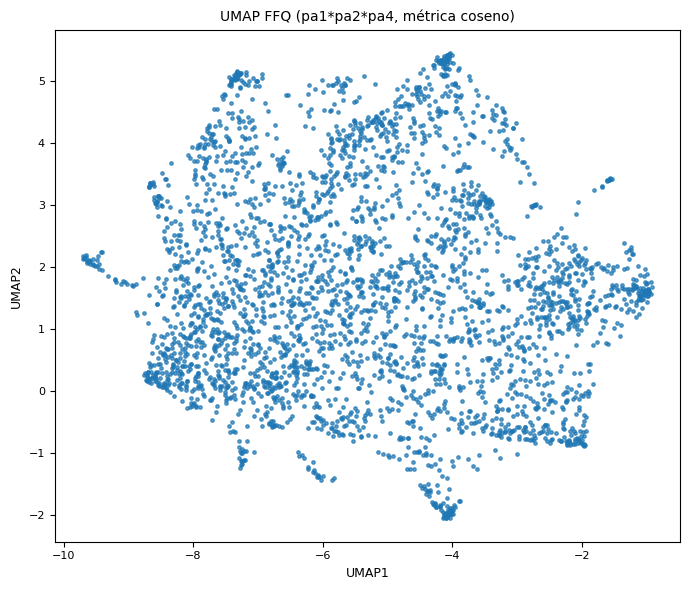

,cluster,TITULO,media_cluster,media_global,lift,n_miembros
0,0,DFLEG_Leguminosas hervidas/de la olla (protector),12.350131,3.495015,3.533642,153
1,0,DFLEG_Frijoles refritos (atención),5.128824,1.641368,3.124726,153
2,0,DFLAC_Leches descremadas/semidescremadas o soya sin azúcar (protector),0.878039,0.355778,2.467943,153
3,0,DFB_Aditivos cremosos/leche en bebidas (riesgo),0.726667,0.418063,1.738174,153
4,0,DFMAIZ_Tamal (riesgo),1.166667,0.729395,1.599499,153
...,...,...,...,...,...,...
95,19,DFB_Bebidas no calóricas (protector),16.612365,4.123817,4.028395,148
96,19,DFB_Azúcar añadida a bebidas (riesgo),10.405405,4.416016,2.356288,148
97,19,DFLEG_Frijoles envasados 'de la olla' (atención),0.113176,0.049860,2.269871,148
98,19,DFB_Aditivos cremosos/leche en bebidas (riesgo),0.942095,0.418063,2.253474,148


/tmp/ipython-input-3143434168.py:139: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_clusters = cm.get_cmap("tab20", K)


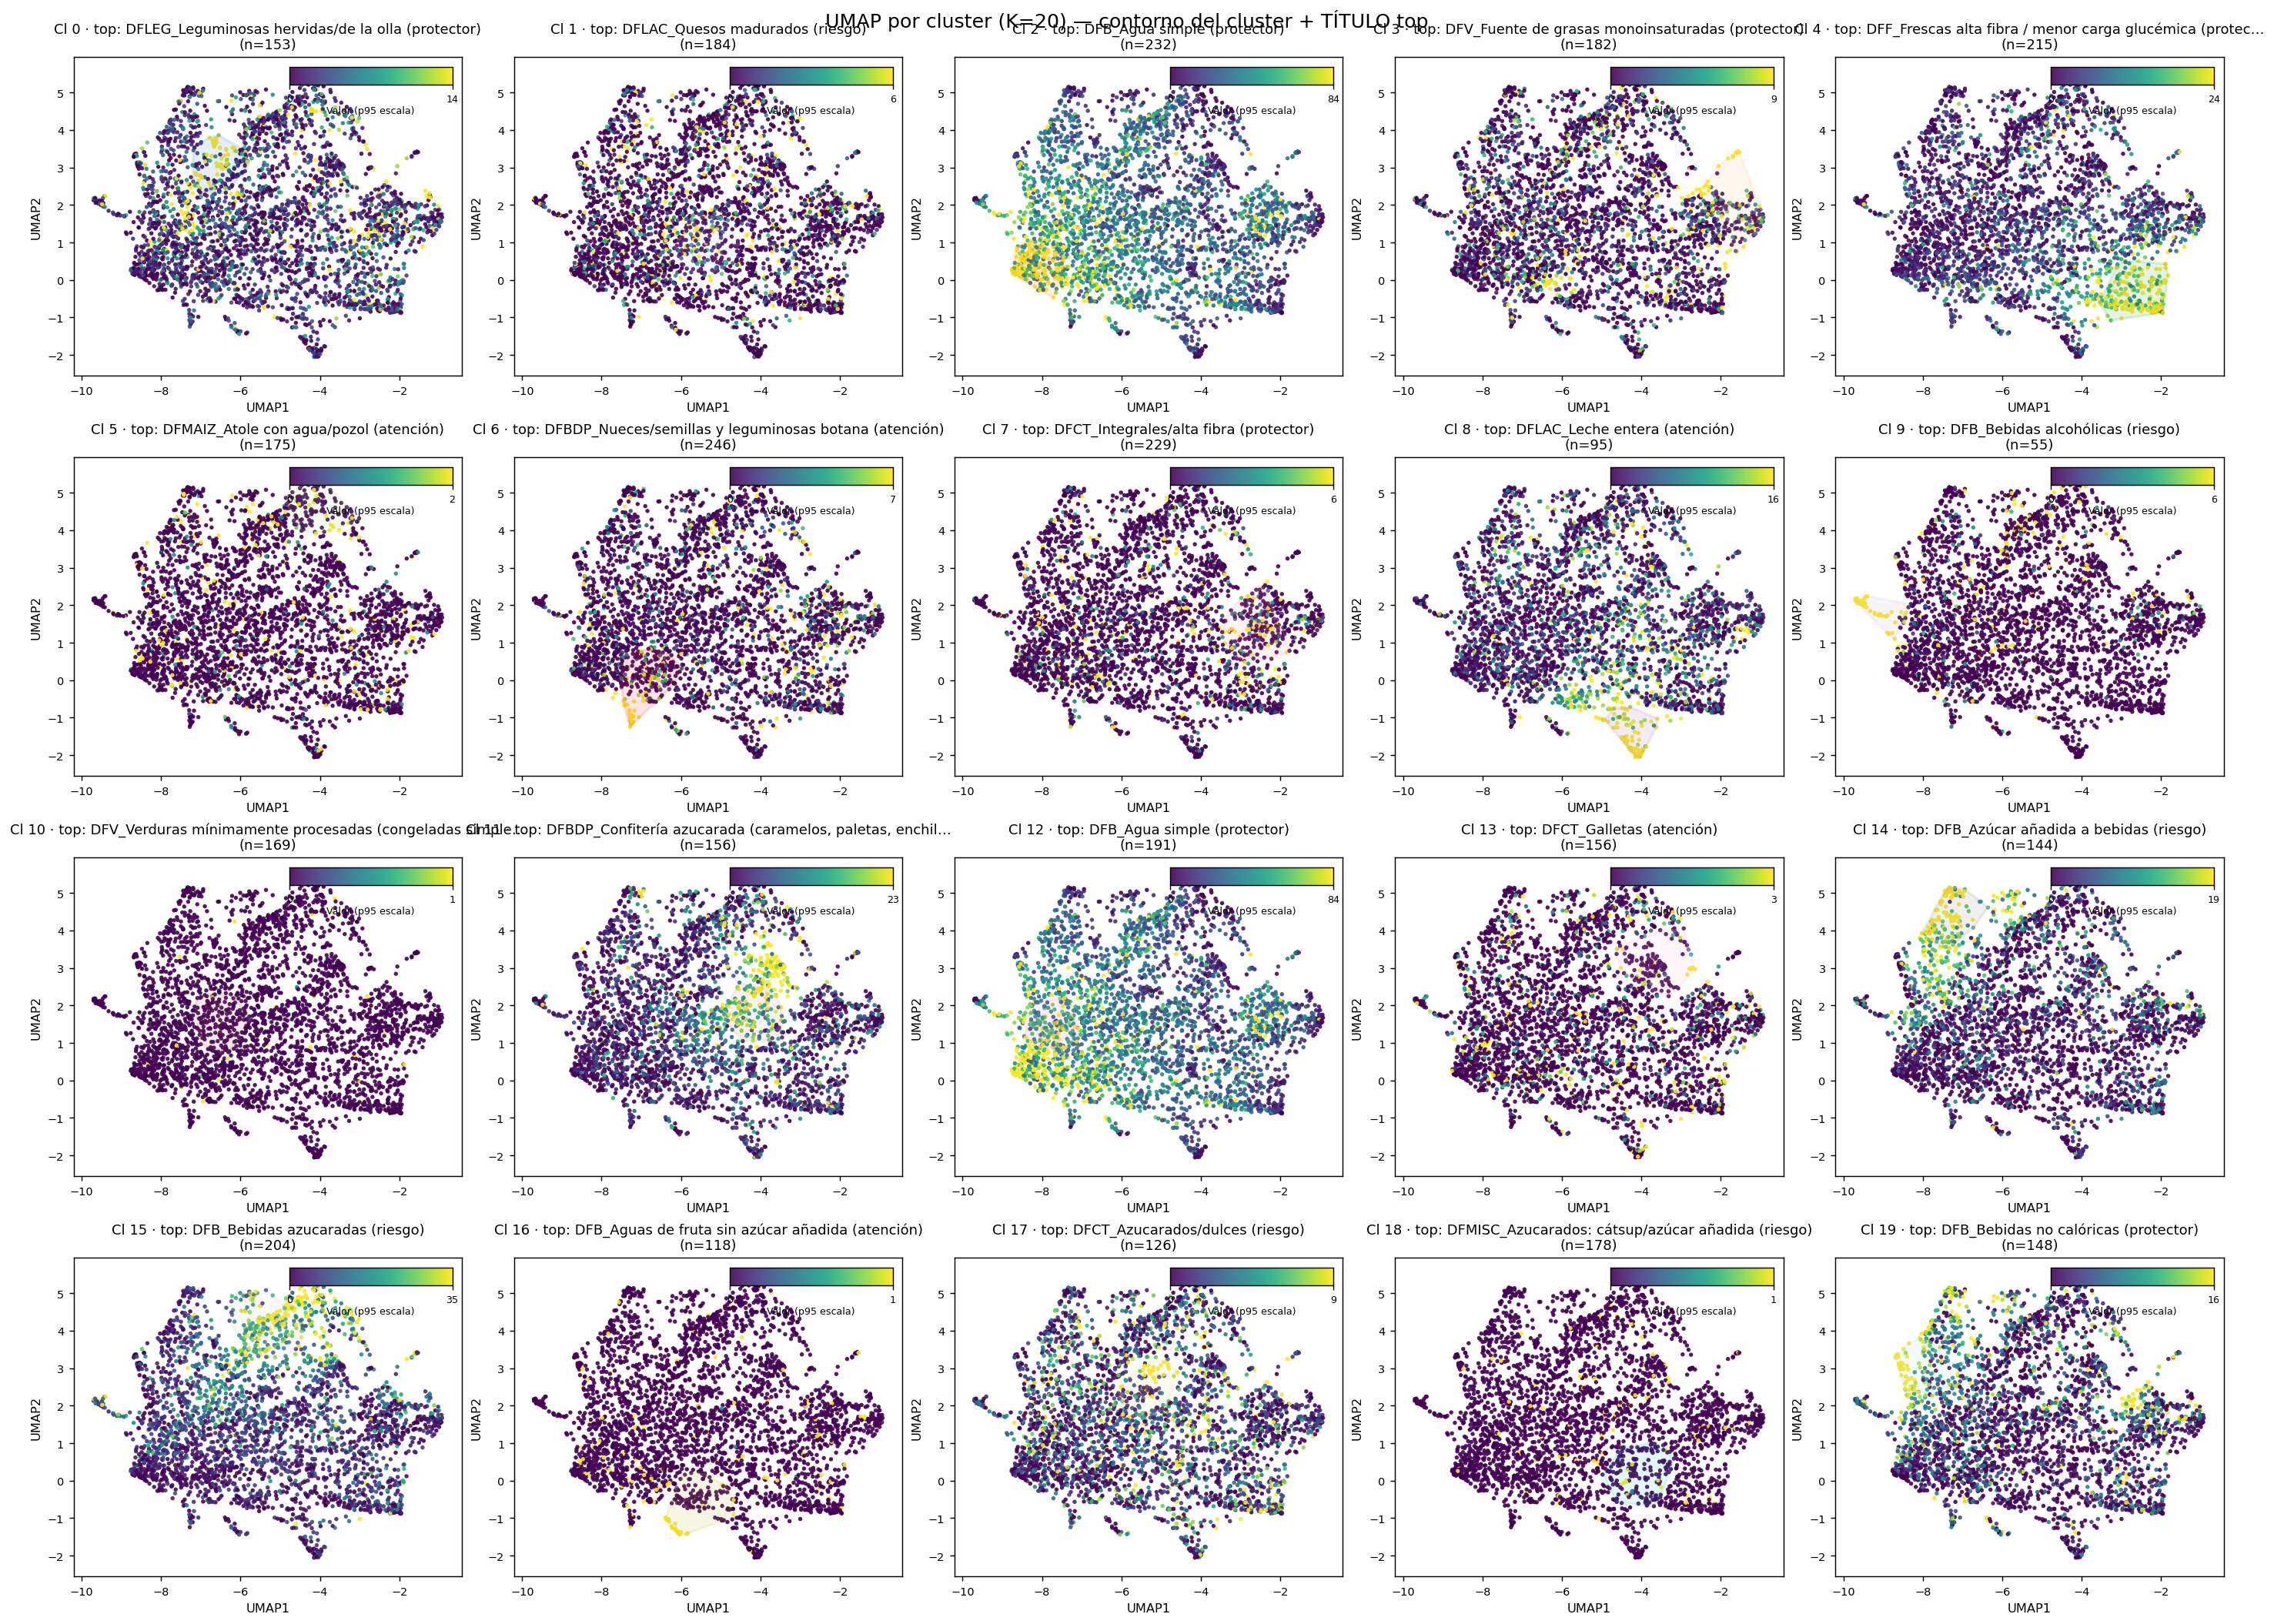

In [116]:
# ==========================
# UMAP sobre la matriz FFQ
# ==========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Asegura UMAP instalado
try:
    import umap
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn"])
    import umap

# --- Partimos de `matriz` (individuo × TITULO) ---
X = matriz.copy()

# 2) Limpieza: quita columnas/filas totalmente cero (no aportan info al UMAP)
cols_nonzero = X.columns[(X != 0).any(axis=0)]
X = X.loc[:, cols_nonzero]
rows_nonzero = X.index[(X != 0).any(axis=1)]
X = X.loc[rows_nonzero]

# 3) (recomendado) Normalización por fila para usar métrica coseno de forma estable
#    Convierte cada vector de individuo a norma L2 = 1 (si no es todo cero)
row_norm = np.linalg.norm(X.values, axis=1, keepdims=True)
row_norm[row_norm == 0] = 1.0
X_norm = X.values / row_norm

# 4) UMAP
reducer = umap.UMAP(
    n_neighbors=30,       # ajusta: 15–50 según densidad
    min_dist=0.1,         # 0.0 = más compacto; 0.3 = más separado
    n_components=2,
    metric="cosine",
    random_state=42
)
embedding = reducer.fit_transform(X_norm)

# 5) Resultado como DataFrame
umap_df = pd.DataFrame(
    embedding,
    index=X.index,
    columns=["UMAP1", "UMAP2"]
).reset_index()  # trae FOLIO_I y FOLIO_INT como columnas

# 6) Plot sencillo
plt.figure(figsize=(7,6))
plt.scatter(umap_df["UMAP1"], umap_df["UMAP2"], s=6, alpha=0.7)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP FFQ (pa1*pa2*pa4, métrica coseno)")
plt.tight_layout()
plt.show()

# 7) (Opcional) guardar resultados
# umap_df.to_csv("FFQ_umap_coords.csv", index=False)

# Vista rápida
umap_df.head()

# ============================================
# K-means (k=20) + TOP títulos + Panel UMAP 4x5 con polígonos
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- 1) K-means sobre UMAP ---
from sklearn.cluster import KMeans

K = 20
X_emb = umap_df[["UMAP1","UMAP2"]].values
kmeans = KMeans(n_clusters=K, n_init=30, random_state=42)
labels = kmeans.fit_predict(X_emb)

umap_df = umap_df.copy()
umap_df["cluster"] = labels

# --- 2) Alinear UMAP con la matriz individuo×TITULO ---
M = matriz.copy()
idx_join = ["FOLIO_I","FOLIO_INT"] if isinstance(M.index, pd.MultiIndex) else ["FOLIO_I"]
UM = umap_df.set_index(idx_join).loc[M.index]  # reordenado para empatar exactamente

# --- 3) Top títulos por cluster (enriquecimiento vs promedio global) ---
overall_mean = M.mean(axis=0) + 1e-12
top_by_cluster = {}
rows = []
TOP_N = 5  # para tabla de salida

for c in range(K):
    mask = (UM["cluster"] == c).values
    M_c = M.loc[mask]
    cl_mean = M_c.mean(axis=0)
    lift = (cl_mean / overall_mean)
    lift = lift[cl_mean > 0].sort_values(ascending=False)  # evita medias ~0

    feats = lift.head(max(1, TOP_N)).index.tolist()
    top_by_cluster[c] = feats[:1]  # 1 top para graficar

    for f in feats:
        rows.append({
            "cluster": c,
            "TITULO": f,
            "media_cluster": float(cl_mean[f]),
            "media_global": float(overall_mean[f]),
            "lift": float(lift[f]),
            "n_miembros": int(mask.sum())
        })

top_table = pd.DataFrame(rows).sort_values(["cluster","lift"], ascending=[True, False]).reset_index(drop=True)
display(top_table)

# --- 4) Utilidad: contorno del cluster (alpha-shape si hay; si no convex hull) ---
def draw_cluster_polygon(ax, pts, edgecolor, use_alpha=True):
    poly_drawn = False
    if use_alpha:
        try:
            import alphashape
            alpha = alphashape.optimizealpha(pts)
            poly = alphashape.alphashape(pts, alpha)
            if poly and not poly.is_empty:
                xh, yh = poly.exterior.coords.xy
                ax.fill(xh, yh, facecolor=edgecolor, alpha=0.12, edgecolor=edgecolor, linewidth=2.0, zorder=3)
                poly_drawn = True
        except Exception:
            poly_drawn = False
    if not poly_drawn:
        from scipy.spatial import ConvexHull
        hull = ConvexHull(pts)
        H = pts[hull.vertices]
        ax.fill(H[:,0], H[:,1], facecolor=edgecolor, alpha=0.12, edgecolor=edgecolor, linewidth=2.0, zorder=3)

# --- 5) Panel 4×5 con polígonos y color por valor del título top ---
cmap_clusters = cm.get_cmap("tab20", K)

def corta(txt, n=55):
    s = str(txt);  return s if len(s) <= n else s[:n-1] + "…"

pad = 0.5
x_min, x_max = UM["UMAP1"].min()-pad, UM["UMAP1"].max()+pad
y_min, y_max = UM["UMAP2"].min()-pad, UM["UMAP2"].max()+pad

nrows, ncols = 4, 5
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 16), dpi=130, constrained_layout=True)
axes = axes.ravel()

for c, ax in enumerate(axes):
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

    mask = (UM["cluster"] == c).values
    if mask.sum() == 0:
        ax.set_title(f"Cluster {c} (vacío)"); ax.axis("off"); continue

    feat = top_by_cluster[c][0]
    vals = M[feat].values

    # Escala por panel al p95 para evitar outliers
    vmax = float(np.nanpercentile(vals, 95)) or 1.0
    norm = Normalize(vmin=0, vmax=vmax)

    # Fondo: todos los puntos en gris muy tenue
    ax.scatter(UM["UMAP1"], UM["UMAP2"], s=6, alpha=0.08, color="#666", linewidths=0, zorder=0)
    # Capa coloreada por el valor del título top (todos los individuos)
    sc = ax.scatter(UM["UMAP1"], UM["UMAP2"], s=9, alpha=0.9, c=vals, cmap="viridis", norm=norm, linewidths=0, zorder=1)

    # Polígono del cluster (transparente)
    pts = UM.loc[mask, ["UMAP1","UMAP2"]].values
    edgecolor = cmap_clusters(c % K)
    draw_cluster_polygon(ax, pts, edgecolor, use_alpha=True)

    # Mini colorbar por panel
    cax = inset_axes(ax, width="42%", height="5.5%", loc="upper right", borderpad=0.7)
    cb = plt.colorbar(sc, cax=cax, orientation="horizontal")
    cb.set_ticks([0, vmax]); cb.set_ticklabels(["0", f"{vmax:.0f}"])
    cb.ax.tick_params(labelsize=7); cb.set_label("Valor (p95 escala)", fontsize=7, labelpad=1)

    ax.set_title(f"Cl {c} · top: {corta(feat)}\n(n={int(mask.sum())})", fontsize=10)
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2"); ax.grid(False)

fig.suptitle("UMAP por cluster (K=20) — contorno del cluster + TÍTULO top", y=1.005, fontsize=14)
plt.show()


In [147]:
# ======================================================
# L2 por fila -> UMAP 3D (cosine) -> KMeans
# Plotly 3D: color por TÍTULO top del cluster con escala p95 (como tu panel)
# + opción de colorear por cluster + Hull 3D por cluster
# Exporta HTML
# ======================================================
import numpy as np
import pandas as pd

# -------- Plotly renderer según entorno --------
import plotly.io as pio
try:
    import google.colab  # noqa
    pio.renderers.default = "colab"
except Exception:
    try:
        get_ipython  # noqa
        pio.renderers.default = "notebook_connected"
    except Exception:
        pio.renderers.default = "browser"

# -------------------- 0) Datos base --------------------
X = matriz.copy()  # individuo × TITULO

# Quita columnas/filas totalmente cero
cols_nonzero = X.columns[(X != 0).any(axis=0)]
X = X.loc[:, cols_nonzero]
rows_nonzero = X.index[(X != 0).any(axis=1)]
X = X.loc[rows_nonzero]

# -------------------- 1) Normalización por fila (L2) --------------------
row_norm = np.linalg.norm(X.values, axis=1, keepdims=True)
row_norm[row_norm == 0] = 1.0
X_norm = X.values / row_norm

# -------------------- 2) UMAP 3D (cosine) --------------------
import umap
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=3,
    metric="cosine",
    random_state=42
)
embedding = reducer.fit_transform(X_norm)

umap_df = pd.DataFrame(embedding, index=X.index, columns=["UMAP1","UMAP2","UMAP3"])

# -------------------- 3) KMeans sobre UMAP --------------------
from sklearn.cluster import KMeans
K = 20
kmeans = KMeans(n_clusters=K, n_init=30, random_state=42)
labels = kmeans.fit_predict(umap_df[["UMAP1","UMAP2","UMAP3"]].values)
umap_df["cluster"] = labels

# -------------------- 4) Alinear con matriz original --------------------
M = matriz.copy()
# Si tu índice es MultiIndex (FOLIO_I, FOLIO_INT), ajusta aquí:
umap_df = umap_df.set_index(M.index)  # asume mismo orden que M
UM = umap_df.join(pd.DataFrame(index=M.index), how="right")

# -------------------- 5) Títulos TOP por cluster (lift) --------------------
overall_mean = M.mean(axis=0) + 1e-12
top_by_cluster = {}
rows = []
TOP_N = 5  # como tu script original (usaremos el primero para colorear por cluster)

for c in range(K):
    mask = (UM["cluster"].values == c)
    if mask.sum() == 0:
        top_by_cluster[c] = []
        continue
    M_c = M.loc[mask]
    cl_mean = M_c.mean(axis=0)
    lift = (cl_mean / overall_mean)
    lift = lift[cl_mean > 0].sort_values(ascending=False)

    feats = lift.head(max(1, TOP_N)).index.tolist()
    top_by_cluster[c] = feats[:1]  # 1 top para “la capa coloreada”, igual que en tu panel

# -------------------- 6) Utilitarios --------------------
def p95(vals):
    v = float(np.nanpercentile(vals, 95)) if np.isfinite(vals).any() else 1.0
    return 1.0 if v == 0 else v

# Precomputamos p95 POR FEATURE (replicando el “p95 por panel” de tu figura)
p95_por_feature = {f: p95(M[f].values) for lst in top_by_cluster.values() for f in lst if f in M.columns}

# Hull 3D para cada cluster
from scipy.spatial import ConvexHull

def mesh3d_from_points(Xc):
    # Xc: (n, 3) puntos del cluster en UMAP 3D
    if Xc.shape[0] < 4:
        return None
    try:
        hull = ConvexHull(Xc)
        simp = hull.simplices
        i, j, k = simp[:,0], simp[:,1], simp[:,2]
        import plotly.graph_objects as go
        return go.Mesh3d(
            x=Xc[:,0], y=Xc[:,1], z=Xc[:,2],
            i=i, j=j, k=k,
            color="rgba(0,0,0,0)",  # contorno translúcido
            opacity=0.12,
            flatshading=True,
            showscale=False,
            hoverinfo="skip",
            name=f"hull"
        )
    except Exception:
        return None

# -------------------- 7) Plotly 3D + dropdown --------------------
import plotly.graph_objects as go

x = UM["UMAP1"].values
y = UM["UMAP2"].values
z = UM["UMAP3"].values

# Fondo gris tenue (todos los puntos)
bg = go.Scatter3d(
    x=x, y=y, z=z,
    mode="markers",
    marker=dict(size=2, color="rgba(100,100,100,0.12)"),
    name="fondo",
    hoverinfo="skip",
    showlegend=False
)

# Capa principal (recoloreable vía dropdown)
main = go.Scatter3d(
    x=x, y=y, z=z,
    mode="markers",
    marker=dict(
        size=3,
        opacity=0.95,
        colorscale="Viridis",
        color=labels,              # inicio: por cluster
        colorbar=dict(title="cluster")
    ),
    name="puntos"
)

fig = go.Figure([bg, main])

# Hulls por cluster
for c in range(K):
    pts = UM.loc[UM["cluster"]==c, ["UMAP1","UMAP2","UMAP3"]].values
    mesh = mesh3d_from_points(pts)
    if mesh is not None:
        fig.add_trace(mesh)

# Dropdown: opción “cluster” y luego una opción por cluster con su TÍTULO top
buttons = []

# 0) Colorear por cluster (categórico)
buttons.append(dict(
    label="cluster",
    method="restyle",
    args=[{
        "marker": [dict(
            size=3, opacity=0.95,
            colorscale="Viridis",
            color=labels,
            colorbar=dict(title="cluster")
        )]
    }, [1]]  # aplicar al segundo trace (main), índice 1
))

# 1..K) Por cada cluster: colorear por su TÍTULO top con p95 POR FEATURE (como tu panel)
for c in range(K):
    feats = top_by_cluster.get(c, [])
    if not feats:  # cluster vacío
        continue
    feat = feats[0]
    if feat not in M.columns:
        continue
    vals = M[feat].values
    vmax = p95_por_feature.get(feat, p95(vals))

    buttons.append(dict(
        label=f"Cl {c} · {feat}",
        method="restyle",
        args=[{
            "marker": [dict(
                size=3, opacity=0.95,
                colorscale="Viridis",   # misma paleta que usaste en 2D
                color=vals,
                cmin=0, cmax=vmax,      # p95 “por panel/feature”
                colorbar=dict(title=f"{feat} (0–p95)")
            )]
        }, [1]]  # solo el trace 'main'
    ))

fig.update_layout(
    title="UMAP 3D (cosine) — K=20 — Color por TÍTULO top con escala p95 (réplica del panel) + Hull 3D",
    scene=dict(
        xaxis_title="UMAP1",
        yaxis_title="UMAP2",
        zaxis_title="UMAP3"
    ),
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        showactive=True,
        x=1.02, y=0.95, xanchor="left",
        buttons=buttons,
        bgcolor="white"
    )],
    margin=dict(l=0, r=0, t=60, b=0)
)

fig.show()
fig.write_html("umap3d_like_panel_matplotlib.html", include_plotlyjs="cdn")
print("HTML guardado como: umap3d_like_panel_matplotlib.html")


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



HTML guardado como: umap3d_like_panel_matplotlib.html


Son las **fuentes** (el origen del registro) que agregamos cuando unificaste los DataFrames. Cada sigla corresponde al sub-conjunto del que salió la fila:

* **DFV** → **Verduras** (verduras frescas, almidonadas, crucíferas, etc.).
* **DFF** → **Frutas** (alta fibra, alta/intermedia CG, secas, almíbar…).
* **DFB** → **Bebidas** (agua, no calóricas, jugos 100%, SSB, alcohol, aditivos).
* **DFC** → **Carnes/Huevo/Embutidos** (aves, carne roja, procesadas, huevo…).
* **DFCT** → **Cereales y Tubérculos (CT)** (integrales, refinados, galletas, frituras).
* **DFBDP** → **Botanas/Dulces/Postres (BDP)** (frituras de paquete, postres, helados, confitería, palomitas…).
* **DFLAC** → **Lácteos (LAC)** (leche entera/baja, yogur, quesos, lácteos azucarados).
* **DFSOP** → **Sopas/Caldo (SOP)** (caldo, sopas caldosas/secas, instantáneas, crema de verduras).
* **DFLEG** → **Leguminosas (LEG)** (de la olla, refritos, envasados, caldo de frijol).
* **DFMAIZ** → **Maíz/Antojitos** (tamal, atole/pozol, antojitos con/si freír, tortita/taco, etc.).
* **DFFAST** → **Comida rápida (FAST)** (pizza, hamburguesa, hot dog, torta/sándwich).
* **DFMISC** → **Misceláneos/Condimentos (MISC)** (salsas/condimentos salados, azucarados, grasas untables, aromáticos).
* **DFPES** → **Pescados y Mariscos (PES)** (fresco/mariscos; enlatados/secos).




#diccionario